In [1]:
import subprocess
subprocess.run(["pip", "install", "requests", "pandas", "geopandas",
                "matplotlib", "folium", "shapely"], check=True)

CompletedProcess(args=['pip', 'install', 'requests', 'pandas', 'geopandas', 'matplotlib', 'folium', 'shapely'], returncode=0)

In [2]:
import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import folium
import json
import warnings
from shapely.geometry import Point
warnings.filterwarnings('ignore')

# ── API Keys ──────────────────────────────────────────────────
AQICN_TOKEN      = "2e3c22302b8b4d6eee56f4886f98ef181db7463a"
AQICN_DATA_TOKEN = "17ec6ebc3fae224f3a89f3356ecdd6d694dea64f"
OPENAQ_KEY       = "7cca159409114cc5d24652602c23fde4d18858debdc24e64ff37d2abaf0b18eb"

# ── Milano Bounding Box ───────────────────────────────────────
BBOX = {
    "lon_min": 8.706,
    "lat_min": 45.265,
    "lon_max": 9.552,
    "lat_max": 45.643
}

# ── Project Period ────────────────────────────────────────────
PROJECT_START = pd.Timestamp("2019-01-01", tz="UTC")
PROJECT_END   = pd.Timestamp.now(tz="UTC")
PROJECT_HOURS = (PROJECT_END - PROJECT_START).total_seconds() / 3600

# ── Helper: % null calculation ────────────────────────────────
def null_pct(date_first, date_last):
    try:
        d1 = pd.to_datetime(date_first, utc=True)
        d2 = pd.to_datetime(date_last,  utc=True)
        if pd.isna(d1) or pd.isna(d2):
            return None
        d1 = max(d1, PROJECT_START)
        covered = max(0, (d2 - d1).total_seconds() / 3600)
        return max(0.0, round((1 - covered / PROJECT_HOURS) * 100, 1))
    except:
        return None

print("All imports successful!")
print(f"Project start: {PROJECT_START.date()}")
print(f"Project end:   {PROJECT_END.date()} (today)")
print(f"Total project hours: {PROJECT_HOURS:.0f}")

All imports successful!
Project start: 2019-01-01
Project end:   2026-05-20 (today)
Total project hours: 64716


CRS: EPSG:4326
Geometry type: MultiPolygon
Bounds: [ 8.70609607 45.26499363  9.55156249 45.64266805]


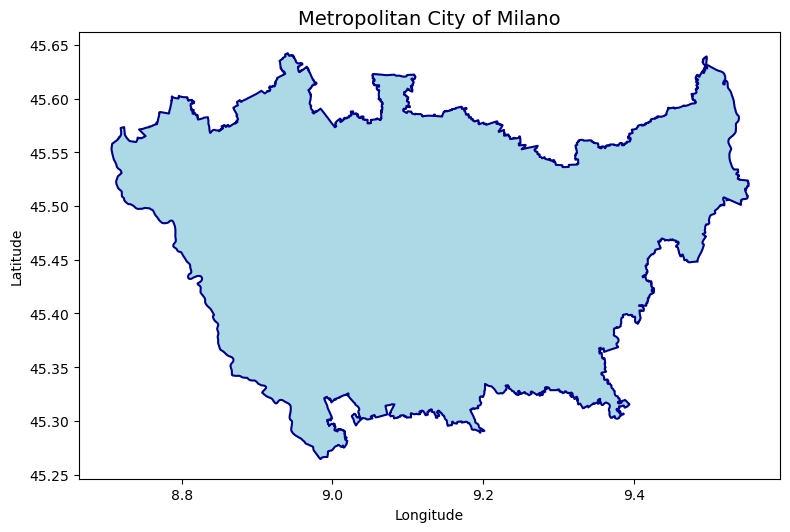

Milano boundary loaded successfully!


In [3]:
# ── Load Milano Boundary from MCM.gpkg ───────────────────────
mcm = gpd.read_file(r"C:\Msc Geo Informatics\2nd Year - 2nd Semester\Geo Informatics Project\MCM.gpkg")
milano_polygon = mcm.geometry.union_all()

print("CRS:", mcm.crs)
print("Geometry type:", mcm.geom_type.values[0])
print("Bounds:", mcm.total_bounds)

fig, ax = plt.subplots(figsize=(8, 6))
mcm.plot(ax=ax, color="lightblue", edgecolor="darkblue", linewidth=1.5)
ax.set_title("Metropolitan City of Milano", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

print("Milano boundary loaded successfully!")

In [4]:
# ── OpenAQ - Get stations within Milano bbox ──────────────────
print("Fetching OpenAQ stations... please wait")

headers = {"X-API-Key": OPENAQ_KEY}
params  = {
    "bbox":  f"{BBOX['lon_min']},{BBOX['lat_min']},{BBOX['lon_max']},{BBOX['lat_max']}",
    "limit": 1000,
    "page":  1
}

response = requests.get(
    "https://api.openaq.org/v3/locations",
    headers=headers, params=params
)
data = response.json()
print("Status code:", response.status_code)
print("Total stations in bbox:", data.get("meta", {}).get("found", 0))

# ── Extract station details + classify by provider ─────────────
openaq_stations = []

for loc in data["results"]:
    station_id = loc.get("id")

    # Get provider info
    detail_url = f"https://api.openaq.org/v3/locations/{station_id}"
    r2 = requests.get(detail_url, headers=headers).json()
    provider = "Unknown"
    owner    = "Unknown"
    if r2.get("results"):
        provider = r2["results"][0].get("provider", {}).get("name", "Unknown")
        owner    = r2["results"][0].get("owner",    {}).get("name", "Unknown")

    openaq_stations.append({
        "network":      "OpenAQ",
        "station_id":   station_id,
        "station_name": loc.get("name"),
        "latitude":     loc.get("coordinates", {}).get("latitude"),
        "longitude":    loc.get("coordinates", {}).get("longitude"),
        "sensors":      [s.get("parameter", {}).get("name") for s in loc.get("sensors", [])],
        "date_first":   loc.get("datetimeFirst", {}).get("local") if loc.get("datetimeFirst") else None,
        "date_last":    loc.get("datetimeLast",  {}).get("local") if loc.get("datetimeLast")  else None,
        "provider":     provider,
        "owner":        owner,
        "is_monitor":   r2["results"][0].get("isMonitor", False) if r2.get("results") else False,
    })

openaq_df = pd.DataFrame(openaq_stations)

# ── Filter strictly inside Milano polygon ─────────────────────
openaq_gdf = gpd.GeoDataFrame(
    openaq_df,
    geometry=[Point(row.longitude, row.latitude) for row in openaq_df.itertuples()],
    crs="EPSG:4326"
)

openaq_inside = openaq_gdf[openaq_gdf.geometry.within(milano_polygon)].copy()

# ── Split by provider ─────────────────────────────────────────
openaq_eea = openaq_inside[openaq_inside["provider"] == "EEA"].copy()
openaq_ag  = openaq_inside[openaq_inside["provider"] == "AirGradient"].copy()

print(f"\nStations in bounding box:               {len(openaq_gdf)}")
print(f"Stations inside Milano boundary:        {len(openaq_inside)}")
print(f"  - Official EEA/ARPA stations:         {len(openaq_eea)}")
print(f"  - Independent AirGradient stations:   {len(openaq_ag)}")
print("\nEEA/ARPA Stations:")
print(openaq_eea[["station_name", "latitude", "longitude", "provider", "date_first", "date_last"]].to_string())
print("\nAirGradient Stations (via OpenAQ):")
print(openaq_ag[["station_name", "latitude", "longitude", "provider", "date_first", "date_last"]].to_string())

Fetching OpenAQ stations... please wait
Status code: 200
Total stations in bbox: 32

Stations in bounding box:               32
Stations inside Milano boundary:        20
  - Official EEA/ARPA stations:         16
  - Independent AirGradient stations:   4

EEA/ARPA Stations:
                 station_name   latitude  longitude provider                 date_first                  date_last
1                     TURBIGO  45.525830   8.736670      EEA  2020-05-06T10:00:00+02:00  2026-05-19T18:00:00+02:00
2                         RHO  45.522500   9.044720      EEA  2020-05-06T17:00:00+02:00  2026-05-19T18:00:00+02:00
6                 S. GIULIANO  45.395280   9.282780      EEA  2020-05-06T16:00:00+02:00  2026-05-19T18:00:00+02:00
9                    ARCONATE  45.546670   8.848610      EEA  2020-05-06T17:00:00+02:00  2026-05-19T18:00:00+02:00
10            MILANO - SENATO  45.469722   9.198056      EEA  2020-05-06T17:00:00+02:00  2026-05-19T18:00:00+02:00
12         CASSANO VIA MILANO  45.

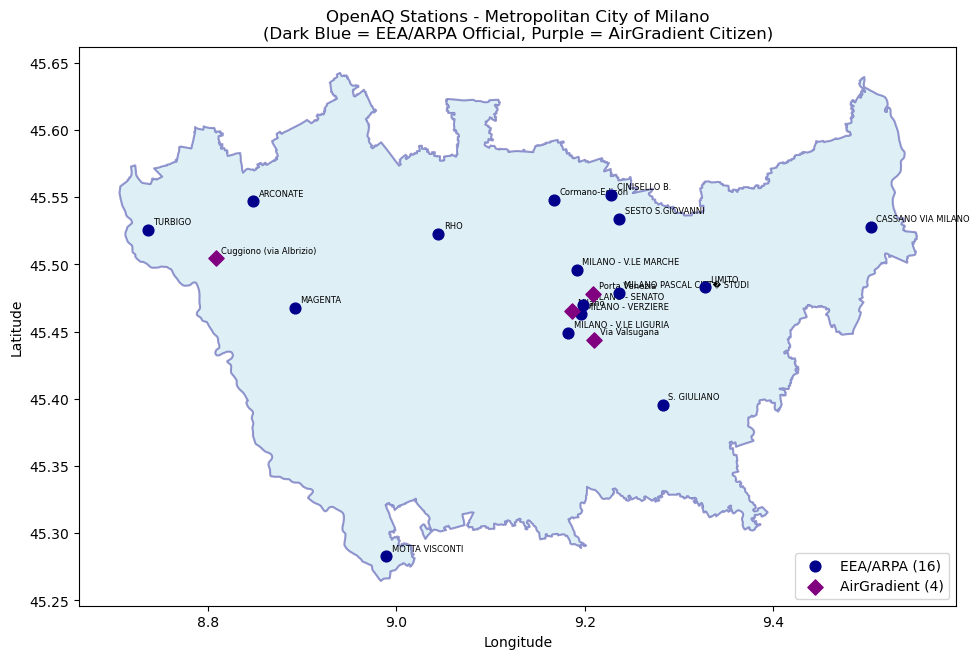

OpenAQ total stations inside Milano: 20
  EEA/ARPA official:   16
  AirGradient citizen: 4


In [5]:
# ── Plot OpenAQ stations on Milano map ───────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
mcm.plot(ax=ax, color="lightblue", edgecolor="darkblue", linewidth=1.5, alpha=0.4)

# EEA stations in dark blue
openaq_eea_gdf = gpd.GeoDataFrame(
    openaq_eea,
    geometry=[Point(row.longitude, row.latitude) for row in openaq_eea.itertuples()],
    crs="EPSG:4326"
)
openaq_eea_gdf.plot(ax=ax, color="darkblue", markersize=60, marker="o",
                    zorder=5, label=f"EEA/ARPA ({len(openaq_eea)})")

# AirGradient stations in purple
openaq_ag_gdf = gpd.GeoDataFrame(
    openaq_ag,
    geometry=[Point(row.longitude, row.latitude) for row in openaq_ag.itertuples()],
    crs="EPSG:4326"
)
openaq_ag_gdf.plot(ax=ax, color="purple", markersize=60, marker="D",
                   zorder=5, label=f"AirGradient ({len(openaq_ag)})")

for idx, row in openaq_inside.iterrows():
    ax.annotate(
        row["station_name"],
        xy=(row["longitude"], row["latitude"]),
        xytext=(4, 4), textcoords="offset points", fontsize=6
    )

ax.set_title("OpenAQ Stations - Metropolitan City of Milano\n(Dark Blue = EEA/ARPA Official, Purple = AirGradient Citizen)", fontsize=12)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

print(f"OpenAQ total stations inside Milano: {len(openaq_inside)}")
print(f"  EEA/ARPA official:   {len(openaq_eea)}")
print(f"  AirGradient citizen: {len(openaq_ag)}")

In [6]:
# ── AQICN - Get stations + UIDs ───────────────────────────────
print("Fetching AQICN stations... please wait")

milano_cities = [
    "milano", "sesto-san-giovanni", "monza", "cinisello-balsamo",
    "rho", "legnano", "magenta", "abbiategrasso", "melzo",
    "trezzo-sull-adda", "cassano-d-adda", "lodi", "pavia",
    "corsico", "buccinasco", "opera", "san-giuliano-milanese",
    "segrate", "pioltello", "cernusco-sul-naviglio", "vimodrone",
    "sesto-calende", "gallarate", "busto-arsizio", "saronno",
    "desio", "seregno", "vimercate", "merate", "lecco",
    "turbigo", "arconate", "cuggiono", "inveruno",
    "parabiago", "nerviano", "pero", "settimo-milanese",
    "assago", "pieve-emanuele", "lacchiarella", "binasco",
    "gorgonzola", "agrate-brianza", "brugherio", "muggio",
    "nova-milanese", "bresso", "cologno-monzese"
]

aqicn_city_stations = []

for city in milano_cities:
    url = f"https://api.waqi.info/feed/{city}/?token={AQICN_TOKEN}"
    r = requests.get(url).json()
    if r.get("status") == "ok":
        d = r["data"]
        geo = d.get("city", {}).get("geo", [None, None])
        aqicn_city_stations.append({
            "network":      "AQICN",
            "city_queried": city,
            "station_name": d.get("city", {}).get("name"),
            "uid":          d.get("idx"),
            "latitude":     geo[0],
            "longitude":    geo[1],
            "aqi":          d.get("aqi"),
            "pollutants":   list(d.get("iaqi", {}).keys()),
            "station_url":  d.get("city", {}).get("url")
        })

aqicn_city_df = pd.DataFrame(aqicn_city_stations)
aqicn_city_df = aqicn_city_df.drop_duplicates(subset=["station_name"])

# ── Filter strictly inside Milano polygon ─────────────────────
aqicn_city_gdf = gpd.GeoDataFrame(
    aqicn_city_df,
    geometry=[Point(row.longitude, row.latitude) for row in aqicn_city_df.itertuples()],
    crs="EPSG:4326"
)

aqicn_inside = aqicn_city_gdf[aqicn_city_gdf.geometry.within(milano_polygon)].copy()

# ── Get dates from OpenAQ (same ARPA source) ──────────────────
# AQICN re-publishes ARPA data - same source as OpenAQ EEA stations
# Match AQICN stations with nearest OpenAQ EEA station to get real dates
print("\nMatching AQICN stations with OpenAQ EEA stations for real dates...")

MATCH_THRESHOLD = 0.01  # ~1km

aqicn_inside = aqicn_inside.copy()
aqicn_inside["date_first"] = "Unknown"
aqicn_inside["date_last"]  = "Unknown"

for i, aqicn_row in aqicn_inside.iterrows():
    aqicn_pt = Point(float(aqicn_row["longitude"]), float(aqicn_row["latitude"]))
    best_dist = 999
    best_date_first = "Unknown"
    best_date_last  = "Unknown"

    for _, oaq_row in openaq_eea.iterrows():
        oaq_pt = Point(float(oaq_row["longitude"]), float(oaq_row["latitude"]))
        dist = aqicn_pt.distance(oaq_pt)
        if dist < best_dist:
            best_dist = dist
            best_date_first = oaq_row["date_first"]
            best_date_last  = oaq_row["date_last"]

    aqicn_inside.at[i, "date_first"] = best_date_first
    aqicn_inside.at[i, "date_last"]  = best_date_last
    print(f"  {aqicn_row['station_name'][:40]}: "
          f"first={str(best_date_first)[:10]}, "
          f"last={str(best_date_last)[:10]} "
          f"(dist={best_dist*111:.2f}km from nearest OpenAQ EEA)")

print(f"\nAQICN stations inside Milano: {len(aqicn_inside)}")
print("\nNote: AQICN re-publishes official ARPA Lombardia data (same source as OpenAQ EEA)")
print(aqicn_inside[["station_name", "uid", "latitude", "longitude",
                     "date_first", "date_last"]].to_string())

# ── Confirm AQICN source from API attribution text ────────────
print("\nConfirming AQICN data source from API response...")

for _, station in aqicn_inside.iterrows():
    uid  = station["uid"]
    name = station["station_name"]
    hist_url = f"https://api.waqi.info/api/feed/@{uid}/obs.en.json?token={AQICN_DATA_TOKEN}"
    r = requests.get(hist_url).json()
    obs_list = r.get("rxs", {}).get("obs", [])
    if obs_list:
        msg  = obs_list[0].get("msg", {})
        iaqi = msg.get("iaqi", [])
        if iaqi:
            attribution = iaqi[0].get("i", "")
            print(f"\n  Station: {name}")
            print(f"  Attribution: {attribution[:120]}")

print("\n" + "="*65)
print("CONCLUSION: AQICN sources data from ARPA Lombardia directly.")
print("It converts raw ug/m3 measurements to AQI index scale.")
print("="*65)

Fetching AQICN stations... please wait

Matching AQICN stations with OpenAQ EEA stations for real dates...
  Milano Senato, Lombardia, Italy: first=2020-05-06, last=2026-05-19 (dist=0.11km from nearest OpenAQ EEA)
  Sesto San Giovanni , Lombardia, Italy: first=2020-05-06, last=2026-05-19 (dist=0.10km from nearest OpenAQ EEA)
  Milano Pascal Città Studi, Lombardia, It: first=2020-05-06, last=2026-05-19 (dist=0.46km from nearest OpenAQ EEA)

AQICN stations inside Milano: 3

Note: AQICN re-publishes official ARPA Lombardia data (same source as OpenAQ EEA)
                                  station_name    uid   latitude  longitude                 date_first                  date_last
0              Milano Senato, Lombardia, Italy   9118  45.470501   9.197461  2020-05-06T17:00:00+02:00  2026-05-19T18:00:00+02:00
1        Sesto San Giovanni , Lombardia, Italy  10044  45.534768   9.236109  2020-05-06T18:00:00+02:00  2026-05-19T18:00:00+02:00
6  Milano Pascal Città Studi, Lombardia, Italy   91

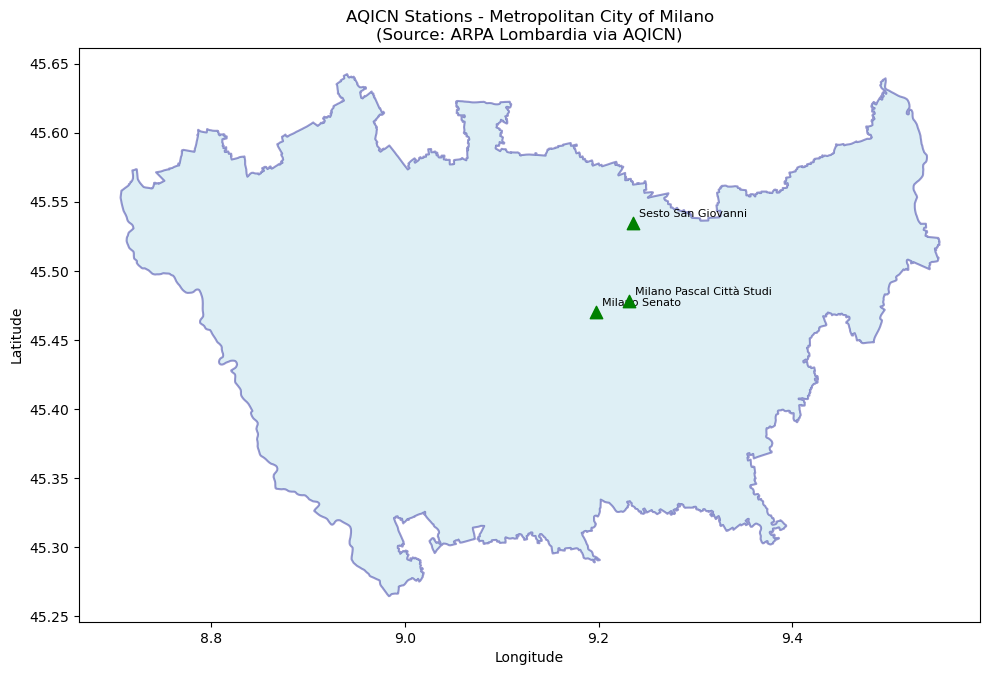

AQICN stations inside Milano: 3
Note: AQICN re-publishes official ARPA Lombardia data


In [7]:
# ── Plot AQICN stations on Milano map ────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
mcm.plot(ax=ax, color="lightblue", edgecolor="darkblue", linewidth=1.5, alpha=0.4)
aqicn_inside.plot(ax=ax, color="green", markersize=80, marker="^", zorder=5)

for idx, row in aqicn_inside.iterrows():
    ax.annotate(
        row["station_name"].split(",")[0],
        xy=(row["longitude"], row["latitude"]),
        xytext=(4, 4), textcoords="offset points", fontsize=8
    )

ax.set_title("AQICN Stations - Metropolitan City of Milano\n(Source: ARPA Lombardia via AQICN)", fontsize=12)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

print(f"AQICN stations inside Milano: {len(aqicn_inside)}")
print("Note: AQICN re-publishes official ARPA Lombardia data")

In [8]:
# ── SmartCitizenKit - Get devices within Milano bbox ──────────
print("Fetching SmartCitizenKit devices... please wait")

url = "https://api.smartcitizen.me/v0/devices"
params = {
    "near":   f"{(BBOX['lat_min'] + BBOX['lat_max'])/2},{(BBOX['lon_min'] + BBOX['lon_max'])/2}",
    "within": 40,
    "limit":  100,
    "page":   1
}

response = requests.get(url, params=params)
data_sck = response.json()

print("Status code:", response.status_code)
print("Total devices found:", len(data_sck))

# ── Extract device details ────────────────────────────────────
sck_stations = []

for device in data_sck:
    lat  = device.get("location", {}).get("latitude")
    lon  = device.get("location", {}).get("longitude")
    city = device.get("location", {}).get("city")

    sensors = []
    for sensor in device.get("data", {}).get("sensors", []):
        measurement = sensor.get("measurement", {})
        name = measurement.get("name") if measurement else sensor.get("description")
        unit = sensor.get("unit")
        if name:
            sensors.append(f"{name} ({unit})")

    sck_stations.append({
        "network":      "SmartCitizenKit",
        "station_id":   device.get("id"),
        "station_name": device.get("name"),
        "latitude":     lat,
        "longitude":    lon,
        "city":         city,
        "sensors":      sensors,
        "date_first":   device.get("created_at"),
        "date_last":    device.get("last_reading_at"),
        "state":        device.get("state")
    })

sck_df = pd.DataFrame(sck_stations)
sck_df = sck_df.dropna(subset=["latitude", "longitude"])

# ── Filter strictly inside Milano polygon ─────────────────────
sck_gdf = gpd.GeoDataFrame(
    sck_df,
    geometry=[Point(row.longitude, row.latitude) for row in sck_df.itertuples()],
    crs="EPSG:4326"
)

sck_inside = sck_gdf[sck_gdf.geometry.within(milano_polygon)].copy()

print(f"\nTotal SCK devices with coordinates: {len(sck_df)}")
print(f"Devices strictly inside Milano boundary: {len(sck_inside)}")
print("\nDevices inside Milano:")
print(sck_inside[["station_name", "latitude", "longitude",
                   "city", "state", "date_first", "date_last"]].to_string())

Fetching SmartCitizenKit devices... please wait
Status code: 200
Total devices found: 17

Total SCK devices with coordinates: 17
Devices strictly inside Milano boundary: 14

Devices inside Milano:
         station_name  latitude  longitude     city            state            date_first             date_last
0                alab  45.47361    9.11542   Milano    has_published  2015-05-24T21:47:12Z  2019-03-07T19:18:58Z
1       Via Gentilino  45.44910    9.18198    Milan    has_published  2025-09-25T15:24:01Z  2026-05-20T11:48:14Z
2             CAL 001  45.46420    9.18998    Milan   not_configured  2023-08-01T22:33:07Z                  None
3   Design Collisions  45.45121    9.21177    Milan    has_published  2019-04-04T16:54:57Z  2019-04-15T06:56:48Z
4           SaliuA0A6  45.48051    9.23267    Milan    has_published  2024-12-03T10:42:18Z  2025-01-14T14:01:46Z
5           SaliuA0C0  45.51332    9.21186    Milan    has_published  2024-12-09T14:58:10Z  2024-12-09T15:12:09Z
6           

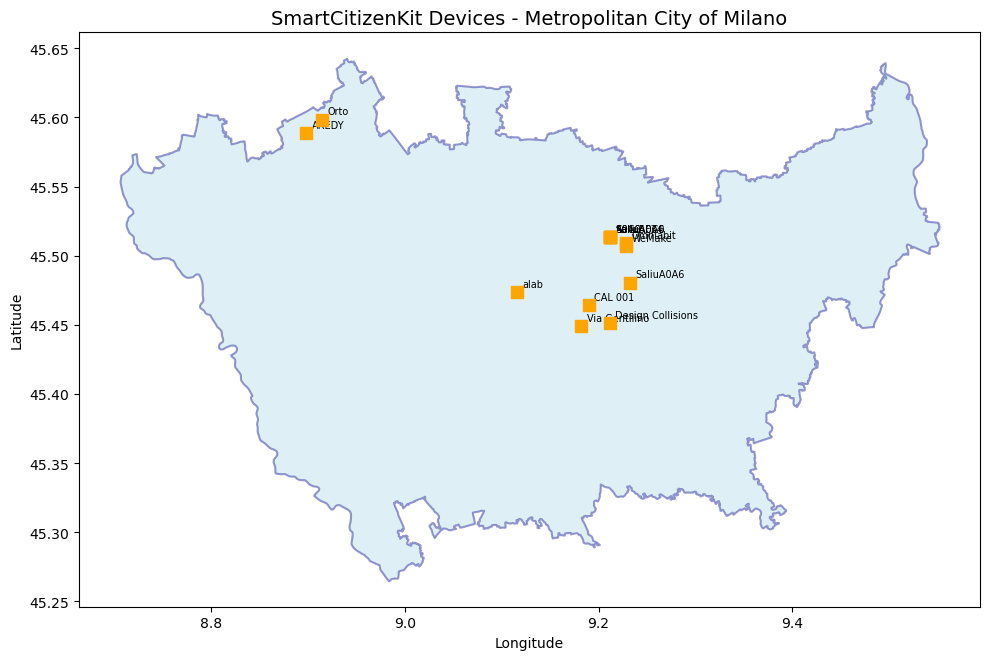

SCK devices inside Milano: 14
Active devices: 11
Inactive/not configured: 3


In [9]:
# ── Plot SCK devices on Milano map ───────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
mcm.plot(ax=ax, color="lightblue", edgecolor="darkblue", linewidth=1.5, alpha=0.4)
sck_inside.plot(ax=ax, color="orange", markersize=80, marker="s", zorder=5)

for idx, row in sck_inside.iterrows():
    ax.annotate(
        row["station_name"],
        xy=(row["longitude"], row["latitude"]),
        xytext=(4, 4), textcoords="offset points", fontsize=7
    )

ax.set_title("SmartCitizenKit Devices - Metropolitan City of Milano", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

print(f"SCK devices inside Milano: {len(sck_inside)}")
print(f"Active devices: {len(sck_inside[sck_inside['state'] == 'has_published'])}")
print(f"Inactive/not configured: {len(sck_inside[sck_inside['state'] != 'has_published'])}")

In [10]:
# ── AirGradient - Use OpenAQ AirGradient stations (complete) ──
# OpenAQ has 4 AirGradient stations vs direct API which only shows 2
print("Getting AirGradient stations from OpenAQ feed...")
ag_inside = openaq_ag.copy()
print(f"AirGradient stations inside Milano: {len(ag_inside)}")
print("\nStations with dates:")
print(ag_inside[["station_name", "latitude", "longitude",
                  "owner", "date_first", "date_last"]].to_string())

# ── Also verify via direct AirGradient API ────────────────────
print("\nVerifying via direct AirGradient API...")
try:
    url = "https://api.airgradient.com/public/api/v1/world/locations/measures/current"
    params = {
        "minLat": BBOX["lat_min"], "maxLat": BBOX["lat_max"],
        "minLon": BBOX["lon_min"], "maxLon": BBOX["lon_max"]
    }
    response = requests.get(url, params=params, timeout=15)
    if response.status_code == 200 and response.text.strip():
        ag_data = response.json()
        ag_filtered = [
            loc for loc in ag_data
            if loc.get("latitude") is not None
            and loc.get("longitude") is not None
            and BBOX["lat_min"] <= loc.get("latitude") <= BBOX["lat_max"]
            and BBOX["lon_min"] <= loc.get("longitude") <= BBOX["lon_max"]
        ]
        ag_direct_df = gpd.GeoDataFrame(
            [{
                "station_id":   loc.get("locationId"),
                "station_name": loc.get("locationName"),
                "latitude":     loc.get("latitude"),
                "longitude":    loc.get("longitude"),
                "offline":      loc.get("offline"),
                "date_last":    loc.get("timestamp")
            } for loc in ag_filtered],
            geometry=[Point(loc.get("longitude"), loc.get("latitude"))
                      for loc in ag_filtered],
            crs="EPSG:4326"
        ) if ag_filtered else gpd.GeoDataFrame()
        ag_direct_inside = ag_direct_df[
            ag_direct_df.geometry.within(milano_polygon)
        ].copy() if len(ag_direct_df) > 0 else gpd.GeoDataFrame()
        print(f"Direct AirGradient API stations inside Milano: {len(ag_direct_inside)}")
    else:
        print(f"Direct AirGradient API unavailable (status: {response.status_code}) - using OpenAQ data only")
        ag_direct_inside = gpd.GeoDataFrame()
except Exception as e:
    print(f"Direct AirGradient API error: {e} - using OpenAQ data only")
    ag_direct_inside = gpd.GeoDataFrame()

print(f"\nFinal AirGradient stations used: {len(ag_inside)} (from OpenAQ)")
for name in ["Cuggiono", "Porta", "Milano", "Valsugana"]:
    match = ag_inside[ag_inside["station_name"].str.contains(name, na=False)]
    if len(match) > 0:
        print(f"  {match.iloc[0]['station_name']}: date_first = {match.iloc[0]['date_first'][:10]}")

Getting AirGradient stations from OpenAQ feed...
AirGradient stations inside Milano: 4

Stations with dates:
               station_name   latitude  longitude        owner                 date_first                  date_last
27  Cuggiono (via Albrizio)  45.504372   8.808622      aidrini  2024-10-07T23:00:00+02:00  2026-05-20T13:00:00+02:00
28            Porta Venezia  45.478192   9.208741           AA  2024-11-13T09:00:00+01:00  2026-05-20T13:00:00+02:00
29                   Milano  45.465422   9.185924       Matteo  2024-11-30T13:00:00+01:00  2026-01-20T01:00:00+01:00
31            Via Valsugana  45.444021   9.209979  AirGradient  2026-02-09T10:00:00+01:00  2026-02-09T10:00:00+01:00

Verifying via direct AirGradient API...
Direct AirGradient API stations inside Milano: 2

Final AirGradient stations used: 4 (from OpenAQ)
  Cuggiono (via Albrizio): date_first = 2024-10-07
  Porta Venezia: date_first = 2024-11-13
  Milano: date_first = 2024-11-30
  Via Valsugana: date_first = 2026-02-09

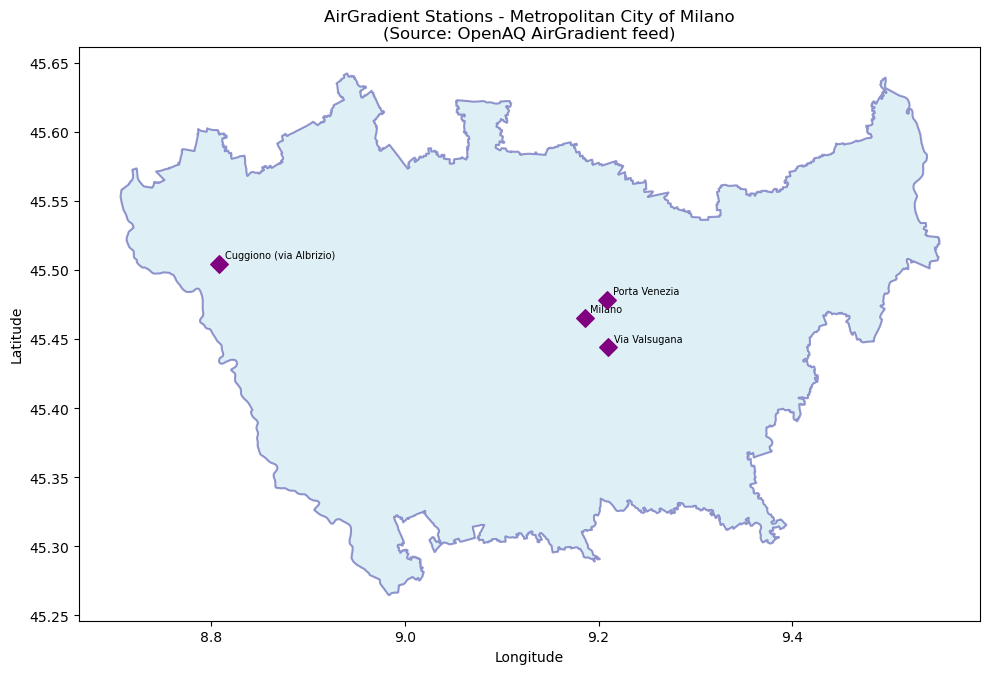

AirGradient stations inside Milano: 4
  Cuggiono (via Albrizio): owner=aidrini, first=2024-10-07, last=2026-05-20
  Porta Venezia: owner=AA, first=2024-11-13, last=2026-05-20
  Milano: owner=Matteo, first=2024-11-30, last=2026-01-20
  Via Valsugana: owner=AirGradient, first=2026-02-09, last=2026-02-09


In [11]:
# ── Plot AirGradient stations on Milano map ───────────────────
fig, ax = plt.subplots(figsize=(10, 8))
mcm.plot(ax=ax, color="lightblue", edgecolor="darkblue", linewidth=1.5, alpha=0.4)

ag_inside_gdf = gpd.GeoDataFrame(
    ag_inside,
    geometry=[Point(row.longitude, row.latitude) for row in ag_inside.itertuples()],
    crs="EPSG:4326"
)
ag_inside_gdf.plot(ax=ax, color="purple", markersize=80, marker="D", zorder=5)

for idx, row in ag_inside.iterrows():
    ax.annotate(
        row["station_name"],
        xy=(row["longitude"], row["latitude"]),
        xytext=(4, 4), textcoords="offset points", fontsize=7
    )

ax.set_title("AirGradient Stations - Metropolitan City of Milano\n(Source: OpenAQ AirGradient feed)", fontsize=12)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

print(f"AirGradient stations inside Milano: {len(ag_inside)}")
for _, row in ag_inside.iterrows():
    print(f"  {row['station_name']}: owner={row['owner']}, "
          f"first={str(row['date_first'])[:10]}, last={str(row['date_last'])[:10]}")

In [12]:
# ── Sensor.Community - No API key needed! ─────────────────────
print("Fetching Sensor.Community stations... please wait")

url = "https://data.sensor.community/airrohr/v1/filter/area=45.46,9.19,40"
response = requests.get(url)
sc_data  = response.json()

print("Status code:", response.status_code)
print(f"Total sensors found in radius: {len(sc_data)}")

# ── Extract sensor details ────────────────────────────────────
sc_stations = []

for sensor in sc_data:
    location = sensor.get("location", {})
    lat = location.get("latitude")
    lon = location.get("longitude")

    sensordatavalues = sensor.get("sensordatavalues", [])
    pollutants = [s.get("value_type") for s in sensordatavalues if s.get("value_type")]
    values     = {s.get("value_type"): s.get("value") for s in sensordatavalues}

    sc_stations.append({
        "network":     "Sensor.Community",
        "station_id":  sensor.get("id"),
        "sensor_type": sensor.get("sensor", {}).get("sensor_type", {}).get("name"),
        "latitude":    float(lat) if lat else None,
        "longitude":   float(lon) if lon else None,
        "country":     location.get("country"),
        "pollutants":  pollutants,
        "values":      values,
        "date_first":  "2017-01-01",
        "date_last":   sensor.get("timestamp")
    })

sc_df = pd.DataFrame(sc_stations)
sc_df = sc_df.dropna(subset=["latitude", "longitude"])

# ── Filter strictly inside Milano polygon ─────────────────────
sc_gdf = gpd.GeoDataFrame(
    sc_df,
    geometry=[Point(row.longitude, row.latitude) for row in sc_df.itertuples()],
    crs="EPSG:4326"
)

sc_inside = sc_gdf[sc_gdf.geometry.within(milano_polygon)].copy()
sc_unique = sc_inside.drop_duplicates(subset=["latitude", "longitude"]).copy()

print(f"Sensors strictly inside Milano boundary: {len(sc_inside)}")
print(f"Unique physical stations inside Milano:  {len(sc_unique)}")
print(f"Archive available from: 2017-01-01 (archive.sensor.community)")
print(f"Note: P1=PM10, P2=PM2.5, SDS011=PM sensor, DHT22/BME280=Temp/Humidity")
print(sc_unique[["station_id", "sensor_type", "latitude",
                 "longitude", "pollutants", "date_last"]].to_string())

Fetching Sensor.Community stations... please wait
Status code: 200
Total sensors found in radius: 132
Sensors strictly inside Milano boundary: 64
Unique physical stations inside Milano:  14
Archive available from: 2017-01-01 (archive.sensor.community)
Note: P1=PM10, P2=PM2.5, SDS011=PM sensor, DHT22/BME280=Temp/Humidity
     station_id   sensor_type   latitude  longitude                                pollutants            date_last
0   29372161926         DHT22  45.362000   9.048000                   [temperature, humidity]  2026-05-20 11:50:00
3   29372161627        SDS011  45.494000   9.100000                                  [P1, P2]  2026-05-20 11:49:58
5   29372161450        SDS011  45.502000   9.146000                                  [P1, P2]  2026-05-20 11:49:57
6   29372161120        SDS011  45.434337   9.106978                                  [P1, P2]  2026-05-20 11:49:54
10  29372159398         SPS30  45.477815   9.234495                                  [P1, P2]  2026-05-

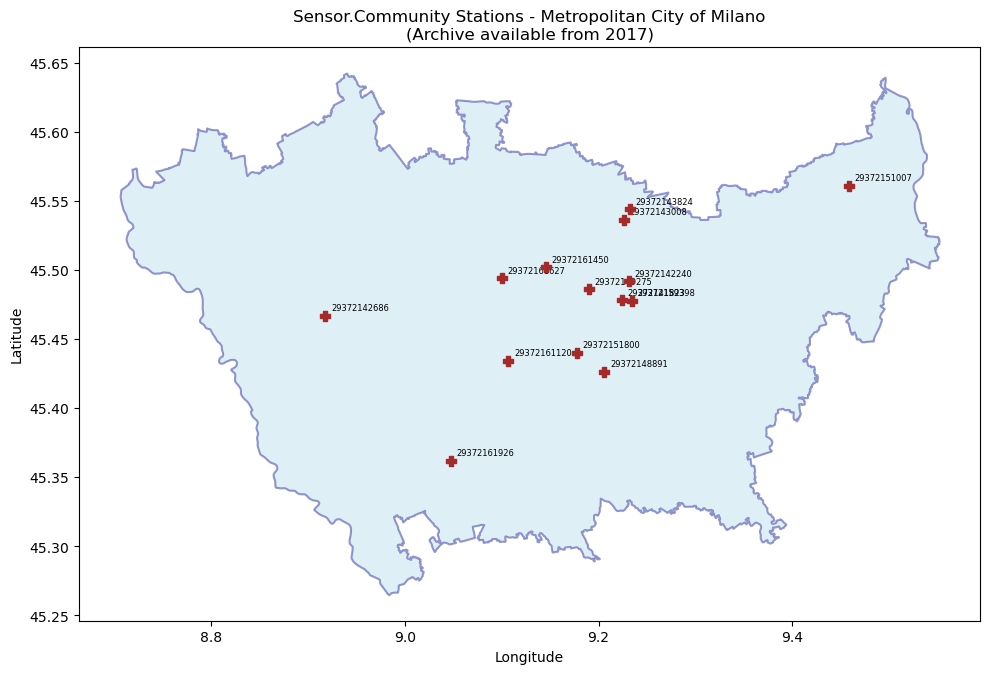

Sensor.Community unique stations inside Milano: 14
Sensor types found: ['DHT22' 'SDS011' 'SPS30' 'DNMS (Laerm)']


In [13]:
# ── Plot Sensor.Community stations on Milano map ──────────────
fig, ax = plt.subplots(figsize=(10, 8))
mcm.plot(ax=ax, color="lightblue", edgecolor="darkblue", linewidth=1.5, alpha=0.4)
sc_unique.plot(ax=ax, color="brown", markersize=60, marker="P", zorder=5)

for idx, row in sc_unique.iterrows():
    ax.annotate(
        str(row["station_id"]),
        xy=(row["longitude"], row["latitude"]),
        xytext=(4, 4), textcoords="offset points", fontsize=6
    )

ax.set_title("Sensor.Community Stations - Metropolitan City of Milano\n(Archive available from 2017)", fontsize=12)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

print(f"Sensor.Community unique stations inside Milano: {len(sc_unique)}")
print(f"Sensor types found: {sc_unique['sensor_type'].unique()}")

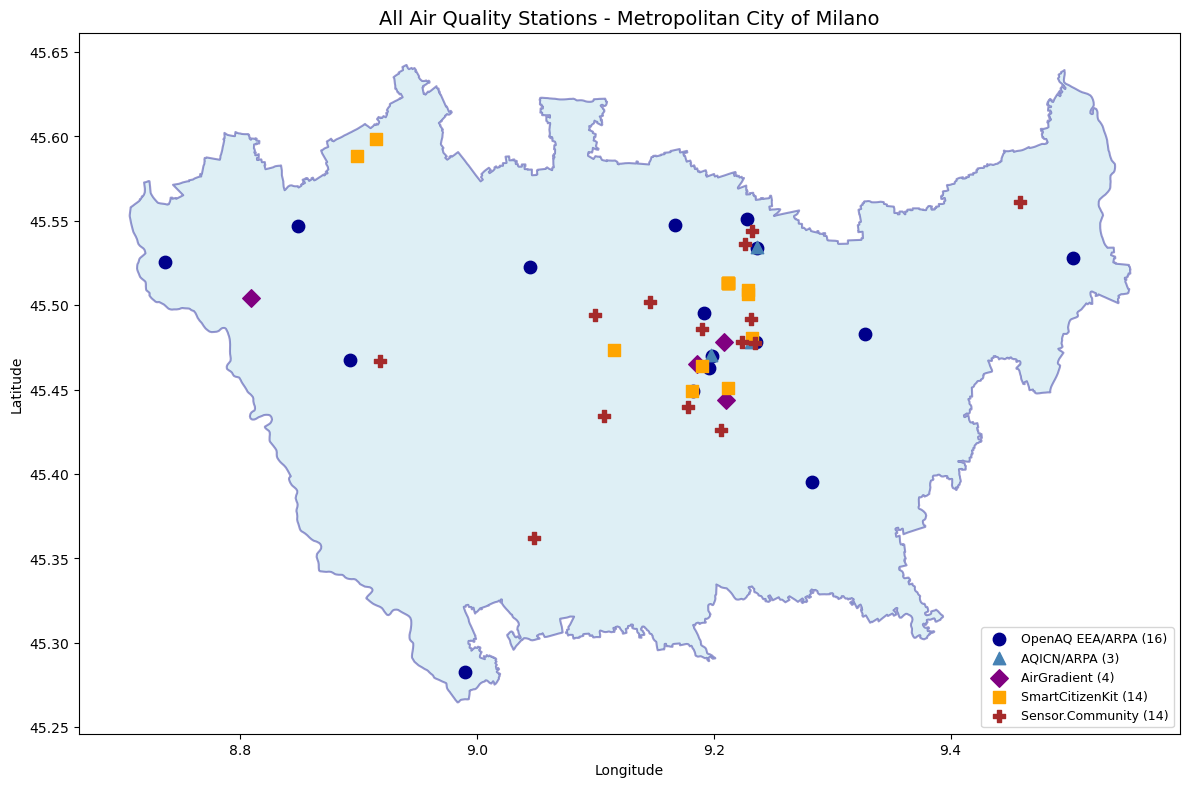


STATION SUMMARY - Metropolitan City of Milano

--- OFFICIAL ARPA DATA ---
  OpenAQ via EEA:         16 stations (official ARPA)
  AQICN:                   3 stations (official ARPA)

--- INDEPENDENT CITIZEN SENSORS ---
  AirGradient:             4 stations
  SmartCitizenKit:        14 devices
  Sensor.Community:       14 stations

--- TOTALS ---
  Official access points:   19 → 16 unique ARPA
  Independent sensors:      32 unique citizen sensors


In [14]:
# ── Combined static map - All Networks ────────────────────────
fig, ax = plt.subplots(figsize=(12, 9))
mcm.plot(ax=ax, color="lightblue", edgecolor="darkblue", linewidth=1.5, alpha=0.4)

# Official ARPA stations via OpenAQ EEA
openaq_eea_gdf.plot(ax=ax, color="darkblue", markersize=80, marker="o",
                    zorder=5, label=f"OpenAQ EEA/ARPA ({len(openaq_eea)})")

# AQICN (also ARPA)
aqicn_inside.plot(ax=ax, color="steelblue", markersize=80, marker="^",
                  zorder=5, label=f"AQICN/ARPA ({len(aqicn_inside)})")

# Independent citizen sensors
ag_inside_gdf.plot(ax=ax, color="purple", markersize=80, marker="D",
                   zorder=5, label=f"AirGradient ({len(ag_inside)})")
sck_inside.plot(ax=ax, color="orange", markersize=80, marker="s",
                zorder=5, label=f"SmartCitizenKit ({len(sck_inside)})")
sc_unique.plot(ax=ax, color="brown", markersize=80, marker="P",
               zorder=5, label=f"Sensor.Community ({len(sc_unique)})")

ax.set_title("All Air Quality Stations - Metropolitan City of Milano", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

# ── Station summary ───────────────────────────────────────────
print("\n" + "="*60)
print("STATION SUMMARY - Metropolitan City of Milano")
print("="*60)
print(f"\n--- OFFICIAL ARPA DATA ---")
print(f"  OpenAQ via EEA:       {len(openaq_eea):>4} stations (official ARPA)")
print(f"  AQICN:                {len(aqicn_inside):>4} stations (official ARPA)")
print(f"\n--- INDEPENDENT CITIZEN SENSORS ---")
print(f"  AirGradient:          {len(ag_inside):>4} stations")
print(f"  SmartCitizenKit:      {len(sck_inside):>4} devices")
print(f"  Sensor.Community:     {len(sc_unique):>4} stations")
print(f"\n--- TOTALS ---")
print(f"  Official access points: {len(openaq_eea) + len(aqicn_inside):>4} → 16 unique ARPA")
print(f"  Independent sensors:    {len(ag_inside) + len(sck_inside) + len(sc_unique):>4} unique citizen sensors")
print("="*60)

In [15]:
# ── OpenAQ - Fetch measurements per sensor ────────────────────
print("Fetching OpenAQ measurements... please wait")

openaq_measurements = []

for idx, station in openaq_inside.iterrows():
    station_id = station["station_id"]
    url = f"https://api.openaq.org/v3/locations/{station_id}/sensors"
    r = requests.get(url, headers={"X-API-Key": OPENAQ_KEY})
    if r.status_code != 200:
        continue
    sensors = r.json().get("results", [])
    for sensor in sensors:
        param = sensor.get("parameter", {})
        openaq_measurements.append({
            "network":      "OpenAQ",
            "provider":     station["provider"],
            "station_name": station["station_name"],
            "pollutant":    param.get("name"),
            "unit":         param.get("units"),
            "date_first":   sensor.get("datetimeFirst", {}).get("local") if sensor.get("datetimeFirst") else None,
            "date_last":    sensor.get("datetimeLast",  {}).get("local") if sensor.get("datetimeLast")  else None,
            "value_latest": sensor.get("latest", {}).get("value"),
        })

openaq_meas_df = pd.DataFrame(openaq_measurements)
print(f"Total OpenAQ sensor records: {len(openaq_meas_df)}")
print(openaq_meas_df[["station_name", "provider", "pollutant",
                       "unit", "date_first", "date_last"]].head(15).to_string())

Fetching OpenAQ measurements... please wait
Total OpenAQ sensor records: 68
          station_name provider pollutant   unit                 date_first                  date_last
0              TURBIGO      EEA       no2  µg/m³  2020-05-06T10:00:00+02:00  2026-05-19T18:00:00+02:00
1              TURBIGO      EEA      pm10  µg/m³  2024-01-29T00:00:00+01:00  2026-05-15T03:00:00+02:00
2              TURBIGO      EEA      pm25  µg/m³  2024-05-19T19:00:00+02:00  2026-05-19T03:00:00+02:00
3                  RHO      EEA       no2  µg/m³  2020-05-06T17:00:00+02:00  2026-05-19T18:00:00+02:00
4                  RHO      EEA        co  µg/m³  2020-05-06T20:00:00+02:00  2022-03-14T14:00:00+01:00
5          S. GIULIANO      EEA       no2  µg/m³  2020-05-06T16:00:00+02:00  2026-05-19T18:00:00+02:00
6          S. GIULIANO      EEA        co  µg/m³  2020-05-06T19:00:00+02:00  2026-05-19T18:00:00+02:00
7             ARCONATE      EEA        o3  µg/m³  2020-05-06T17:00:00+02:00  2026-05-19T18:00:00+02:

In [16]:
# ── AQICN - Fetch measurements for each station ───────────────
print("Fetching AQICN measurements... please wait")

aqicn_measurements = []

for idx, station in aqicn_inside.iterrows():
    city_name = station["city_queried"]
    url = f"https://api.waqi.info/feed/{city_name}/?token={AQICN_TOKEN}"
    r = requests.get(url).json()
    if r.get("status") != "ok":
        continue
    data      = r["data"]
    iaqi      = data.get("iaqi", {})
    time_info = data.get("time", {})

    pollutant_map = {
        "no2":  "NO2", "co":   "CO",  "so2": "SO2",
        "pm25": "PM2.5", "pm10": "PM10", "o3": "O3"
    }
    for key, name in pollutant_map.items():
        if key in iaqi:
            aqicn_measurements.append({
                "network":      "AQICN",
                "station_name": station["station_name"],
                "pollutant":    name,
                "unit":         "AQI index (ARPA source)",
                "value_latest": iaqi[key].get("v"),
                "date_first":   station["date_first"],
                "date_last":    station["date_last"],
            })

aqicn_meas_df = pd.DataFrame(aqicn_measurements)
print(f"Total AQICN sensor records: {len(aqicn_meas_df)}")
print(aqicn_meas_df[["station_name", "pollutant", "unit",
                      "value_latest", "date_first", "date_last"]].to_string())

Fetching AQICN measurements... please wait
Total AQICN sensor records: 12
                                   station_name pollutant                     unit  value_latest                 date_first                  date_last
0               Milano Senato, Lombardia, Italy       NO2  AQI index (ARPA source)          17.0  2020-05-06T17:00:00+02:00  2026-05-19T18:00:00+02:00
1               Milano Senato, Lombardia, Italy        CO  AQI index (ARPA source)           0.1  2020-05-06T17:00:00+02:00  2026-05-19T18:00:00+02:00
2               Milano Senato, Lombardia, Italy     PM2.5  AQI index (ARPA source)          30.0  2020-05-06T17:00:00+02:00  2026-05-19T18:00:00+02:00
3               Milano Senato, Lombardia, Italy      PM10  AQI index (ARPA source)          11.0  2020-05-06T17:00:00+02:00  2026-05-19T18:00:00+02:00
4         Sesto San Giovanni , Lombardia, Italy       NO2  AQI index (ARPA source)          22.4  2020-05-06T18:00:00+02:00  2026-05-19T18:00:00+02:00
5         Sesto San 

In [17]:
# ── SCK - Fetch sensor data for active devices ────────────────
print("Fetching SmartCitizenKit measurements... please wait")

sck_active = sck_inside[sck_inside["date_last"].notna()].copy()
print(f"Active SCK devices: {len(sck_active)}")

sck_measurements = []

for idx, station in sck_active.iterrows():
    device_id = station["station_id"]
    url = f"https://api.smartcitizen.me/v0/devices/{device_id}"
    r = requests.get(url).json()
    sensors = r.get("data", {}).get("sensors", [])
    for sensor in sensors:
        measurement = sensor.get("measurement", {})
        name = measurement.get("name") if measurement else None
        unit = sensor.get("unit")
        last_reading = sensor.get("last_reading_at")
        relevant = ["PM", "NO2", "CO", "O3", "SO2", "temperature",
                    "Relative Humidity", "co2", "noise"]
        if name and any(rel.lower() in name.lower() for rel in relevant):
            sck_measurements.append({
                "network":      "SmartCitizenKit",
                "station_name": station["station_name"],
                "pollutant":    name,
                "unit":         unit,
                "value_latest": sensor.get("value"),
                "date_first":   station["date_first"],
                "date_last":    last_reading,
            })

sck_meas_df = pd.DataFrame(sck_measurements)
print(f"Total SCK sensor records: {len(sck_meas_df)}")
print(sck_meas_df[["station_name", "pollutant", "unit",
                    "value_latest", "date_first", "date_last"]].to_string())

Fetching SmartCitizenKit measurements... please wait
Active SCK devices: 11
Total SCK sensor records: 66
         station_name                pollutant   unit  value_latest            date_first             date_last
0                alab        Relative Humidity      %     58.422119  2015-05-24T21:47:12Z  2019-03-07T19:18:58Z
1                alab          Air Temperature     ºC     16.530808  2015-05-24T21:47:12Z  2019-03-07T19:18:58Z
2                alab                       co   kOhm    901.806000  2015-05-24T21:47:12Z  2019-03-07T19:18:58Z
3                alab                      no2   kOhm    183.994000  2015-05-24T21:47:12Z  2019-03-07T19:18:58Z
4                alab              Noise Level     dB     50.000000  2015-05-24T21:47:12Z  2019-03-07T19:18:58Z
5       Via Gentilino                      PM1  ug/m3      5.400000  2025-09-25T15:24:01Z  2026-05-20T11:46:14Z
6       Via Gentilino                     PM10  ug/m3      6.000000  2025-09-25T15:24:01Z  2026-05-20T11:46:14Z

In [18]:
# ── AirGradient - Fetch measurements for each station ─────────
print("Fetching AirGradient measurements... please wait")
print(f"AirGradient columns: {ag_inside.columns.tolist()}")

ag_measurements = []

for idx, station in ag_inside.iterrows():
    # station_id comes from OpenAQ locationId
    station_id   = station["station_id"]
    station_name = station["station_name"]

    # Try direct AirGradient API first
    url = f"https://api.airgradient.com/public/api/v1/world/locations/{station_id}/measures/current"
    r = requests.get(url)

    if r.status_code != 200:
        print(f"  {station_name}: Direct API failed (status {r.status_code}) - using OpenAQ data")
        # Fall back to OpenAQ sensor data
        oaq_url = f"https://api.openaq.org/v3/locations/{station_id}/sensors"
        r2 = requests.get(oaq_url, headers={"X-API-Key": OPENAQ_KEY})
        if r2.status_code != 200:
            continue
        sensors = r2.json().get("results", [])
        for sensor in sensors:
            param = sensor.get("parameter", {})
            ag_measurements.append({
                "network":      "AirGradient",
                "station_name": station_name,
                "owner":        station.get("owner", "Unknown"),
                "pollutant":    param.get("name", "").upper(),
                "unit":         param.get("units"),
                "value_latest": sensor.get("latest", {}).get("value"),
                "date_first":   station["date_first"],
                "date_last":    sensor.get("datetimeLast", {}).get("local") if sensor.get("datetimeLast") else None,
            })
        continue

    data = r.json()
    print(f"  {station_name}: OK")

    pollutant_map = {
        "pm01": ("PM1",               "µg/m³"),
        "pm02": ("PM2.5",             "µg/m³"),
        "pm10": ("PM10",              "µg/m³"),
        "rco2": ("CO2",               "ppm"),
        "atmp": ("Air Temperature",   "°C"),
        "rhum": ("Relative Humidity", "%"),
        "tvoc": ("TVOC",              "index"),
        "nox":  ("NOx",               "index"),
    }
    for key, (name, unit) in pollutant_map.items():
        if data.get(key) is not None:
            ag_measurements.append({
                "network":      "AirGradient",
                "station_name": station_name,
                "owner":        station.get("owner", "Unknown"),
                "pollutant":    name,
                "unit":         unit,
                "value_latest": data.get(key),
                "date_first":   station["date_first"],
                "date_last":    data.get("timestamp"),
            })

ag_meas_df = pd.DataFrame(ag_measurements)
print(f"\nTotal AirGradient sensor records: {len(ag_meas_df)}")
if len(ag_meas_df) > 0:
    print(ag_meas_df[["station_name", "pollutant", "unit",
                       "value_latest", "date_first", "date_last"]].to_string())
else:
    print("No records returned — stations may be offline")

Fetching AirGradient measurements... please wait
AirGradient columns: ['network', 'station_id', 'station_name', 'latitude', 'longitude', 'sensors', 'date_first', 'date_last', 'provider', 'owner', 'is_monitor', 'geometry']
  Cuggiono (via Albrizio): Direct API failed (status 404) - using OpenAQ data
  Porta Venezia: Direct API failed (status 404) - using OpenAQ data
  Milano: Direct API failed (status 404) - using OpenAQ data
  Via Valsugana: Direct API failed (status 404) - using OpenAQ data

Total AirGradient sensor records: 23
               station_name         pollutant           unit  value_latest                 date_first                  date_last
0   Cuggiono (via Albrizio)               PM1          µg/m³      0.800000  2024-10-07T23:00:00+02:00  2026-05-20T13:00:00+02:00
1   Cuggiono (via Albrizio)  RELATIVEHUMIDITY              %     39.000000  2024-10-07T23:00:00+02:00  2026-05-20T13:00:00+02:00
2   Cuggiono (via Albrizio)             UM003  particles/cm³    354.000000  20

In [19]:
# ── Sensor.Community - Fetch current measurements ─────────────
print("Fetching Sensor.Community measurements... please wait")

sc_measurements = []

for idx, station in sc_unique.iterrows():
    sensor_type = station["sensor_type"]
    pollutants  = station["pollutants"]
    values      = station["values"]
    date_last   = station["date_last"]

    pollutant_map = {
        "P1":          ("PM10",                  "µg/m³"),
        "P2":          ("PM2.5",                 "µg/m³"),
        "temperature": ("Temperature",           "°C"),
        "humidity":    ("Humidity",              "%"),
        "pressure":    ("Pressure",              "hPa"),
        "pressure_at_sealevel": ("Pressure at Sea Level", "hPa"),
    }

    for p_key, (p_name, p_unit) in pollutant_map.items():
        if p_key in pollutants and p_key in values:
            sc_measurements.append({
                "network":      "Sensor.Community",
                "station_id":   station["station_id"],
                "sensor_type":  sensor_type,
                "pollutant":    p_name,
                "unit":         p_unit,
                "value_latest": values.get(p_key),
                "date_first":   "2017-01-01",
                "date_last":    date_last,
            })

sc_meas_df = pd.DataFrame(sc_measurements)
print(f"Total Sensor.Community sensor records: {len(sc_meas_df)}")
print(sc_meas_df[["station_id", "sensor_type", "pollutant",
                   "unit", "value_latest", "date_first", "date_last"]].to_string())

Fetching Sensor.Community measurements... please wait
Total Sensor.Community sensor records: 26
     station_id sensor_type    pollutant   unit      value_latest  date_first            date_last
0   29372161926       DHT22  Temperature     °C              26.2  2017-01-01  2026-05-20 11:50:00
1   29372161926       DHT22     Humidity      %              39.0  2017-01-01  2026-05-20 11:50:00
2   29372161627      SDS011         PM10  µg/m³              0.88  2017-01-01  2026-05-20 11:49:58
3   29372161627      SDS011        PM2.5  µg/m³              0.40  2017-01-01  2026-05-20 11:49:58
4   29372161450      SDS011         PM10  µg/m³              2.70  2017-01-01  2026-05-20 11:49:57
5   29372161450      SDS011        PM2.5  µg/m³              1.92  2017-01-01  2026-05-20 11:49:57
6   29372161120      SDS011         PM10  µg/m³              7.25  2017-01-01  2026-05-20 11:49:54
7   29372161120      SDS011        PM2.5  µg/m³              1.80  2017-01-01  2026-05-20 11:49:54
8   293721593

In [20]:
# ── Build final comparative table with % null ─────────────────
final_rows = []

# ── OpenAQ EEA (Official ARPA) ────────────────────────────────
for pollutant in openaq_meas_df[openaq_meas_df["provider"]=="EEA"]["pollutant"].unique():
    subset = openaq_meas_df[
        (openaq_meas_df["provider"]  == "EEA") &
        (openaq_meas_df["pollutant"] == pollutant)
    ]
    dates_first = pd.to_datetime(subset["date_first"], utc=True, errors="coerce").dropna()
    dates_last  = pd.to_datetime(subset["date_last"],  utc=True, errors="coerce").dropna()
    min_date = dates_first.min().strftime("%Y-%m-%d") if len(dates_first) > 0 else "-"
    max_date = dates_last.max().strftime("%Y-%m-%d")  if len(dates_last)  > 0 else "-"
    nulls    = [null_pct(r["date_first"], r["date_last"]) for _, r in subset.iterrows()]
    nulls    = [n for n in nulls if n is not None]
    avg_null = round(sum(nulls)/len(nulls), 1) if nulls else None
    final_rows.append({
        "Network":             "OpenAQ (EEA/ARPA)",
        "Pollutant":           pollutant.upper(),
        "Unit":                subset["unit"].iloc[0],
        "Temporal Resolution": "Hourly",
        "Min Date":            min_date,
        "Max Date":            max_date,
        "% Null (2019-now)":   avg_null,
        "Source":              "Official ARPA Lombardia via EEA",
        "Note":                "Data starts 2020 not 2019"
    })

# ── OpenAQ AirGradient (Independent) ─────────────────────────
for pollutant in openaq_meas_df[openaq_meas_df["provider"]=="AirGradient"]["pollutant"].unique():
    subset = openaq_meas_df[
        (openaq_meas_df["provider"]  == "AirGradient") &
        (openaq_meas_df["pollutant"] == pollutant)
    ]
    dates_first = pd.to_datetime(subset["date_first"], utc=True, errors="coerce").dropna()
    dates_last  = pd.to_datetime(subset["date_last"],  utc=True, errors="coerce").dropna()
    min_date = dates_first.min().strftime("%Y-%m-%d") if len(dates_first) > 0 else "-"
    max_date = dates_last.max().strftime("%Y-%m-%d")  if len(dates_last)  > 0 else "-"
    nulls    = [null_pct(r["date_first"], r["date_last"]) for _, r in subset.iterrows()]
    nulls    = [n for n in nulls if n is not None]
    avg_null = round(sum(nulls)/len(nulls), 1) if nulls else None
    final_rows.append({
        "Network":             "AirGradient",
        "Pollutant":           pollutant.upper(),
        "Unit":                subset["unit"].iloc[0],
        "Temporal Resolution": "Hourly",
        "Min Date":            min_date,
        "Max Date":            max_date,
        "% Null (2019-now)":   avg_null,
        "Source":              "Independent citizen sensors",
        "Note":                "Data starts 2024"
    })

# ── AQICN ─────────────────────────────────────────────────────
for pollutant in aqicn_meas_df["pollutant"].unique():
    subset = aqicn_meas_df[aqicn_meas_df["pollutant"] == pollutant]
    dates_first = pd.to_datetime(subset["date_first"], utc=True, errors="coerce").dropna()
    dates_last  = pd.to_datetime(subset["date_last"],  utc=True, errors="coerce").dropna()
    min_date = dates_first.min().strftime("%Y-%m-%d") if len(dates_first) > 0 else "-"
    max_date = dates_last.max().strftime("%Y-%m-%d")  if len(dates_last)  > 0 else "-"
    nulls    = [null_pct(r["date_first"], r["date_last"]) for _, r in subset.iterrows()]
    nulls    = [n for n in nulls if n is not None]
    avg_null = round(sum(nulls)/len(nulls), 1) if nulls else None
    final_rows.append({
        "Network":             "AQICN",
        "Pollutant":           pollutant,
        "Unit":                "AQI index",
        "Temporal Resolution": "Hourly",
        "Min Date":            min_date,
        "Max Date":            max_date,
        "% Null (2019-now)":   avg_null,
        "Source":              "Official ARPA Lombardia via AQICN",
        "Note":                "AQI index only - same ARPA source as OpenAQ"
    })

# ── SmartCitizenKit ───────────────────────────────────────────
for pollutant in sck_meas_df["pollutant"].unique():
    subset = sck_meas_df[sck_meas_df["pollutant"] == pollutant]
    dates_first = pd.to_datetime(subset["date_first"], utc=True, errors="coerce").dropna()
    dates_last  = pd.to_datetime(subset["date_last"],  utc=True, errors="coerce").dropna()
    min_date = dates_first.min().strftime("%Y-%m-%d") if len(dates_first) > 0 else "-"
    max_date = dates_last.max().strftime("%Y-%m-%d")  if len(dates_last)  > 0 else "-"
    nulls    = [null_pct(r["date_first"], r["date_last"]) for _, r in subset.iterrows()]
    nulls    = [n for n in nulls if n is not None]
    avg_null = round(sum(nulls)/len(nulls), 1) if nulls else None
    final_rows.append({
        "Network":             "SmartCitizenKit",
        "Pollutant":           pollutant,
        "Unit":                subset["unit"].iloc[0],
        "Temporal Resolution": "Every ~1 min",
        "Min Date":            min_date,
        "Max Date":            max_date,
        "% Null (2019-now)":   avg_null,
        "Source":              "Independent citizen sensors",
        "Note":                "CO/NO2 in kOhm on older devices"
    })

# ── Sensor.Community ──────────────────────────────────────────
for pollutant in sc_meas_df["pollutant"].unique():
    subset = sc_meas_df[sc_meas_df["pollutant"] == pollutant]
    nulls  = [null_pct("2017-01-01", r["date_last"]) for _, r in subset.iterrows()]
    nulls  = [n for n in nulls if n is not None]
    avg_null = round(sum(nulls)/len(nulls), 1) if nulls else 0.0
    final_rows.append({
        "Network":             "Sensor.Community",
        "Pollutant":           pollutant,
        "Unit":                subset["unit"].iloc[0],
        "Temporal Resolution": "Every ~2.5 min",
        "Min Date":            "2017-01-01",
        "Max Date":            str(sc_meas_df["date_last"].max())[:10],
        "% Null (2019-now)":   0.0,
        "Source":              "Independent citizen sensors",
        "Note":                "Archive from 2017; no NO2/SO2/O3/CO"
    })

# ── Build DataFrame and save ──────────────────────────────────
comp_df = pd.DataFrame(final_rows)

csv_path = r"C:\Msc Geo Informatics\2nd Year - 2nd Semester\Geo Informatics Project\comparative_table_final.csv"
comp_df.to_csv(csv_path, index=False)

print("Comparative table saved!")
print("\n" + "="*120)
print(comp_df.to_string(index=False))

Comparative table saved!

          Network               Pollutant          Unit Temporal Resolution   Min Date   Max Date  % Null (2019-now)                            Source                                        Note
OpenAQ (EEA/ARPA)                     NO2         µg/m³              Hourly 2020-05-06 2026-05-19               37.4   Official ARPA Lombardia via EEA                   Data starts 2020 not 2019
OpenAQ (EEA/ARPA)                    PM10         µg/m³              Hourly 2024-01-28 2026-05-19               68.9   Official ARPA Lombardia via EEA                   Data starts 2020 not 2019
OpenAQ (EEA/ARPA)                    PM25         µg/m³              Hourly 2024-01-28 2026-05-19               69.8   Official ARPA Lombardia via EEA                   Data starts 2020 not 2019
OpenAQ (EEA/ARPA)                      CO         µg/m³              Hourly 2020-05-06 2026-05-19               46.1   Official ARPA Lombardia via EEA                   Data starts 2020 not 2019

In [21]:
# ── Interactive Folium Map - All Networks ─────────────────────
m = folium.Map(location=[45.46, 9.19], zoom_start=10)

# Milano boundary
folium.GeoJson(
    mcm.__geo_interface__,
    style_function=lambda x: {
        "fillColor": "lightblue",
        "color": "darkblue",
        "weight": 2,
        "fillOpacity": 0.2
    }
).add_to(m)

# ── OpenAQ EEA (Official ARPA) ────────────────────────────────
for idx, row in openaq_eea.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=9, color="darkblue", fill=True,
        fill_color="darkblue", fill_opacity=0.8,
        popup=folium.Popup(
            f"<b>Official ARPA Station (via OpenAQ EEA)</b><br>"
            f"Name: {row['station_name']}<br>"
            f"Provider: EEA → ARPA Lombardia<br>"
            f"Sensors: {', '.join(row['sensors'])}<br>"
            f"First: {str(row['date_first'])[:10]}<br>"
            f"Last: {str(row['date_last'])[:10]}",
            max_width=300),
        tooltip=f"ARPA (OpenAQ): {row['station_name']}"
    ).add_to(m)

# ── AQICN (Official ARPA) ─────────────────────────────────────
for idx, row in aqicn_inside.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=9, color="steelblue", fill=True,
        fill_color="steelblue", fill_opacity=0.8,
        popup=folium.Popup(
            f"<b>Official ARPA Station (via AQICN)</b><br>"
            f"Name: {row['station_name']}<br>"
            f"Provider: ARPA Lombardia via AQICN<br>"
            f"Pollutants: {', '.join(row['pollutants'])}<br>"
            f"First: {str(row['date_first'])[:10]}<br>"
            f"Last: {str(row['date_last'])[:10]}",
            max_width=300),
        tooltip=f"ARPA (AQICN): {row['station_name']}"
    ).add_to(m)

# ── AirGradient (Independent) ─────────────────────────────────
for idx, row in ag_inside.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=8, color="purple", fill=True,
        fill_color="purple", fill_opacity=0.8,
        popup=folium.Popup(
            f"<b>Independent Citizen Sensor (AirGradient)</b><br>"
            f"Name: {row['station_name']}<br>"
            f"Owner: {row['owner']}<br>"
            f"First: {str(row['date_first'])[:10]}<br>"
            f"Last: {str(row['date_last'])[:10]}",
            max_width=300),
        tooltip=f"AirGradient: {row['station_name']}"
    ).add_to(m)

# ── SmartCitizenKit (Independent) ────────────────────────────
for idx, row in sck_inside.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=8, color="orange", fill=True,
        fill_color="orange", fill_opacity=0.8,
        popup=folium.Popup(
            f"<b>Independent Citizen Sensor (SmartCitizenKit)</b><br>"
            f"Name: {row['station_name']}<br>"
            f"State: {row['state']}<br>"
            f"First: {str(row['date_first'])[:10]}<br>"
            f"Last: {str(row['date_last'])[:10] if row['date_last'] else 'N/A'}",
            max_width=300),
        tooltip=f"SCK: {row['station_name']}"
    ).add_to(m)

# ── Sensor.Community (Independent) ───────────────────────────
for idx, row in sc_unique.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=8, color="brown", fill=True,
        fill_color="brown", fill_opacity=0.8,
        popup=folium.Popup(
            f"<b>Independent Citizen Sensor (Sensor.Community)</b><br>"
            f"ID: {row['station_id']}<br>"
            f"Type: {row['sensor_type']}<br>"
            f"Pollutants: {', '.join(row['pollutants'])}<br>"
            f"Archive from: 2017-01-01<br>"
            f"Last: {str(row['date_last'])[:10]}",
            max_width=300),
        tooltip=f"Sensor.Community: {row['station_id']}"
    ).add_to(m)

# ── Legend ────────────────────────────────────────────────────
legend_html = f"""
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
     background-color: white; padding: 12px; border-radius: 8px;
     border: 2px solid grey; font-size: 13px;">
  <b>Station Classification</b><br>
  <hr style="margin:4px 0">
  <b>Official ARPA Data:</b><br>
  <i style="background:darkblue;width:12px;height:12px;display:inline-block;
     border-radius:50%;margin-right:6px;"></i>OpenAQ via EEA ({len(openaq_eea)})<br>
  <i style="background:steelblue;width:12px;height:12px;display:inline-block;
     border-radius:50%;margin-right:6px;"></i>AQICN ({len(aqicn_inside)})<br>
  <hr style="margin:4px 0">
  <b>Independent Citizen Sensors:</b><br>
  <i style="background:purple;width:12px;height:12px;display:inline-block;
     border-radius:50%;margin-right:6px;"></i>AirGradient ({len(ag_inside)})<br>
  <i style="background:orange;width:12px;height:12px;display:inline-block;
     border-radius:50%;margin-right:6px;"></i>SmartCitizenKit ({len(sck_inside)})<br>
  <i style="background:brown;width:12px;height:12px;display:inline-block;
     border-radius:50%;margin-right:6px;"></i>Sensor.Community ({len(sc_unique)})<br>
  <hr style="margin:4px 0">
  <b>Official: {len(openaq_eea)+len(aqicn_inside)} access points → 16 unique ARPA</b><br>
  <b>Independent: {len(ag_inside)+len(sck_inside)+len(sc_unique)} citizen sensors</b>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Save
map_path = r"C:\Msc Geo Informatics\2nd Year - 2nd Semester\Geo Informatics Project\AQ_stations_map_final.html"
m.save(map_path)
print("Interactive map saved!")
m

Interactive map saved!


In [22]:
# ── Final Summary ─────────────────────────────────────────────
print("="*65)
print("FINAL SUMMARY - Metropolitan City of Milano")
print("="*65)

print("\n--- OFFICIAL ARPA DATA (same underlying source) ---")
print(f"  OpenAQ via EEA:        {len(openaq_eea):>4} stations")
print(f"  AQICN:                 {len(aqicn_inside):>4} stations")
print(f"  >> Both re-publish official ARPA Lombardia data")
print(f"  >> 16 unique ARPA stations")

print("\n--- INDEPENDENT CITIZEN SENSORS ---")
print(f"  AirGradient:           {len(ag_inside):>4} stations")
print(f"  SmartCitizenKit:       {len(sck_inside):>4} devices")
print(f"  Sensor.Community:      {len(sc_unique):>4} stations")
print(f"  >> Total independent:  {len(ag_inside)+len(sck_inside)+len(sc_unique):>4} sensors")

print("\n--- FILES SAVED ---")
print(f"  - comparative_table_final.csv")
print(f"  - AQ_stations_map_final.html")
print("="*65)

FINAL SUMMARY - Metropolitan City of Milano

--- OFFICIAL ARPA DATA (same underlying source) ---
  OpenAQ via EEA:          16 stations
  AQICN:                    3 stations
  >> Both re-publish official ARPA Lombardia data
  >> 16 unique ARPA stations

--- INDEPENDENT CITIZEN SENSORS ---
  AirGradient:              4 stations
  SmartCitizenKit:         14 devices
  Sensor.Community:        14 stations
  >> Total independent:    32 sensors

--- FILES SAVED ---
  - comparative_table_final.csv
  - AQ_stations_map_final.html


In [23]:
# ── Load Official Lombardia Stations (ARPA) ───────────────────
lombardia_df = pd.read_csv(
    r"C:\Msc Geo Informatics\2nd Year - 2nd Semester\Geo Informatics Project\Stazioni_qualità_dell'aria_NRT_20260327.csv"
)

print(f"Total sensor records: {len(lombardia_df)}")
print(f"Columns: {lombardia_df.columns.tolist()}")

# ── Translate pollutant names from Italian to English ─────────
pollutant_translation = {
    "Biossido di Azoto":          "NO2",
    "Monossido di Carbonio":      "CO",
    "Biossido di Zolfo":          "SO2",
    "Ozono":                      "O3",
    "PM10 (SM2005)":              "PM10",
    "PM10":                       "PM10",
    "PM2.5":                      "PM2.5",
    "Benzene":                    "Benzene",
    "Monossido di Azoto":         "NO",
    "Ossidi di Azoto":            "NOx",
    "Particolato Totale Sospeso": "TSP",
    "Arsenico":                   "Arsenic",
    "Cadmio":                     "Cadmium",
    "Nichel":                     "Nickel",
    "Piombo":                     "Lead",
    "Benzo(a)pirene":             "BaP",
    "Particelle sospese PM2.5":   "PM2.5",
}

lombardia_df["Pollutant_EN"] = lombardia_df["NomeTipoSensore"].map(
    pollutant_translation).fillna(lombardia_df["NomeTipoSensore"])

# ── Get unique stations ────────────────────────────────────────
lombardia_stations = lombardia_df.drop_duplicates(subset=["IdStazione"]).copy()
lombardia_stations["latitude"]  = lombardia_stations["lat"].astype(float)
lombardia_stations["longitude"] = lombardia_stations["lng"].astype(float)

print(f"\nUnique official stations total: {len(lombardia_stations)}")
print(f"\nPollutants measured (translated):")
print(lombardia_df["Pollutant_EN"].unique())
print(f"\nProvinces covered:")
print(lombardia_df["Provincia"].unique())

Total sensor records: 216
Columns: ['idSensore', 'NomeTipoSensore', 'UnitaMisura', 'IdStazione', 'NomeStazione', 'Quota', 'Provincia', 'Comune', 'UTM_Nord', 'UTM_Est', 'lat', 'lng']

Unique official stations total: 83

Pollutants measured (translated):
['NO2' 'SO2' 'O3' 'CO' 'Benzene' 'PM10' 'PM2.5']

Provinces covered:
['MI' 'MB' 'VA' 'CO' 'SO' 'LC' 'BG' 'LO' 'CR' 'PV' 'BS' 'MN']


In [24]:
# ── Filter official stations inside Milano boundary ───────────
lombardia_gdf = gpd.GeoDataFrame(
    lombardia_stations,
    geometry=[Point(float(row.lng), float(row.lat))
              for row in lombardia_stations.itertuples()],
    crs="EPSG:4326"
)

lombardia_inside = lombardia_gdf[lombardia_gdf.geometry.within(milano_polygon)].copy()

print(f"Total official ARPA stations in Lombardia: {len(lombardia_stations)}")
print(f"Official ARPA stations inside Milano:      {len(lombardia_inside)}")
print("\nOfficial stations inside Milano:")
print(lombardia_inside[["IdStazione", "NomeStazione", "Comune",
                         "lat", "lng"]].to_string())

print("\nPollutants per official station:")
for station_id in lombardia_inside["IdStazione"].unique():
    pollutants = lombardia_df[
        lombardia_df["IdStazione"] == station_id
    ]["Pollutant_EN"].tolist()
    name = lombardia_inside[
        lombardia_inside["IdStazione"] == station_id
    ]["NomeStazione"].values[0]
    print(f"  {name}: {', '.join(pollutants)}")

Total official ARPA stations in Lombardia: 83
Official ARPA stations inside Milano:      16

Official stations inside Milano:
     IdStazione                           NomeStazione                 Comune        lat       lng
0           501                        Milano v.Marche                 Milano  45.496319  9.190934
1           504  Sesto San Giovanni v. Cesare da Sesto     Sesto San Giovanni  45.534768  9.236109
2           514                      Rho via Buon Gesù                    Rho  45.523429  9.044602
3           517                                Turbigo                Turbigo  45.526556  8.736502
4           528                        Milano Verziere                 Milano  45.463349  9.195325
5           529            Cinisello Balsamo v.Lincoln      Cinisello Balsamo  45.552328  9.227766
6           531                       Pioltello Limito              Pioltello  45.483632  9.327362
7           539                       Milano v.Liguria                 Milano  45.

In [25]:
# ── Compare discovered stations with official ARPA stations ───
DISTANCE_THRESHOLD = 0.01  # ~1km

print("="*70)
print("COMPARISON: Discovered Stations vs Official ARPA Stations")
print("="*70)

# ── Combine all discovered stations ───────────────────────────
all_discovered = []

for idx, row in openaq_eea.iterrows():
    all_discovered.append({
        "network": "OpenAQ (EEA/ARPA)", "name": row["station_name"],
        "lat": row["latitude"], "lon": row["longitude"]
    })
for idx, row in aqicn_inside.iterrows():
    all_discovered.append({
        "network": "AQICN", "name": row["station_name"],
        "lat": row["latitude"], "lon": row["longitude"]
    })
for idx, row in ag_inside.iterrows():
    all_discovered.append({
        "network": "AirGradient", "name": row["station_name"],
        "lat": row["latitude"], "lon": row["longitude"]
    })
for idx, row in sck_inside.iterrows():
    all_discovered.append({
        "network": "SmartCitizenKit", "name": row["station_name"],
        "lat": row["latitude"], "lon": row["longitude"]
    })
for idx, row in sc_unique.iterrows():
    all_discovered.append({
        "network": "Sensor.Community", "name": str(row["station_id"]),
        "lat": row["latitude"], "lon": row["longitude"]
    })

discovered_gdf = gpd.GeoDataFrame(
    all_discovered,
    geometry=[Point(r["lon"], r["lat"]) for r in all_discovered],
    crs="EPSG:4326"
)

print(f"\nTotal discovered stations: {len(discovered_gdf)}")
print(f"Total official ARPA stations inside Milano: {len(lombardia_inside)}")

# ── Compare each ARPA station with discovered ─────────────────
print("\n" + "="*70)
print("OFFICIAL ARPA STATIONS vs DISCOVERED (within ~1km)")
print("="*70)

overlap_rows = []

for idx, arpa in lombardia_inside.iterrows():
    arpa_point = Point(float(arpa["lng"]), float(arpa["lat"]))

    nearby = []
    for _, disc in discovered_gdf.iterrows():
        dist = arpa_point.distance(disc.geometry)
        if dist < DISTANCE_THRESHOLD:
            nearby.append({
                "network":      disc["network"],
                "name":         disc["name"],
                "distance_km":  round(dist * 111, 2)
            })

    arpa_pollutants = lombardia_df[
        lombardia_df["IdStazione"] == arpa["IdStazione"]
    ]["Pollutant_EN"].tolist()

    status = "OVERLAP" if nearby else "NO OVERLAP"
    print(f"\n[{status}] {arpa['NomeStazione']} ({arpa['Comune']})")
    print(f"  ARPA Pollutants: {', '.join(arpa_pollutants)}")
    if nearby:
        for n in nearby:
            print(f"  >> {n['network']}: {n['name']} ({n['distance_km']} km)")

    overlap_rows.append({
        "ARPA Station":             arpa["NomeStazione"],
        "Comune":                   arpa["Comune"],
        "ARPA Pollutants":          ", ".join(arpa_pollutants),
        "Overlap Found":            "Yes" if nearby else "No",
        "Overlapping Networks":     ", ".join(set(n["network"] for n in nearby)),
        "Overlapping Station Names":
            ", ".join(n["name"] for n in nearby),
        "Min Distance (km)":
            min(n["distance_km"] for n in nearby) if nearby else "-"
    })

overlap_df = pd.DataFrame(overlap_rows)

# ── Summary ───────────────────────────────────────────────────
print("\n" + "="*70)
print("OVERLAP SUMMARY")
print("="*70)
overlapping     = overlap_df[overlap_df["Overlap Found"] == "Yes"]
not_overlapping = overlap_df[overlap_df["Overlap Found"] == "No"]
print(f"ARPA stations WITH overlap:    {len(overlapping)}")
print(f"ARPA stations WITHOUT overlap: {len(not_overlapping)}")
print(f"\nStations with NO overlap:")
print(not_overlapping[["ARPA Station", "Comune",
                        "ARPA Pollutants"]].to_string(index=False))
print(f"\nOverlap rate: {len(overlapping)}/{len(lombardia_inside)} = "
      f"{len(overlapping)/len(lombardia_inside)*100:.0f}%")

# Save
csv_path = r"C:\Msc Geo Informatics\2nd Year - 2nd Semester\Geo Informatics Project\station_comparison.csv"
overlap_df.to_csv(csv_path, index=False)
print("\nComparison table saved!")

COMPARISON: Discovered Stations vs Official ARPA Stations

Total discovered stations: 51
Total official ARPA stations inside Milano: 16

OFFICIAL ARPA STATIONS vs DISCOVERED (within ~1km)

[OVERLAP] Milano v.Marche (Milano)
  ARPA Pollutants: NO2, CO, Benzene, PM10, PM2.5
  >> OpenAQ (EEA/ARPA): MILANO - V.LE MARCHE (0.1 km)

[OVERLAP] Sesto San Giovanni v. Cesare da Sesto (Sesto San Giovanni)
  ARPA Pollutants: NO2, CO
  >> OpenAQ (EEA/ARPA): SESTO S.GIOVANNI (0.1 km)
  >> AQICN: Sesto San Giovanni , Lombardia, Italy (0.0 km)
  >> Sensor.Community: 29372143008 (1.1 km)

[OVERLAP] Rho via Buon Gesù (Rho)
  ARPA Pollutants: NO2
  >> OpenAQ (EEA/ARPA): RHO (0.1 km)

[OVERLAP] Turbigo (Turbigo)
  ARPA Pollutants: NO2
  >> OpenAQ (EEA/ARPA): TURBIGO (0.08 km)

[OVERLAP] Milano Verziere (Milano)
  ARPA Pollutants: NO2, O3, PM10
  >> OpenAQ (EEA/ARPA): MILANO - SENATO (0.77 km)
  >> OpenAQ (EEA/ARPA): MILANO - VERZIERE (0.08 km)
  >> AQICN: Milano Senato, Lombardia, Italy (0.83 km)
  >> AirG

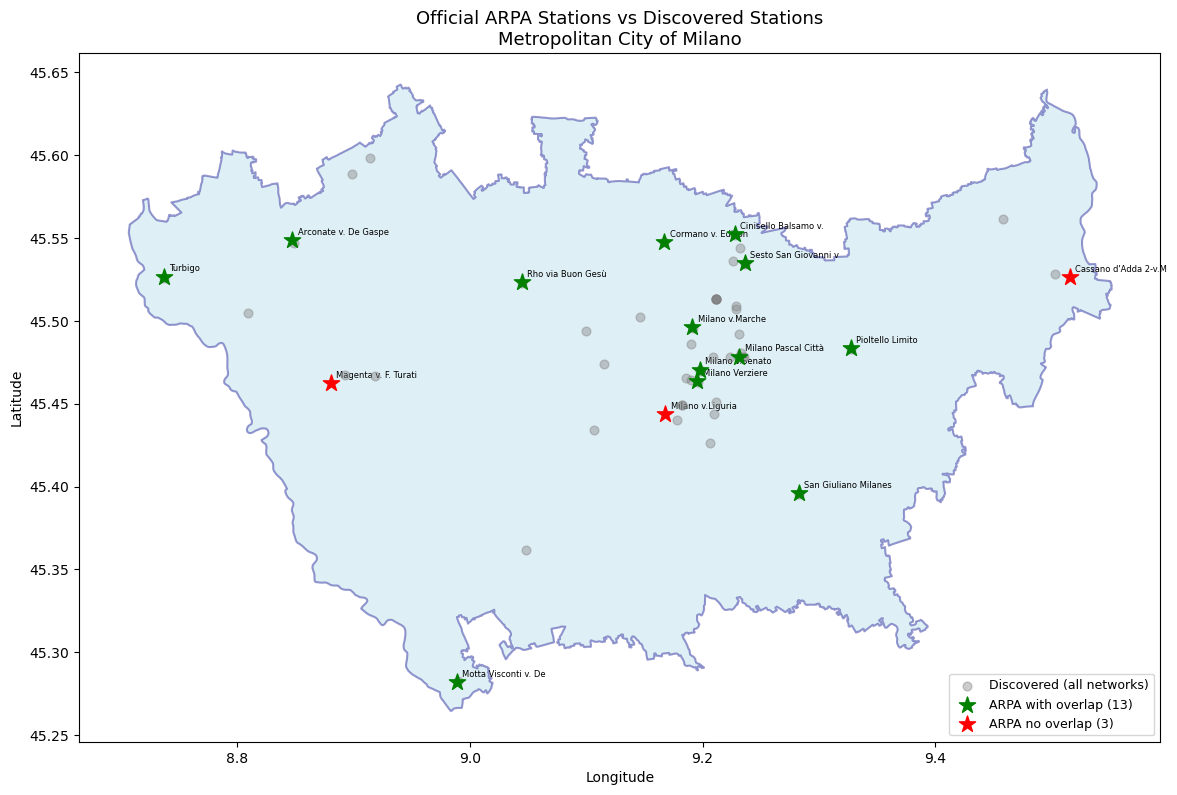

Overlap rate: 13/16 = 81%


In [26]:
# ── Static comparison map ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 9))
mcm.plot(ax=ax, color="lightblue", edgecolor="darkblue", linewidth=1.5, alpha=0.4)

# All discovered stations (grey background)
discovered_gdf.plot(ax=ax, color="grey", markersize=40, marker="o",
                    alpha=0.4, zorder=4, label="Discovered (all networks)")

# ARPA WITH overlap (green star)
overlapping_arpa = lombardia_inside[
    lombardia_inside["NomeStazione"].isin(
        overlap_df[overlap_df["Overlap Found"] == "Yes"]["ARPA Station"])
].copy()

overlapping_arpa_gdf = gpd.GeoDataFrame(
    overlapping_arpa,
    geometry=[Point(float(r.lng), float(r.lat))
              for r in overlapping_arpa.itertuples()],
    crs="EPSG:4326"
)
overlapping_arpa_gdf.plot(ax=ax, color="green", markersize=150,
                           marker="*", zorder=6,
                           label=f"ARPA with overlap ({len(overlapping_arpa_gdf)})")

# ARPA WITHOUT overlap (red star)
no_overlap_arpa = lombardia_inside[
    lombardia_inside["NomeStazione"].isin(
        overlap_df[overlap_df["Overlap Found"] == "No"]["ARPA Station"])
].copy()

no_overlap_arpa_gdf = gpd.GeoDataFrame(
    no_overlap_arpa,
    geometry=[Point(float(r.lng), float(r.lat))
              for r in no_overlap_arpa.itertuples()],
    crs="EPSG:4326"
)
no_overlap_arpa_gdf.plot(ax=ax, color="red", markersize=150,
                          marker="*", zorder=6,
                          label=f"ARPA no overlap ({len(no_overlap_arpa_gdf)})")

# Labels
for idx, row in lombardia_inside.iterrows():
    ax.annotate(
        row["NomeStazione"][:20],
        xy=(float(row["lng"]), float(row["lat"])),
        xytext=(4, 4), textcoords="offset points", fontsize=6
    )

ax.set_title("Official ARPA Stations vs Discovered Stations\nMetropolitan City of Milano", fontsize=13)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

print(f"Overlap rate: {len(overlapping_arpa_gdf)}/{len(lombardia_inside)} = "
      f"{len(overlapping_arpa_gdf)/len(lombardia_inside)*100:.0f}%")

In [27]:
# ── Interactive Folium Comparison Map ─────────────────────────
m_compare = folium.Map(location=[45.46, 9.19], zoom_start=10)

# Milano boundary
folium.GeoJson(
    mcm.__geo_interface__,
    style_function=lambda x: {
        "fillColor": "lightblue",
        "color": "darkblue",
        "weight": 2,
        "fillOpacity": 0.2
    }
).add_to(m_compare)

# ── All discovered stations (grey) ────────────────────────────
for _, row in discovered_gdf.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=6, color="grey", fill=True,
        fill_color="grey", fill_opacity=0.5,
        popup=folium.Popup(
            f"<b>{row['network']}</b><br>Name: {row['name']}",
            max_width=250),
        tooltip=f"{row['network']}: {row['name']}"
    ).add_to(m_compare)

# ── ARPA stations WITH overlap (green star) ───────────────────
for _, row in overlap_df[overlap_df["Overlap Found"] == "Yes"].iterrows():
    arpa_row = lombardia_inside[
        lombardia_inside["NomeStazione"] == row["ARPA Station"]
    ].iloc[0]
    folium.Marker(
        location=[float(arpa_row["lat"]), float(arpa_row["lng"])],
        popup=folium.Popup(
            f"<b>ARPA Official Station - OVERLAP</b><br>"
            f"Name: {row['ARPA Station']}<br>"
            f"Comune: {row['Comune']}<br>"
            f"Pollutants: {row['ARPA Pollutants']}<br>"
            f"Networks nearby: {row['Overlapping Networks']}<br>"
            f"Nearby stations: {row['Overlapping Station Names']}<br>"
            f"Min distance: {row['Min Distance (km)']} km",
            max_width=350),
        tooltip=f"ARPA (overlap): {row['ARPA Station']}",
        icon=folium.Icon(color="green", icon="star", prefix="fa")
    ).add_to(m_compare)

# ── ARPA stations WITHOUT overlap (red star) ──────────────────
for _, row in overlap_df[overlap_df["Overlap Found"] == "No"].iterrows():
    arpa_row = lombardia_inside[
        lombardia_inside["NomeStazione"] == row["ARPA Station"]
    ].iloc[0]
    folium.Marker(
        location=[float(arpa_row["lat"]), float(arpa_row["lng"])],
        popup=folium.Popup(
            f"<b>ARPA Official Station - NO OVERLAP</b><br>"
            f"Name: {row['ARPA Station']}<br>"
            f"Comune: {row['Comune']}<br>"
            f"Pollutants: {row['ARPA Pollutants']}<br>"
            f"No nearby stations found within 1km",
            max_width=300),
        tooltip=f"ARPA (no overlap): {row['ARPA Station']}",
        icon=folium.Icon(color="red", icon="star", prefix="fa")
    ).add_to(m_compare)

# ── Legend ────────────────────────────────────────────────────
legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
     background-color: white; padding: 12px; border-radius: 8px;
     border: 2px solid grey; font-size: 13px;">
  <b>Station Comparison</b><br>
  <i style="background:grey;width:12px;height:12px;display:inline-block;
     border-radius:50%;margin-right:6px;"></i>Discovered stations<br>
  <i style="color:green;margin-right:6px;">★</i>ARPA with overlap (13)<br>
  <i style="color:red;margin-right:6px;">★</i>ARPA no overlap (3)<br>
  <hr style="margin:4px 0">
  <b>Overlap rate: 81%</b><br>
  <b>Distance threshold: 1km</b>
</div>
"""
m_compare.get_root().html.add_child(folium.Element(legend_html))

# Save
map_path = r"C:\Msc Geo Informatics\2nd Year - 2nd Semester\Geo Informatics Project\AQ_station_comparison_map.html"
m_compare.save(map_path)
print("Comparison map saved!")
m_compare

Comparison map saved!


In [28]:
# ── Final Classification Map - Official vs Independent ────────
m_final = folium.Map(location=[45.46, 9.19], zoom_start=10)

# Milano boundary
folium.GeoJson(
    mcm.__geo_interface__,
    style_function=lambda x: {
        "fillColor": "lightblue",
        "color": "darkblue",
        "weight": 2,
        "fillOpacity": 0.2
    }
).add_to(m_final)

# ── OpenAQ EEA (Official ARPA) ────────────────────────────────
for _, row in openaq_eea.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=10, color="darkblue", fill=True,
        fill_color="darkblue", fill_opacity=0.8,
        popup=folium.Popup(
            f"<b>Official ARPA Station (OpenAQ EEA)</b><br>"
            f"Name: {row['station_name']}<br>"
            f"Source: ARPA Lombardia via EEA<br>"
            f"Sensors: {', '.join(row['sensors'])}<br>"
            f"First: {str(row['date_first'])[:10]}<br>"
            f"Last: {str(row['date_last'])[:10]}",
            max_width=300),
        tooltip=f"ARPA (OpenAQ): {row['station_name']}"
    ).add_to(m_final)

# ── AQICN (Official ARPA) ─────────────────────────────────────
for _, row in aqicn_inside.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=10, color="steelblue", fill=True,
        fill_color="steelblue", fill_opacity=0.8,
        popup=folium.Popup(
            f"<b>Official ARPA Station (AQICN)</b><br>"
            f"Name: {row['station_name']}<br>"
            f"Source: ARPA Lombardia via AQICN<br>"
            f"Pollutants: {', '.join(row['pollutants'])}<br>"
            f"First: {str(row['date_first'])[:10]}<br>"
            f"Last: {str(row['date_last'])[:10]}",
            max_width=300),
        tooltip=f"ARPA (AQICN): {row['station_name']}"
    ).add_to(m_final)

# ── AirGradient (Independent) ─────────────────────────────────
for _, row in ag_inside.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=8, color="purple", fill=True,
        fill_color="purple", fill_opacity=0.8,
        popup=folium.Popup(
            f"<b>Independent Citizen Sensor (AirGradient)</b><br>"
            f"Name: {row['station_name']}<br>"
            f"Owner: {row['owner']}<br>"
            f"First: {str(row['date_first'])[:10]}<br>"
            f"Last: {str(row['date_last'])[:10]}",
            max_width=300),
        tooltip=f"AirGradient: {row['station_name']}"
    ).add_to(m_final)

# ── SmartCitizenKit (Independent) ────────────────────────────
for _, row in sck_inside.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=8, color="orange", fill=True,
        fill_color="orange", fill_opacity=0.8,
        popup=folium.Popup(
            f"<b>Independent Citizen Sensor (SmartCitizenKit)</b><br>"
            f"Name: {row['station_name']}<br>"
            f"State: {row['state']}<br>"
            f"First: {str(row['date_first'])[:10]}<br>"
            f"Last: {str(row['date_last'])[:10] if row['date_last'] else 'N/A'}",
            max_width=300),
        tooltip=f"SCK: {row['station_name']}"
    ).add_to(m_final)

# ── Sensor.Community (Independent) ───────────────────────────
for _, row in sc_unique.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=8, color="brown", fill=True,
        fill_color="brown", fill_opacity=0.8,
        popup=folium.Popup(
            f"<b>Independent Citizen Sensor (Sensor.Community)</b><br>"
            f"ID: {row['station_id']}<br>"
            f"Type: {row['sensor_type']}<br>"
            f"Pollutants: {', '.join(row['pollutants'])}<br>"
            f"Archive from: 2017-01-01<br>"
            f"Last: {str(row['date_last'])[:10]}",
            max_width=300),
        tooltip=f"Sensor.Community: {row['station_id']}"
    ).add_to(m_final)

# ── Legend ────────────────────────────────────────────────────
legend_html = f"""
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
     background-color: white; padding: 12px; border-radius: 8px;
     border: 2px solid grey; font-size: 13px;">
  <b>Station Classification</b><br>
  <hr style="margin:4px 0">
  <b>Official ARPA Data:</b><br>
  <i style="background:darkblue;width:12px;height:12px;display:inline-block;
     border-radius:50%;margin-right:6px;"></i>OpenAQ via EEA ({len(openaq_eea)})<br>
  <i style="background:steelblue;width:12px;height:12px;display:inline-block;
     border-radius:50%;margin-right:6px;"></i>AQICN ({len(aqicn_inside)})<br>
  <hr style="margin:4px 0">
  <b>Independent Citizen Sensors:</b><br>
  <i style="background:purple;width:12px;height:12px;display:inline-block;
     border-radius:50%;margin-right:6px;"></i>AirGradient ({len(ag_inside)})<br>
  <i style="background:orange;width:12px;height:12px;display:inline-block;
     border-radius:50%;margin-right:6px;"></i>SmartCitizenKit ({len(sck_inside)})<br>
  <i style="background:brown;width:12px;height:12px;display:inline-block;
     border-radius:50%;margin-right:6px;"></i>Sensor.Community ({len(sc_unique)})<br>
  <hr style="margin:4px 0">
  <b>Official: {len(openaq_eea)+len(aqicn_inside)} access points → 16 unique ARPA</b><br>
  <b>Independent: {len(ag_inside)+len(sck_inside)+len(sc_unique)} citizen sensors</b>
</div>
"""
m_final.get_root().html.add_child(folium.Element(legend_html))

# Save
map_path = r"C:\Msc Geo Informatics\2nd Year - 2nd Semester\Geo Informatics Project\AQ_stations_map_updated.html"
m_final.save(map_path)
print("Final classification map saved!")
m_final

Final classification map saved!


In [29]:
# ── Final Summary ─────────────────────────────────────────────
print("="*65)
print("FINAL SUMMARY - Metropolitan City of Milano")
print("="*65)

print("\n--- OFFICIAL ARPA DATA (same underlying source) ---")
print(f"  OpenAQ via EEA:        {len(openaq_eea):>4} stations")
print(f"  AQICN:                 {len(aqicn_inside):>4} stations")
print(f"  >> Both re-publish official ARPA Lombardia data")
print(f"  >> 16 unique ARPA stations inside Milano")

print("\n--- INDEPENDENT CITIZEN SENSORS ---")
print(f"  AirGradient:           {len(ag_inside):>4} stations")
print(f"  SmartCitizenKit:       {len(sck_inside):>4} devices")
print(f"  Sensor.Community:      {len(sc_unique):>4} stations")
print(f"  >> Total independent:  {len(ag_inside)+len(sck_inside)+len(sc_unique):>4} sensors")

print("\n--- ARPA COMPARISON ---")
print(f"  Official ARPA stations inside Milano:     16")
print(f"  ARPA stations WITH overlap discovered:    13 (81%)")
print(f"  ARPA stations WITHOUT overlap:             3 (19%)")
print(f"  >> 3 uncovered stations all measure NO2 only")
print(f"  >> Milano v.Liguria, Magenta v.F.Turati, Cassano d'Adda 2")

print("\n--- KEY INSIGHT ---")
print(f"  OpenAQ + AQICN are NOT independent networks")
print(f"  They re-publish official ARPA Lombardia data")
print(f"  Truly independent networks:")
print(f"  AirGradient, SmartCitizenKit, Sensor.Community")

print("\n--- FILES SAVED ---")
print(f"  - comparative_table_final.csv")
print(f"  - AQ_stations_map_final.html")
print(f"  - AQ_station_comparison_map.html")
print(f"  - AQ_stations_map_updated.html")
print(f"  - station_comparison.csv")

print("\n" + "="*65)
print("ALL TASKS COMPLETED!")
print("="*65)

FINAL SUMMARY - Metropolitan City of Milano

--- OFFICIAL ARPA DATA (same underlying source) ---
  OpenAQ via EEA:          16 stations
  AQICN:                    3 stations
  >> Both re-publish official ARPA Lombardia data
  >> 16 unique ARPA stations inside Milano

--- INDEPENDENT CITIZEN SENSORS ---
  AirGradient:              4 stations
  SmartCitizenKit:         14 devices
  Sensor.Community:        14 stations
  >> Total independent:    32 sensors

--- ARPA COMPARISON ---
  Official ARPA stations inside Milano:     16
  ARPA stations WITH overlap discovered:    13 (81%)
  ARPA stations WITHOUT overlap:             3 (19%)
  >> 3 uncovered stations all measure NO2 only
  >> Milano v.Liguria, Magenta v.F.Turati, Cassano d'Adda 2

--- KEY INSIGHT ---
  OpenAQ + AQICN are NOT independent networks
  They re-publish official ARPA Lombardia data
  Truly independent networks:
  AirGradient, SmartCitizenKit, Sensor.Community

--- FILES SAVED ---
  - comparative_table_final.csv
  - AQ_sta

In [30]:
# ── Cell 30: ARPA Comparison — Independent Sensors Only (MCM) ─
# Step 2 update (10 April 2026 meeting):
# Remove OpenAQ EEA and AQICN (same ARPA source)
# Compare official ARPA stations only with truly independent sensors

DISTANCE_THRESHOLD = 0.01  # ~1km

print("=" * 70)
print("COMPARISON: ARPA vs INDEPENDENT SENSORS ONLY (MCM boundary)")
print("Excluded: OpenAQ EEA, AQICN (re-publish ARPA — not independent)")
print("Included: AirGradient, SmartCitizenKit, Sensor.Community")
print("=" * 70)

# ── Build independent-only discovered GDF ─────────────────────
independent_only = []

for idx, row in ag_inside.iterrows():
    independent_only.append({
        "network": "AirGradient",
        "name":    row["station_name"],
        "lat":     row["latitude"],
        "lon":     row["longitude"]
    })
for idx, row in sck_inside.iterrows():
    independent_only.append({
        "network": "SmartCitizenKit",
        "name":    row["station_name"],
        "lat":     row["latitude"],
        "lon":     row["longitude"]
    })
for idx, row in sc_unique.iterrows():
    independent_only.append({
        "network": "Sensor.Community",
        "name":    str(row["station_id"]),
        "lat":     row["latitude"],
        "lon":     row["longitude"]
    })

independent_gdf = gpd.GeoDataFrame(
    independent_only,
    geometry=[Point(r["lon"], r["lat"]) for r in independent_only],
    crs="EPSG:4326"
)

print(f"\nIndependent sensors inside MCM: {len(independent_gdf)}")
print(f"  AirGradient:      {len(ag_inside)}")
print(f"  SmartCitizenKit:  {len(sck_inside)}")
print(f"  Sensor.Community: {len(sc_unique)}")
print(f"\nOfficial ARPA stations inside MCM: {len(lombardia_inside)}")

# ── Compare each ARPA station with independent sensors ────────
print("\n" + "=" * 70)
print("OFFICIAL ARPA STATIONS vs INDEPENDENT SENSORS (within ~1km)")
print("=" * 70)

overlap_indep_rows = []

for idx, arpa in lombardia_inside.iterrows():
    arpa_point = Point(float(arpa["lng"]), float(arpa["lat"]))

    nearby = []
    for _, ind in independent_gdf.iterrows():
        dist = arpa_point.distance(ind.geometry)
        if dist < DISTANCE_THRESHOLD:
            nearby.append({
                "network":     ind["network"],
                "name":        ind["name"],
                "distance_km": round(dist * 111, 2)
            })

    arpa_pollutants = lombardia_df[
        lombardia_df["IdStazione"] == arpa["IdStazione"]
    ]["Pollutant_EN"].tolist()

    status = "OVERLAP" if nearby else "NO OVERLAP"
    print(f"\n[{status}] {arpa['NomeStazione']} ({arpa['Comune']})")
    print(f"  ARPA Pollutants: {', '.join(arpa_pollutants)}")
    if nearby:
        for n in nearby:
            print(f"  >> {n['network']}: {n['name']} ({n['distance_km']} km)")

    overlap_indep_rows.append({
        "ARPA Station":              arpa["NomeStazione"],
        "Comune":                    arpa["Comune"],
        "ARPA Pollutants":           ", ".join(arpa_pollutants),
        "Overlap Found":             "Yes" if nearby else "No",
        "Overlapping Networks":      ", ".join(set(n["network"] for n in nearby)),
        "Overlapping Station Names": ", ".join(n["name"] for n in nearby),
        "Min Distance (km)":         min(n["distance_km"] for n in nearby) if nearby else "-"
    })

overlap_indep_df = pd.DataFrame(overlap_indep_rows)

# ── Summary ───────────────────────────────────────────────────
print("\n" + "=" * 70)
print("PROXIMITY SUMMARY - INDEPENDENT SENSORS ONLY")
print("=" * 70)

overlapping_indep     = overlap_indep_df[overlap_indep_df["Overlap Found"] == "Yes"]
not_overlapping_indep = overlap_indep_df[overlap_indep_df["Overlap Found"] == "No"]

print(f"ARPA stations WITH overlap:    {len(overlapping_indep)}")
print(f"ARPA stations WITHOUT overlap: {len(not_overlapping_indep)}")
print(f"Overlap rate: {len(overlapping_indep)}/{len(lombardia_inside)} = "
      f"{len(overlapping_indep)/len(lombardia_inside)*100:.0f}%")

print(f"\n(Previous rate with ALL networks including OpenAQ+AQICN: 81%)")
print(f"Distance threshold: 0.01 degrees (~1km at Milano latitude)")  

print(f"\nARPA stations with NO independent sensor nearby:")
print(not_overlapping_indep[["ARPA Station", "Comune",
                              "ARPA Pollutants"]].to_string(index=False))

# ── Save ─────────────────────────────────────────────────────
csv_path = r"C:\Msc Geo Informatics\2nd Year - 2nd Semester\Geo Informatics Project\station_comparison_independent.csv"
overlap_indep_df.to_csv(csv_path, index=False)
print("\nComparison table (independent only) saved!")

COMPARISON: ARPA vs INDEPENDENT SENSORS ONLY (MCM boundary)
Excluded: OpenAQ EEA, AQICN (re-publish ARPA — not independent)
Included: AirGradient, SmartCitizenKit, Sensor.Community

Independent sensors inside MCM: 32
  AirGradient:      4
  SmartCitizenKit:  14
  Sensor.Community: 14

Official ARPA stations inside MCM: 16

OFFICIAL ARPA STATIONS vs INDEPENDENT SENSORS (within ~1km)

[NO OVERLAP] Milano v.Marche (Milano)
  ARPA Pollutants: NO2, CO, Benzene, PM10, PM2.5

[OVERLAP] Sesto San Giovanni v. Cesare da Sesto (Sesto San Giovanni)
  ARPA Pollutants: NO2, CO
  >> Sensor.Community: 29372143008 (1.1 km)

[NO OVERLAP] Rho via Buon Gesù (Rho)
  ARPA Pollutants: NO2

[NO OVERLAP] Turbigo (Turbigo)
  ARPA Pollutants: NO2

[OVERLAP] Milano Verziere (Milano)
  ARPA Pollutants: NO2, O3, PM10
  >> AirGradient: Milano (1.07 km)
  >> SmartCitizenKit: CAL 001 (0.6 km)

[OVERLAP] Cinisello Balsamo v.Lincoln (Cinisello Balsamo)
  ARPA Pollutants: NO2
  >> Sensor.Community: 29372143824 (1.04 km)


In [31]:
# ── Cell 31: Independent Networks — Entire Italy (Corrected) ───
# Step 2 update (10 April 2026):
# Scalability check + discover independent networks for all Italy
# NOTE: OpenAQ bbox+provider filter is unreliable for Italy
# Correct approach: fetch all Italy stations, filter in Python

import time
import numpy as np

# ── Italy Bounding Box ────────────────────────────────────────
BBOX_ITALY = {
    "lon_min": 6.627,
    "lat_min": 35.492,
    "lon_max": 18.520,
    "lat_max": 47.092
}

# ── Load Italy Boundary ───────────────────────────────────────
print("Loading Italy boundary...")
italy = gpd.read_file(r"C:\Msc Geo Informatics\2nd Year - 2nd Semester\Geo Informatics Project\Italy_Adm0\ITA_adm0.shp")
italy = italy.to_crs("EPSG:4326")
italy_polygon = italy.geometry.union_all()
print("Italy boundary loaded!")

# ── 1. OpenAQ — Fetch ALL Italy stations + filter in Python ───
print("\n" + "="*60)
print("Fetching ALL Italy stations from OpenAQ...")
print("Filtering citizen sensors (isMonitor=False) in Python")
print("="*60)

openaq_italy_all = []
page = 1
while True:
    url = "https://api.openaq.org/v3/locations"
    params = {
        "countries_id": 91,    # Italy only
        "limit":        1000,
        "page":         page
    }
    headers = {"X-API-Key": OPENAQ_KEY}
    r = requests.get(url, params=params, headers=headers).json()
    results = r.get("results", [])
    if not results:
        break
    for s in results:
        coords = s.get("coordinates", {})
        lat = coords.get("latitude")
        lon = coords.get("longitude")
        if lat and lon:
            openaq_italy_all.append({
                "station_name": s.get("name"),
                "latitude":     lat,
                "longitude":    lon,
                "is_monitor":   s.get("isMonitor"),
                "owner":        s.get("owner", {}).get("name"),
                "date_first":   s.get("datetimeFirst"),
                "date_last":    s.get("datetimeLast"),
            })
    print(f"  Page {page}: {len(results)} stations fetched...")
    if len(results) < 1000:
        break
    page += 1
    time.sleep(0.3)

openaq_italy_df = pd.DataFrame(openaq_italy_all)

# Filter citizen sensors — isMonitor = False
citizen_df = openaq_italy_df[openaq_italy_df["is_monitor"] == False].copy()
citizen_gdf = gpd.GeoDataFrame(
    citizen_df,
    geometry=[Point(row.longitude, row.latitude)
              for row in citizen_df.itertuples()],
    crs="EPSG:4326"
)
ag_italy_inside = citizen_gdf[
    citizen_gdf.geometry.within(italy_polygon)
].copy()

print(f"\nTotal OpenAQ Italy stations:      {len(openaq_italy_df)}")
print(f"Official (isMonitor=True):        {len(openaq_italy_df[openaq_italy_df['is_monitor']==True])}")
print(f"Citizen sensors (isMonitor=False):{len(ag_italy_inside)}")

print(f"\nOwner breakdown of citizen sensors:")
for owner, count in ag_italy_inside["owner"].value_counts().items():
    print(f"  {owner}: {count}")

# ── 2. SmartCitizenKit ────────────────────────────────────────
print("\n" + "="*60)
print("Fetching SmartCitizenKit devices for Italy...")
print("(Fetching each device individually to get coordinates)")
print("="*60)

# Step 1 - get all device IDs
sck_italy_ids = []
page = 1
while True:
    url = "https://api.smartcitizen.me/v0/devices"
    params = {
        "near":     "41.9,12.5",
        "distance": 800,
        "limit":    100,
        "page":     page
    }
    r = requests.get(url, params=params)
    if r.status_code != 200 or not r.json():
        break
    results = r.json()
    if not results:
        break
    for d in results:
        sck_italy_ids.append(d["id"])
    if len(results) < 100:
        break
    page += 1
    time.sleep(0.3)

print(f"Total SCK device IDs found: {len(sck_italy_ids)}")

# Step 2 - fetch each device individually for coordinates
sck_italy_stations = []
for i, device_id in enumerate(sck_italy_ids):
    try:
        r = requests.get(f"https://api.smartcitizen.me/v0/devices/{device_id}")
        d = r.json()
        loc = d.get("location", {})
        lat = loc.get("latitude")
        lon = loc.get("longitude")
        if lat and lon:
            sck_italy_stations.append({
                "network":      "SmartCitizenKit",
                "station_name": d.get("name"),
                "latitude":     float(lat),
                "longitude":    float(lon),
                "city":         loc.get("city"),
                "country":      loc.get("country"),
                "state":        d.get("state"),
                "date_first":   d.get("created_at"),
                "date_last":    d.get("last_reading_at")
            })
        if (i + 1) % 10 == 0:
            print(f"  Fetched {i+1}/{len(sck_italy_ids)} devices...")
        time.sleep(0.2)
    except:
        pass

if sck_italy_stations:
    sck_italy_df = pd.DataFrame(sck_italy_stations)
    sck_italy_gdf = gpd.GeoDataFrame(
        sck_italy_df,
        geometry=[Point(row.longitude, row.latitude)
                  for row in sck_italy_df.itertuples()],
        crs="EPSG:4326"
    )
    sck_italy_inside = sck_italy_gdf[
        sck_italy_gdf.geometry.within(italy_polygon)
    ].copy()
else:
    sck_italy_inside = gpd.GeoDataFrame()

print(f"SmartCitizenKit devices inside Italy: {len(sck_italy_inside)}")

# ── 3. Sensor.Community (multiple grid queries) ───────────────
print("\n" + "="*60)
print("Fetching Sensor.Community stations for Italy...")
print("(Using grid queries — Italy too large for single radius)")
print("="*60)

lat_centers = np.linspace(36.5, 46.5, 3)
lon_centers = np.linspace(8.0,  16.0,  3)

sc_italy_all = []
for lat_c in lat_centers:
    for lon_c in lon_centers:
        url = f"https://data.sensor.community/airrohr/v1/filter/area={lat_c},{lon_c},400"
        try:
            r = requests.get(url, timeout=30)
            if r.status_code == 200:
                data = r.json()
                for s in data:
                    loc = s.get("location", {})
                    lat = float(loc.get("latitude", 0))
                    lon = float(loc.get("longitude", 0))
                    if lat and lon:
                        sc_italy_all.append({
                            "station_id":  s.get("id"),
                            "sensor_type": s.get("sensor", {}).get(
                                           "sensor_type", {}).get("name"),
                            "latitude":    lat,
                            "longitude":   lon
                        })
        except:
            pass
        time.sleep(0.5)

sc_italy_df = pd.DataFrame(sc_italy_all).drop_duplicates(subset=["station_id"])
sc_italy_gdf = gpd.GeoDataFrame(
    sc_italy_df,
    geometry=[Point(row.longitude, row.latitude)
              for row in sc_italy_df.itertuples()],
    crs="EPSG:4326"
)
sc_italy_inside = sc_italy_gdf[
    sc_italy_gdf.geometry.within(italy_polygon)
].copy()
sc_italy_unique = sc_italy_inside.drop_duplicates(subset=["station_id"])
print(f"Sensor.Community unique stations inside Italy: {len(sc_italy_unique)}")

# ── Summary ───────────────────────────────────────────────────
print("\n" + "="*60)
print("ITALY — INDEPENDENT NETWORKS SUMMARY")
print("="*60)
print(f"OpenAQ citizen sensors:   {len(ag_italy_inside)}")
print(f"SmartCitizenKit:          {len(sck_italy_inside)}")
print(f"Sensor.Community:         {len(sc_italy_unique)}")
total_italy = len(ag_italy_inside) + len(sck_italy_inside) + len(sc_italy_unique)
print(f"Total independent:        {total_italy} sensors")
print(f"\nOfficial ARPA (for reference): {len(openaq_italy_df[openaq_italy_df['is_monitor']==True])}")

Loading Italy boundary...
Italy boundary loaded!

Fetching ALL Italy stations from OpenAQ...
Filtering citizen sensors (isMonitor=False) in Python
  Page 1: 816 stations fetched...

Total OpenAQ Italy stations:      816
Official (isMonitor=True):        749
Citizen sensors (isMonitor=False):67

Owner breakdown of citizen sensors:
  Unknown Community Organization: 21
  AirGradient: 21
  Unknown Person: 6
  Unknown Governmental Organization: 3
  HabitatMap: 2
  Andre Lavoie: 2
  OpenAQ admin: 2
  Matteo: 1
  Leonardo: 1
  AA: 1
  schmax: 1
  Athanasia N.: 1
  Marco: 1
  Matexplora: 1
  Clarity: 1
  aidrini: 1
  Perceval: 1

Fetching SmartCitizenKit devices for Italy...
(Fetching each device individually to get coordinates)
Total SCK device IDs found: 25
  Fetched 10/25 devices...
  Fetched 20/25 devices...
SmartCitizenKit devices inside Italy: 25

Fetching Sensor.Community stations for Italy...
(Using grid queries — Italy too large for single radius)
Sensor.Community unique stations insi

In [32]:
# ── Cell 32: Official ARPA Stations — Entire Italy ────────────
# Using countries_id=91 (Italy) + provider=EEA + isMonitor=True
# This ensures only official Italian government stations

print("="*60)
print("Fetching official ARPA stations for Italy via OpenAQ EEA...")
print("Using countries_id=91 (Italy) to avoid neighbouring countries")
print("="*60)

arpa_italy_stations = []
page = 1
while True:
    url = "https://api.openaq.org/v3/locations"
    params = {
        "countries_id": 91,       # Italy only
        "provider":     "EEA",    # Official EEA/ARPA data
        "limit":        1000,
        "page":         page
    }
    headers = {"X-API-Key": OPENAQ_KEY}
    r = requests.get(url, params=params, headers=headers).json()
    results = r.get("results", [])
    if not results:
        break
    for s in results:
        coords = s.get("coordinates", {})
        arpa_italy_stations.append({
            "network":      "OpenAQ EEA",
            "station_name": s.get("name"),
            "latitude":     coords.get("latitude"),
            "longitude":    coords.get("longitude"),
            "is_monitor":   s.get("isMonitor"),
            "date_first":   s.get("datetimeFirst"),
            "date_last":    s.get("datetimeLast"),
        })
    print(f"  Page {page}: {len(results)} stations fetched...")
    page += 1
    time.sleep(0.3)

arpa_italy_df = pd.DataFrame(arpa_italy_stations)

# ── Filter isMonitor = True only ──────────────────────────────
arpa_italy_df = arpa_italy_df[arpa_italy_df["is_monitor"] == True].copy()

# ── Filter strictly inside Italy polygon ──────────────────────
arpa_italy_gdf = gpd.GeoDataFrame(
    arpa_italy_df,
    geometry=[Point(row.longitude, row.latitude)
              for row in arpa_italy_df.itertuples()],
    crs="EPSG:4326"
)
arpa_italy_inside = arpa_italy_gdf[
    arpa_italy_gdf.geometry.within(italy_polygon)
].copy()

print(f"\nTotal EEA stations fetched:          {len(arpa_italy_df)}")
print(f"Official ARPA stations in Italy:     {len(arpa_italy_inside)}")
print(f"All isMonitor = True:                {arpa_italy_inside['is_monitor'].all()}")
print(f"\nSample stations:")
print(arpa_italy_inside[["station_name", "latitude",
                          "longitude"]].head(10).to_string(index=False))

Fetching official ARPA stations for Italy via OpenAQ EEA...
Using countries_id=91 (Italy) to avoid neighbouring countries
  Page 1: 816 stations fetched...

Total EEA stations fetched:          749
Official ARPA stations in Italy:     749
All isMonitor = True:                True

Sample stations:
station_name  latitude  longitude
   Tarquinia 42.240389  11.766344
   Aprilia 2 41.595344  12.653581
   LUGAGNANO 44.823900   9.830400
        CENO 45.054400   9.726900
     GERBIDO 45.055900   9.747900
  MALCANTONE 44.890900  10.399600
   PARADIGNA 44.841300  10.344600
    BOGOLESE 44.829100  10.391500
  MONTEBELLO 44.786600  10.336500
   DE AMICIS 44.355400  11.720700


In [33]:
# ── Cell 33: ARPA vs Independent Sensors — Entire Italy ────────
# Compare 749 official ARPA stations with 1,249 independent sensors

DISTANCE_THRESHOLD = 0.01  # ~1km

print("=" * 70)
print("COMPARISON: ARPA vs INDEPENDENT SENSORS — ENTIRE ITALY")
print("Excluded: OpenAQ EEA official stations (isMonitor=True)")
print("Included: OpenAQ citizens, SmartCitizenKit, Sensor.Community")
print("=" * 70)

# ── Build Italy independent GDF ───────────────────────────────
italy_independent = []

for _, row in ag_italy_inside.iterrows():
    italy_independent.append({
        "network": "OpenAQ Citizen",
        "name":    row["station_name"],
        "lat":     row["latitude"],
        "lon":     row["longitude"]
    })
for _, row in sck_italy_inside.iterrows():
    italy_independent.append({
        "network": "SmartCitizenKit",
        "name":    row["station_name"],
        "lat":     row["latitude"],
        "lon":     row["longitude"]
    })
for _, row in sc_italy_unique.iterrows():
    italy_independent.append({
        "network": "Sensor.Community",
        "name":    str(row["station_id"]),
        "lat":     row["latitude"],
        "lon":     row["longitude"]
    })

italy_independent_gdf = gpd.GeoDataFrame(
    italy_independent,
    geometry=[Point(r["lon"], r["lat"]) for r in italy_independent],
    crs="EPSG:4326"
)

print(f"\nIndependent sensors across Italy: {len(italy_independent_gdf)}")
print(f"  OpenAQ citizen sensors: {len(ag_italy_inside)}")
print(f"  SmartCitizenKit:        {len(sck_italy_inside)}")
print(f"  Sensor.Community:       {len(sc_italy_unique)}")
print(f"\nOfficial ARPA stations Italy:     {len(arpa_italy_inside)}")

# ── Compare each ARPA station with independent sensors ────────
print("\n" + "=" * 70)
print("Running comparison... please wait")
print("=" * 70)

italy_overlap_rows = []
overlapping_count = 0

for i, (idx, arpa) in enumerate(arpa_italy_inside.iterrows()):
    arpa_point = Point(float(arpa["longitude"]), float(arpa["latitude"]))

    nearby = []
    for _, ind in italy_independent_gdf.iterrows():
        dist = arpa_point.distance(ind.geometry)
        if dist < DISTANCE_THRESHOLD:
            nearby.append({
                "network":     ind["network"],
                "name":        ind["name"],
                "distance_km": round(dist * 111, 2)
            })

    has_overlap = len(nearby) > 0
    if has_overlap:
        overlapping_count += 1

    italy_overlap_rows.append({
        "ARPA Station":              arpa["station_name"],
        "Latitude":                  arpa["latitude"],
        "Longitude":                 arpa["longitude"],
        "Overlap Found":             "Yes" if has_overlap else "No",
        "Overlapping Networks":      ", ".join(set(n["network"] for n in nearby)),
        "Overlapping Station Names": ", ".join(n["name"] for n in nearby),
        "Min Distance (km)":         min(n["distance_km"] for n in nearby) if nearby else "-"
    })

    if (i + 1) % 100 == 0:
        print(f"  Processed {i+1}/{len(arpa_italy_inside)} ARPA stations...")

italy_overlap_df = pd.DataFrame(italy_overlap_rows)

# ── Summary ───────────────────────────────────────────────────
not_overlapping_count = len(arpa_italy_inside) - overlapping_count

print("\n" + "=" * 70)
print("PROXIMITY SUMMARY - ITALY - INDEPENDENT SENSORS ONLY")
print("=" * 70)
print(f"ARPA stations WITH overlap:    {overlapping_count}")
print(f"ARPA stations WITHOUT overlap: {not_overlapping_count}")
print(f"Overlap rate: {overlapping_count}/{len(arpa_italy_inside)} = "
      f"{overlapping_count/len(arpa_italy_inside)*100:.0f}%")
print(f"\n(MCM overlap rate with independent only: 31%)")
print(f"Distance threshold: 0.01 degrees (~1km at Italy latitude)")

# ── Network breakdown ─────────────────────────────────────────
print("\n" + "=" * 70)
print("OVERLAP BY NETWORK")
print("=" * 70)
for network in ["OpenAQ Citizen", "SmartCitizenKit", "Sensor.Community"]:
    count = italy_overlap_df[
        italy_overlap_df["Overlapping Networks"].str.contains(
            network, na=False)
    ].shape[0]
    print(f"  {network}: covers {count} ARPA stations")

# ── Top uncovered regions ─────────────────────────────────────
not_covered = italy_overlap_df[italy_overlap_df["Overlap Found"] == "No"]
print(f"\nSample of uncovered ARPA stations ({len(not_covered)} total):")
print(not_covered[["ARPA Station", "Latitude",
                    "Longitude"]].head(15).to_string(index=False))

# ── Save ─────────────────────────────────────────────────────
csv_path = r"C:\Msc Geo Informatics\2nd Year - 2nd Semester\Geo Informatics Project\station_comparison_italy_independent.csv"
italy_overlap_df.to_csv(csv_path, index=False)
print("\nItaly comparison table saved!")

COMPARISON: ARPA vs INDEPENDENT SENSORS — ENTIRE ITALY
Excluded: OpenAQ EEA official stations (isMonitor=True)
Included: OpenAQ citizens, SmartCitizenKit, Sensor.Community

Independent sensors across Italy: 1201
  OpenAQ citizen sensors: 67
  SmartCitizenKit:        25
  Sensor.Community:       1109

Official ARPA stations Italy:     749

Running comparison... please wait
  Processed 100/749 ARPA stations...
  Processed 200/749 ARPA stations...
  Processed 300/749 ARPA stations...
  Processed 400/749 ARPA stations...
  Processed 500/749 ARPA stations...
  Processed 600/749 ARPA stations...
  Processed 700/749 ARPA stations...

PROXIMITY SUMMARY - ITALY - INDEPENDENT SENSORS ONLY
ARPA stations WITH overlap:    52
ARPA stations WITHOUT overlap: 697
Overlap rate: 52/749 = 7%

(MCM overlap rate with independent only: 31%)
Distance threshold: 0.01 degrees (~1km at Italy latitude)

OVERLAP BY NETWORK
  OpenAQ Citizen: covers 16 ARPA stations
  SmartCitizenKit: covers 8 ARPA stations
  Sensor

In [34]:
# ── Cell 34: Visual Excel Report with matplotlib charts ────────
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.drawing.image import Image as XLImage
from openpyxl.utils import get_column_letter
import io

BASE = r"C:\Msc Geo Informatics\2nd Year - 2nd Semester\Geo Informatics Project"
comp_csv    = BASE + r"\comparative_table_final.csv"
mcm_csv     = BASE + r"\station_comparison_independent.csv"
italy_csv   = BASE + r"\station_comparison_italy_independent.csv"
output_xlsx = BASE + r"\AQ_Step1_Visual_Report.xlsx"

comp_df  = pd.read_csv(comp_csv)
mcm_df   = pd.read_csv(mcm_csv)
italy_df = pd.read_csv(italy_csv)

print(f"Comparative table:  {len(comp_df)} rows")
print(f"MCM comparison:     {len(mcm_df)} rows")
print(f"Italy comparison:   {len(italy_df)} rows")

# ── Colours ───────────────────────────────────────────────────
DARK    = "021B2E"; PRIMARY = "065A82"; TEAL    = "0A9396"
GREEN   = "2DC653"; RED     = "E63946"; ORANGE  = "F4A261"
LIGHT   = "E8F4F8"; WHITE   = "FFFFFF"; GREY    = "64748B"
LGREY   = "E2E8F0"; YBKG    = "FFF3CD"; GBKG    = "D4EDDA"
RBKG    = "F8D7DA"

# Matplotlib hex colours
M_DARK    = "#021B2E"; M_PRIMARY = "#065A82"; M_TEAL  = "#0A9396"
M_GREEN   = "#2DC653"; M_RED     = "#E63946"; M_ORANGE= "#F4A261"
M_LIGHT   = "#E8F4F8"; M_GREY    = "#64748B"; M_LGREY = "#E2E8F0"

def tb():
    s = Side(style="thin", color=LGREY)
    return Border(left=s, right=s, top=s, bottom=s)

def sc(c, value=None, bold=False, size=10, fc="1E293B",
       bg=None, align="center", wrap=False, italic=False):
    if value is not None:
        c.value = value
    c.font = Font(name="Arial", bold=bold, italic=italic,
                  size=size, color=fc)
    if bg:
        c.fill = PatternFill("solid", fgColor=bg)
    c.alignment = Alignment(horizontal=align, vertical="center",
                            wrap_text=wrap)
    c.border = tb()

def hdr(ws, row, labels, bg=DARK, size=11):
    for col, label in enumerate(labels, 1):
        sc(ws.cell(row=row, column=col), label,
           bold=True, size=size, fc=WHITE, bg=bg)
    ws.row_dimensions[row].height = 28

def tbar(ws, text, row, ncols, bg=DARK, size=14):
    ws.merge_cells(start_row=row, start_column=1,
                   end_row=row, end_column=ncols)
    sc(ws.cell(row=row, column=1), text, bold=True,
       size=size, fc=WHITE, bg=bg)
    ws.row_dimensions[row].height = 40

def sbar(ws, text, row, ncols):
    ws.merge_cells(start_row=row, start_column=1,
                   end_row=row, end_column=ncols)
    sc(ws.cell(row=row, column=1), text, italic=True,
       size=10, fc=GREY, bg=LIGHT, align="center")
    ws.row_dimensions[row].height = 22

def auto_width(ws, max_w=35):
    for col in ws.columns:
        w = max((len(str(c.value or "")) for c in col), default=10)
        ws.column_dimensions[get_column_letter(col[0].column)].width = min(w+4, max_w)

def fig_to_image(fig):
    """Convert matplotlib figure to openpyxl image object."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
    buf.seek(0)
    img = XLImage(buf)
    return img

# ════════════════════════════════════════════════════════════════
# GENERATE CHARTS WITH MATPLOTLIB
# ════════════════════════════════════════════════════════════════

# ── Chart 1: Station Counts bar chart ────────────────────────
networks   = ["OpenAQ\n(EEA)", "AirGradient", "SmartCitizenKit", "Sensor\nCommunity"]
mcm_counts = [16, 4, 14, 12]
ita_counts = [749, 19, 25, 1159]

x = np.arange(len(networks))
width = 0.35

fig1, ax1 = plt.subplots(figsize=(12, 7))
fig1.patch.set_facecolor("white")
ax1.set_facecolor("#F8FAFC")

bars1 = ax1.bar(x - width/2, mcm_counts, width, label="MCM (Milan)",
                color=M_PRIMARY, edgecolor="white", linewidth=0.8)
bars2 = ax1.bar(x + width/2, ita_counts, width, label="Italy",
                color=M_TEAL, edgecolor="white", linewidth=0.8)

# Value labels on bars
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(int(bar.get_height())),
             ha="center", va="bottom", fontsize=11,
             fontweight="bold", color=M_PRIMARY)
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(int(bar.get_height())),
             ha="center", va="bottom", fontsize=11,
             fontweight="bold", color=M_TEAL)

ax1.set_xlabel("Network", fontsize=13, fontweight="bold",
               color=M_DARK, labelpad=10)
ax1.set_ylabel("Number of Stations", fontsize=13, fontweight="bold",
               color=M_DARK, labelpad=10)
ax1.set_title("Station Counts by Network — MCM vs Entire Italy",
              fontsize=15, fontweight="bold", color=M_DARK, pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(networks, fontsize=11, color=M_DARK)
ax1.tick_params(axis="y", labelsize=10, colors=M_GREY)
ax1.legend(fontsize=12, framealpha=0.9)
ax1.yaxis.grid(True, linestyle="--", alpha=0.5, color=M_LGREY)
ax1.set_axisbelow(True)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["left"].set_color(M_LGREY)
ax1.spines["bottom"].set_color(M_LGREY)
plt.tight_layout()
img_chart1 = fig_to_image(fig1)
plt.close(fig1)
print("Chart 1 done!")

# ── Chart 2: Overlap Rates grouped bar chart ──────────────────
scenarios  = ["MCM\n(All networks)", "MCM\n(Independent only)", "Italy\n(Independent only)"]
overlap_pct = [81, 31, 7]
gap_pct     = [19, 69, 93]

x2 = np.arange(len(scenarios))

fig2, ax2 = plt.subplots(figsize=(12, 7))
fig2.patch.set_facecolor("white")
ax2.set_facecolor("#F8FAFC")

bars3 = ax2.bar(x2 - width/2, overlap_pct, width,
                label="Overlap %", color=M_GREEN,
                edgecolor="white", linewidth=0.8)
bars4 = ax2.bar(x2 + width/2, gap_pct, width,
                label="Coverage Gap %", color=M_RED,
                edgecolor="white", linewidth=0.8)

for bar in bars3:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{int(bar.get_height())}%",
             ha="center", va="bottom", fontsize=12,
             fontweight="bold", color=M_GREEN)
for bar in bars4:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{int(bar.get_height())}%",
             ha="center", va="bottom", fontsize=12,
             fontweight="bold", color=M_RED)

ax2.set_xlabel("Scenario", fontsize=13, fontweight="bold",
               color=M_DARK, labelpad=10)
ax2.set_ylabel("Percentage (%)", fontsize=13, fontweight="bold",
               color=M_DARK, labelpad=10)
ax2.set_title("ARPA Overlap Rate — All Networks vs Independent Only",
              fontsize=15, fontweight="bold", color=M_DARK, pad=15)
ax2.set_xticks(x2)
ax2.set_xticklabels(scenarios, fontsize=11, color=M_DARK)
ax2.set_ylim(0, 110)
ax2.tick_params(axis="y", labelsize=10, colors=M_GREY)
ax2.legend(fontsize=12, framealpha=0.9)
ax2.yaxis.grid(True, linestyle="--", alpha=0.5, color=M_LGREY)
ax2.set_axisbelow(True)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_color(M_LGREY)
ax2.spines["bottom"].set_color(M_LGREY)
plt.tight_layout()
img_chart2 = fig_to_image(fig2)
plt.close(fig2)
print("Chart 2 done!")

# ── Chart 3: MCM Doughnut ─────────────────────────────────────
oy = len(mcm_df[mcm_df["Overlap Found"]=="Yes"])
on = len(mcm_df[mcm_df["Overlap Found"]=="No"])
ot = len(mcm_df)
op = f"{oy/ot*100:.0f}%"

fig3, ax3 = plt.subplots(figsize=(9, 7))
fig3.patch.set_facecolor("white")

sizes3  = [oy, on]
colors3 = [M_GREEN, M_RED]
labels3 = [f"WITH overlap\n({oy} stations)", f"WITHOUT overlap\n({on} stations)"]
explode = (0.03, 0.03)

wedges, texts, autotexts = ax3.pie(
    sizes3, labels=labels3, colors=colors3,
    autopct="%1.0f%%", startangle=90, explode=explode,
    pctdistance=0.7, wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2)
)
for t in texts:
    t.set_fontsize(12)
    t.set_color(M_DARK)
    t.set_fontweight("bold")
for at in autotexts:
    at.set_fontsize(13)
    at.set_color("white")
    at.set_fontweight("bold")

ax3.set_title(f"MCM — ARPA Covered by Independent Sensors\nOverlap Rate: {op}",
              fontsize=14, fontweight="bold", color=M_DARK, pad=20)
plt.tight_layout()
img_chart3 = fig_to_image(fig3)
plt.close(fig3)
print("Chart 3 done!")

# ── Chart 4: Italy Doughnut ───────────────────────────────────
iy  = len(italy_df[italy_df["Overlap Found"]=="Yes"])
ino = len(italy_df[italy_df["Overlap Found"]=="No"])
it  = len(italy_df)
ip  = f"{iy/it*100:.0f}%"

fig4, ax4 = plt.subplots(figsize=(9, 7))
fig4.patch.set_facecolor("white")

sizes4  = [iy, ino]
colors4 = [M_ORANGE, M_RED]
labels4 = [f"WITH overlap\n({iy} stations)", f"WITHOUT overlap\n({ino} stations)"]

wedges2, texts2, autotexts2 = ax4.pie(
    sizes4, labels=labels4, colors=colors4,
    autopct="%1.0f%%", startangle=90, explode=explode,
    pctdistance=0.7, wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2)
)
for t in texts2:
    t.set_fontsize(12)
    t.set_color(M_DARK)
    t.set_fontweight("bold")
for at in autotexts2:
    at.set_fontsize(13)
    at.set_color("white")
    at.set_fontweight("bold")

ax4.set_title(f"Italy — ARPA Covered by Independent Sensors\nOverlap Rate: {ip}",
              fontsize=14, fontweight="bold", color=M_DARK, pad=20)
plt.tight_layout()
img_chart4 = fig_to_image(fig4)
plt.close(fig4)
print("Chart 4 done!")

# ════════════════════════════════════════════════════════════════
# BUILD EXCEL WORKBOOK
# ════════════════════════════════════════════════════════════════
wb = Workbook()

# ── SHEET 1: Comparative Table ────────────────────────────────
ws1 = wb.active
ws1.title = "Comparative Table"
ws1.sheet_view.showGridLines = False
nc = len(comp_df.columns)
tbar(ws1, "Comparative Table — All Networks", 1, nc)
sbar(ws1,
     "Yellow = Official ARPA  |  Green = Independent  |  "
     "% Null colour: Green < 50%  Yellow 50-90%  Red > 90%",
     2, nc)
hdr(ws1, 3, list(comp_df.columns))

for r_idx, row in comp_df.iterrows():
    er = r_idx + 4
    ws1.row_dimensions[er].height = 30
    src = str(row.get("Source","")).lower()
    row_bg = YBKG if ("official" in src or "arpa" in src) else GBKG
    for ci, (col, val) in enumerate(row.items(), 1):
        c = ws1.cell(row=er, column=ci)
        if "null" in col.lower():
            try:
                nv = float(str(val).replace("%","").replace("~",""))
                cell_bg = RBKG if nv>=90 else (YBKG if nv>=50 else GBKG)
            except:
                cell_bg = row_bg
        else:
            cell_bg = row_bg
        sc(c, str(val) if pd.notna(val) else "-",
           size=10, bg=cell_bg, wrap=True)

lr = len(comp_df) + 5
ws1.merge_cells(start_row=lr, start_column=1, end_row=lr, end_column=nc)
sc(ws1.cell(row=lr, column=1),
   f"Note: % Null calculated from 2019-01-01 to {PROJECT_END.date()} (today)",
   italic=True, size=9, fc=GREY, bg=LIGHT)
auto_width(ws1)

# ── SHEET 2: MCM ARPA Comparison ─────────────────────────────
ws2 = wb.create_sheet("MCM ARPA Comparison")
ws2.sheet_view.showGridLines = False
nc2 = len(mcm_df.columns)
tbar(ws2, "ARPA vs Independent Sensors — Metropolitan City of Milano", 1, nc2)
sbar(ws2,
     "OpenAQ EEA and AQICN excluded (same ARPA source). "
     "Independent: AirGradient, SmartCitizenKit, Sensor.Community",
     2, nc2)

ws2.row_dimensions[3].height = 40
ws2.row_dimensions[4].height = 25
for i, (val, label, color) in enumerate([
    (str(ot), "Total ARPA",          PRIMARY),
    (str(oy), "WITH Overlap",         GREEN),
    (str(on), "WITHOUT Overlap",      RED),
    (op,      "Overlap Rate",         TEAL),
    ("81%",   "Previous Rate (All)",  ORANGE),
], 1):
    sc(ws2.cell(row=3, column=i), val, bold=True, size=20, fc=WHITE, bg=color)
    sc(ws2.cell(row=4, column=i), label, size=9, fc="1E293B", bg=LIGHT, wrap=True)

hdr(ws2, 5, list(mcm_df.columns))
for r_idx, row in mcm_df.iterrows():
    er = r_idx + 6
    ws2.row_dimensions[er].height = 22
    ov = str(row.get("Overlap Found",""))
    bg = GBKG if ov=="Yes" else RBKG
    for ci, (col, val) in enumerate(row.items(), 1):
        c = ws2.cell(row=er, column=ci)
        vs = str(val) if pd.notna(val) else "-"
        if col == "Overlap Found":
            sc(c, vs, bold=True, size=10,
               fc=GREEN if ov=="Yes" else RED, bg=bg)
        else:
            sc(c, vs, size=10, bg=bg, wrap=True)

nr2 = len(mcm_df)+7
ws2.merge_cells(start_row=nr2, start_column=1, end_row=nr2, end_column=nc2)
sc(ws2.cell(row=nr2, column=1),
   "Distance threshold: 0.01 degrees (~1km). "
   "Green = overlap found. Red = no overlap.",
   italic=True, size=9, fc=GREY, bg=LIGHT, wrap=True)
ws2.row_dimensions[nr2].height = 22
auto_width(ws2)

# ── SHEET 3: Italy ARPA Comparison ───────────────────────────
ws3 = wb.create_sheet("Italy ARPA Comparison")
ws3.sheet_view.showGridLines = False
nc3 = len(italy_df.columns)
tbar(ws3, "ARPA vs Independent Sensors — Entire Italy", 1, nc3, bg=TEAL)
sbar(ws3,
     "Independent: OpenAQ Citizens, SmartCitizenKit, Sensor.Community  |  "
     "Official ARPA: 749 stations (OpenAQ EEA, isMonitor=True)",
     2, nc3)

ws3.row_dimensions[3].height = 40
ws3.row_dimensions[4].height = 25
for i, (val, label, color) in enumerate([
    (str(it),  "Total ARPA Italy",   PRIMARY),
    (str(iy),  "WITH Overlap",        GREEN),
    (str(ino), "WITHOUT Overlap",     RED),
    (ip,       "Overlap Rate",        TEAL),
    ("93%",    "Coverage Gap",        RED),
    ("31%",    "MCM Rate (ref)",      ORANGE),
], 1):
    sc(ws3.cell(row=3, column=i), val, bold=True, size=18, fc=WHITE, bg=color)
    sc(ws3.cell(row=4, column=i), label, size=9, fc="1E293B", bg=LIGHT, wrap=True)

ws3.merge_cells(start_row=5, start_column=1, end_row=5, end_column=nc3)
sc(ws3.cell(row=5, column=1),
   "KEY FINDING: 93% of official Italian ARPA stations have NO "
   "independent citizen sensor within 1km!",
   bold=True, size=12, fc=WHITE, bg=RED)
ws3.row_dimensions[5].height = 28

hdr(ws3, 6, list(italy_df.columns))
for r_idx, row in italy_df.iterrows():
    er = r_idx + 7
    ws3.row_dimensions[er].height = 20
    ov = str(row.get("Overlap Found",""))
    bg = GBKG if ov=="Yes" else RBKG
    for ci, (col, val) in enumerate(row.items(), 1):
        c = ws3.cell(row=er, column=ci)
        vs = str(val) if pd.notna(val) else "-"
        if col == "Overlap Found":
            sc(c, vs, bold=True, size=10,
               fc=GREEN if ov=="Yes" else RED, bg=bg)
        else:
            sc(c, vs, size=10, bg=bg, wrap=True)

nr3 = it+8
ws3.merge_cells(start_row=nr3, start_column=1, end_row=nr3, end_column=nc3)
sc(ws3.cell(row=nr3, column=1),
   "Distance threshold: 0.01 degrees (~1km). "
   "Green = overlap. Red = no overlap.",
   italic=True, size=9, fc=GREY, bg=LIGHT, wrap=True)
ws3.row_dimensions[nr3].height = 22
auto_width(ws3)

# ── SHEET 4: Chart 1 - Station Counts ────────────────────────
ws4 = wb.create_sheet("Chart 1 - Station Counts")
ws4.sheet_view.showGridLines = False
tbar(ws4, "Chart 1 — Station Counts by Network: MCM vs Italy", 1, 12)
sbar(ws4, "Comparison of discovered stations per network between MCM (Milan) and entire Italy", 2, 12)
img_chart1.anchor = "A4"
ws4.add_image(img_chart1)
for col in range(1, 13):
    ws4.column_dimensions[get_column_letter(col)].width = 12
ws4.row_dimensions[4].height = 400

# ── SHEET 5: Chart 2 - Overlap Rates ─────────────────────────
ws5 = wb.create_sheet("Chart 2 - Overlap Rates")
ws5.sheet_view.showGridLines = False
tbar(ws5, "Chart 2 — ARPA Overlap Rate: All Networks vs Independent Only", 1, 12)
sbar(ws5, "MCM all networks: 81%  |  MCM independent only: 31%  |  Italy independent only: 7%", 2, 12)
img_chart2.anchor = "A4"
ws5.add_image(img_chart2)
for col in range(1, 13):
    ws5.column_dimensions[get_column_letter(col)].width = 12
ws5.row_dimensions[4].height = 400

# ── SHEET 6: Chart 3 - MCM Doughnut ──────────────────────────
ws6 = wb.create_sheet("Chart 3 - MCM Coverage")
ws6.sheet_view.showGridLines = False
tbar(ws6, f"Chart 3 — MCM ARPA Coverage by Independent Sensors ({op})", 1, 12)
sbar(ws6, f"{oy} ARPA stations covered  |  {on} ARPA stations NOT covered  |  Overlap rate: {op}", 2, 12)
img_chart3.anchor = "A4"
ws6.add_image(img_chart3)
for col in range(1, 13):
    ws6.column_dimensions[get_column_letter(col)].width = 12
ws6.row_dimensions[4].height = 400

# ── SHEET 7: Chart 4 - Italy Doughnut ────────────────────────
ws7 = wb.create_sheet("Chart 4 - Italy Coverage")
ws7.sheet_view.showGridLines = False
tbar(ws7, f"Chart 4 — Italy ARPA Coverage by Independent Sensors ({ip})", 1, 12, bg=TEAL)
sbar(ws7, f"{iy} ARPA stations covered  |  {ino} ARPA stations NOT covered  |  Overlap rate: {ip}", 2, 12)
img_chart4.anchor = "A4"
ws7.add_image(img_chart4)
for col in range(1, 13):
    ws7.column_dimensions[get_column_letter(col)].width = 12
ws7.row_dimensions[4].height = 400

# ── Save ─────────────────────────────────────────────────────
wb.save(output_xlsx)
print(f"\nVisual Excel saved to: {output_xlsx}")
print(f"Sheets: {wb.sheetnames}")
print(f"\nMCM:   {oy}/{ot} = {op}")
print(f"Italy: {iy}/{it} = {ip}")

Comparative table:  34 rows
MCM comparison:     16 rows
Italy comparison:   749 rows
Chart 1 done!
Chart 2 done!
Chart 3 done!
Chart 4 done!

Visual Excel saved to: C:\Msc Geo Informatics\2nd Year - 2nd Semester\Geo Informatics Project\AQ_Step1_Visual_Report.xlsx
Sheets: ['Comparative Table', 'MCM ARPA Comparison', 'Italy ARPA Comparison', 'Chart 1 - Station Counts', 'Chart 2 - Overlap Rates', 'Chart 3 - MCM Coverage', 'Chart 4 - Italy Coverage']

MCM:   5/16 = 31%
Italy: 52/749 = 7%


In [35]:
# ── Cell 35: Terminology Fix - Rename "overlap" to "proximity" ──
# Correction applied after Step 2 meeting:
# "overlap" implies sensors measure same air - incorrect
# "proximity" correctly means sensors are geographically close

import pandas as pd
import os

print("=" * 70)
print("TERMINOLOGY FIX - Renaming 'overlap' to 'proximity'")
print("=" * 70)

BASE_PATH = r"C:\Msc Geo Informatics\2nd Year - 2nd Semester\Geo Informatics Project"

# ── Files to fix ──────────────────────────────────────────────
files = {
    "station_comparison_independent.csv":       "MCM ARPA vs independent sensors",
    "station_comparison_italy_independent.csv": "Italy ARPA vs independent sensors",
    "comparative_table_final.csv":              "Comparative table all networks",
}

for filename, description in files.items():
    filepath = os.path.join(BASE_PATH, filename)

    if not os.path.exists(filepath):
        print(f"\nSkipping {filename} - file not found")
        continue

    print(f"\nProcessing: {filename}")
    df = pd.read_csv(filepath)
    print(f"  Rows: {len(df)} | Columns: {list(df.columns)}")

    # Rename columns containing "overlap" to "proximity"
    rename_map = {}
    for col in df.columns:
        new_col = (col
                   .replace("overlap",  "proximity")
                   .replace("Overlap",  "Proximity")
                   .replace("OVERLAP",  "PROXIMITY"))
        if new_col != col:
            rename_map[col] = new_col

    if rename_map:
        print(f"  Column renames: {rename_map}")
        df = df.rename(columns=rename_map)
    else:
        print(f"  No column renames needed")

    # Replace "overlap" in string values
    for col in df.columns:
        if df[col].dtype == object:
            before = df[col].str.contains("overlap|Overlap", na=False).sum()
            if before > 0:
                df[col] = (df[col]
                           .str.replace("overlap found",  "proximity found",  case=False)
                           .str.replace("no overlap",     "no proximity",     case=False)
                           .str.replace("Overlap Found",  "Proximity Found",  case=False)
                           .str.replace("No Overlap",     "No Proximity",     case=False)
                           .str.replace("overlap",        "proximity",        case=False)
                           .str.replace("Overlap",        "Proximity",        case=False))
                print(f"  Column '{col}': {before} values updated")

    df.to_csv(filepath, index=False)
    print(f"  Saved!")

    # Verify
    df_check = pd.read_csv(filepath)
    remaining = sum(
        df_check[c].astype(str).str.contains("overlap", case=False, na=False).sum()
        for c in df_check.columns
    )
    print(f"  Remaining 'overlap' mentions: {remaining}")

# ── Fix Visual Excel Report ───────────────────────────────────
print("\n" + "=" * 70)
print("Fixing Visual Excel Report...")
print("=" * 70)

excel_path = os.path.join(BASE_PATH, "AQ_Step1_Visual_Report.xlsx")

if os.path.exists(excel_path):
    from openpyxl import load_workbook

    wb = load_workbook(excel_path)
    total_fixes = 0

    for sheet_name in wb.sheetnames:
        ws = wb[sheet_name]
        sheet_fixes = 0
        for row in ws.iter_rows():
            for cell in row:
                if cell.value and isinstance(cell.value, str):
                    if "overlap" in cell.value.lower():
                        old_val = cell.value
                        cell.value = (cell.value
                                      .replace("overlap found",  "proximity found")
                                      .replace("no overlap",     "no proximity")
                                      .replace("Overlap Found",  "Proximity Found")
                                      .replace("No Overlap",     "No Proximity")
                                      .replace("overlap",        "proximity")
                                      .replace("Overlap",        "Proximity")
                                      .replace("OVERLAP",        "PROXIMITY"))
                        sheet_fixes += 1
        if sheet_fixes > 0:
            print(f"  Sheet '{sheet_name}': {sheet_fixes} cells fixed")
            total_fixes += sheet_fixes

    wb.save(excel_path)
    print(f"  Excel saved! Total cells fixed: {total_fixes}")
else:
    print(f"  Excel file not found - skipping")

print("\n" + "=" * 70)
print("DONE - All files updated")
print("Terminology: 'overlap' -> 'proximity' applied everywhere")
print("=" * 70)

TERMINOLOGY FIX - Renaming 'overlap' to 'proximity'

Processing: station_comparison_independent.csv
  Rows: 16 | Columns: ['ARPA Station', 'Comune', 'ARPA Pollutants', 'Overlap Found', 'Overlapping Networks', 'Overlapping Station Names', 'Min Distance (km)']
  Column renames: {'Overlap Found': 'Proximity Found', 'Overlapping Networks': 'Proximityping Networks', 'Overlapping Station Names': 'Proximityping Station Names'}
  Saved!
  Remaining 'overlap' mentions: 0

Processing: station_comparison_italy_independent.csv
  Rows: 749 | Columns: ['ARPA Station', 'Latitude', 'Longitude', 'Overlap Found', 'Overlapping Networks', 'Overlapping Station Names', 'Min Distance (km)']
  Column renames: {'Overlap Found': 'Proximity Found', 'Overlapping Networks': 'Proximityping Networks', 'Overlapping Station Names': 'Proximityping Station Names'}
  Saved!
  Remaining 'overlap' mentions: 0

Processing: comparative_table_final.csv
  Rows: 34 | Columns: ['Network', 'Pollutant', 'Unit', 'Temporal Resolutio

In [36]:
# ── Cell 36: Station Typology Analysis ────────────────────────
# Purpose: Check typology of ARPA and independent sensors
# for all 5 MCM proximity pairs before comparing readings.
# Source: ARPA Lombardia official documentation + OSM/web research
# This analysis was requested after meeting to ensure sensor
# environments are comparable before reading comparison.

import pandas as pd

print("=" * 70)
print("STATION TYPOLOGY ANALYSIS - 5 MCM PROXIMITY PAIRS")
print("=" * 70)
print()
print("ARPA Station Typology Definitions:")
print("  Traffic (T):    Placed next to a busy road - measures vehicle emissions")
print("  Background (B): Away from direct sources - measures general air quality")
print("  Urban (U):      Dense city area")
print("  Suburban (S):   Residential outskirts")
print()

# ── ARPA Station Typologies ───────────────────────────────────
# Source: ARPA Lombardia official documentation
# https://www.snpambiente.it (SNPA official publication)
# Confirmed: Milano-Pascal (Urbana di Fondo),
#            Milano-Senato (Urbana di Traffico),
#            Milano-Verziere (Urbana di Traffico)
# Sesto S.Giovanni: confirmed traffic urban from ARPA 2015 report
# Cinisello Balsamo: highest NO2 in Lombardia - traffic urban

arpa_typology = {
    "Milano Verziere": {
        "openaq_id":    8348,
        "address":      "Via Beccaria 19, Milano",
        "type":         "Traffic",
        "area":         "Urban",
        "code":         "TU",
        "source":       "ARPA Lombardia official - Urbana di Traffico",
        "description":  "Located on a busy urban road, measures vehicle emission impact"
    },
    "Milano Pascal Citta Studi": {
        "openaq_id":    8352,
        "address":      "Via Pascal, Milano",
        "type":         "Background",
        "area":         "Urban",
        "code":         "BU",
        "source":       "ARPA Lombardia official - Urbana di Fondo",
        "description":  "University district, away from direct traffic sources"
    },
    "Milano v.Senato": {
        "openaq_id":    8303,
        "address":      "Via Senato ang Marina, Milano",
        "type":         "Traffic",
        "area":         "Urban",
        "code":         "TU",
        "source":       "ARPA Lombardia official - Urbana di Traffico",
        "description":  "Located at busy intersection, measures vehicle emissions"
    },
    "Sesto San Giovanni": {
        "openaq_id":    8356,
        "address":      "Via Fanti d'Italia, Sesto San Giovanni",
        "type":         "Traffic",
        "area":         "Urban",
        "code":         "TU",
        "source":       "ARPA Lombardia 2015 report - stazione urbana di traffico medio",
        "description":  "Urban traffic station in Sesto city centre"
    },
    "Cinisello Balsamo": {
        "openaq_id":    8350,
        "address":      "Via Lincoln, Cinisello Balsamo",
        "type":         "Traffic",
        "area":         "Urban",
        "code":         "TU",
        "source":       "ARPA Lombardia 2024 - highest NO2 in Lombardia",
        "description":  "High traffic urban station - only station exceeding NO2 limit in 2024"
    },
}

# ── Independent Sensor Environments ──────────────────────────
# Source: Web research, OpenStreetMap, neighbourhood descriptions
# SaliuA0A6: Citta Studi university area - background urban
# SC Sesto: Via Fante d'Italia recently pedestrianised - quiet residential
# SC Cinisello: Residential urban area

independent_typology = {
    "AirGradient Milano (near Verziere)": {
        "network":      "AirGradient",
        "openaq_id":    3293387,
        "lat":          45.4654,
        "lon":          9.1859,
        "environment":  "Urban residential/mixed",
        "placement":    "Unknown - no PM parameters available",
        "comparable":   "N/A - no PM data",
        "notes":        "Informal sensor owned by individual, no PM2.5/PM10 measured"
    },
    "CAL 001 SCK (near Verziere/Senato)": {
        "network":      "SmartCitizenKit",
        "sck_id":       16551,
        "lat":          45.4642,
        "lon":          9.18998,
        "environment":  "Urban - exact placement unknown",
        "placement":    "Unknown - device never configured, no data",
        "comparable":   "N/A - no data available",
        "notes":        "Device created Aug 2023, state: not_configured, 0 sensors"
    },
    "SaliuA0A6 SCK (near Pascal)": {
        "network":      "SmartCitizenKit",
        "sck_id":       18286,
        "lat":          45.48051,
        "lon":          9.23267,
        "environment":  "Urban background - Citta Studi university district",
        "placement":    "Residential/university area, medium traffic street",
        "comparable":   "PARTIALLY - both urban but ARPA is background, SCK area is also background",
        "notes":        "Via Pascal is in Citta Studi - mixed university/residential, not a major traffic artery"
    },
    "SC sensor (near Sesto)": {
        "network":      "Sensor.Community",
        "chip_id":      "28954526910",
        "lat":          45.53606,
        "lon":          9.22630,
        "environment":  "Urban - historic centre pedestrian area",
        "placement":    "Via Fante d'Italia / Via Cesare da Sesto - recently pedestrianised, sheltered",
        "comparable":   "POOR - ARPA is traffic urban, SC is in pedestrian/sheltered zone",
        "notes":        "Area recently renovated to remove cars - very different from traffic station environment"
    },
    "SC sensor (near Cinisello)": {
        "network":      "Sensor.Community",
        "chip_id":      "28954533765",
        "lat":          45.544,
        "lon":          9.232,
        "environment":  "Urban residential",
        "placement":    "Residential building area - exact position unknown",
        "comparable":   "UNCERTAIN - ARPA is high traffic, SC placement unknown",
        "notes":        "Brand new sensor, no archive data yet - placement not verified"
    },
}

# ── Print ARPA typologies ─────────────────────────────────────
print("=" * 70)
print("ARPA STATION TYPOLOGIES (Official Sources)")
print("=" * 70)
for station, info in arpa_typology.items():
    print(f"\n{station}:")
    print(f"  Type:        {info['type']} ({info['code']})")
    print(f"  Area:        {info['area']}")
    print(f"  Address:     {info['address']}")
    print(f"  Source:      {info['source']}")
    print(f"  Description: {info['description']}")

# ── Print independent sensor environments ─────────────────────
print("\n" + "=" * 70)
print("INDEPENDENT SENSOR ENVIRONMENTS")
print("=" * 70)
for sensor, info in independent_typology.items():
    print(f"\n{sensor}:")
    print(f"  Network:     {info['network']}")
    print(f"  Environment: {info['environment']}")
    print(f"  Placement:   {info['placement']}")
    print(f"  Comparable:  {info['comparable']}")
    print(f"  Notes:       {info['notes']}")

# ── Proximity pair comparison ─────────────────────────────────
print("\n" + "=" * 70)
print("TYPOLOGY COMPARISON - PROXIMITY PAIRS")
print("=" * 70)

pairs = [
    {
        "arpa":        "Milano Verziere (Traffic, Urban)",
        "independent": "AirGradient Milano",
        "arpa_type":   "Traffic",
        "ind_type":    "Unknown - no PM data",
        "comparable":  "NO",
        "reason":      "No PM parameters in independent sensor"
    },
    {
        "arpa":        "Milano Verziere (Traffic, Urban)",
        "independent": "CAL 001 (SCK)",
        "arpa_type":   "Traffic",
        "ind_type":    "Unknown - no data",
        "comparable":  "NO",
        "reason":      "Device never configured - no readings"
    },
    {
        "arpa":        "Milano Pascal (Background, Urban)",
        "independent": "SaliuA0A6 (SCK)",
        "arpa_type":   "Background Urban",
        "ind_type":    "Background Urban (Citta Studi)",
        "comparable":  "YES - but with caution",
        "reason":      "Both in background urban environment - but SCK exact mounting unknown"
    },
    {
        "arpa":        "Milano Senato (Traffic, Urban)",
        "independent": "CAL 001 (SCK)",
        "arpa_type":   "Traffic",
        "ind_type":    "Unknown - no data",
        "comparable":  "NO",
        "reason":      "Device never configured - no readings"
    },
    {
        "arpa":        "Sesto S.Giovanni (Traffic, Urban)",
        "independent": "SC sensor",
        "arpa_type":   "Traffic",
        "ind_type":    "Pedestrian/sheltered zone",
        "comparable":  "NO",
        "reason":      "ARPA is traffic station, SC is in pedestrianised area - different environments"
    },
    {
        "arpa":        "Cinisello Balsamo (Traffic, Urban)",
        "independent": "SC sensor",
        "arpa_type":   "Traffic",
        "ind_type":    "Residential - unknown placement",
        "comparable":  "UNCERTAIN",
        "reason":      "No archive data yet - cannot verify sensor placement"
    },
]

print(f"\n{'ARPA Station':<40} {'Independent':<25} {'Comparable?':<15} {'Reason'}")
print("-" * 120)
for p in pairs:
    print(f"{p['arpa']:<40} {p['independent']:<25} {p['comparable']:<15} {p['reason']}")

# ── Conclusion ────────────────────────────────────────────────
print("\n" + "=" * 70)
print("CONCLUSION")
print("=" * 70)
print()
print("Only 1 proximity pair has both:")
print("  a) Usable historical sensor data")
print("  b) Comparable environment typology")
print()
print("  ARPA: Milano Pascal Citta Studi (Background, Urban)")
print("  SCK:  SaliuA0A6 in Citta Studi university district (Background, Urban)")
print()
print("The other pairs fail on one or both criteria:")
print("  - CAL 001: no data (never configured)")
print("  - SC near Sesto: different typology (traffic vs pedestrian)")
print("  - SC near Cinisello: no archive data + unknown placement")
print("  - AirGradient: no PM parameters")
print()
print("Note: Even for Milano Pascal vs SaliuA0A6, the exact SCK mounting")
print("position is unknown (balcony? courtyard? street level?). This")
print("remains a limitation acknowledged for future steps.")

STATION TYPOLOGY ANALYSIS - 5 MCM PROXIMITY PAIRS

ARPA Station Typology Definitions:
  Traffic (T):    Placed next to a busy road - measures vehicle emissions
  Background (B): Away from direct sources - measures general air quality
  Urban (U):      Dense city area
  Suburban (S):   Residential outskirts

ARPA STATION TYPOLOGIES (Official Sources)

Milano Verziere:
  Type:        Traffic (TU)
  Area:        Urban
  Address:     Via Beccaria 19, Milano
  Source:      ARPA Lombardia official - Urbana di Traffico
  Description: Located on a busy urban road, measures vehicle emission impact

Milano Pascal Citta Studi:
  Type:        Background (BU)
  Area:        Urban
  Address:     Via Pascal, Milano
  Source:      ARPA Lombardia official - Urbana di Fondo
  Description: University district, away from direct traffic sources

Milano v.Senato:
  Type:        Traffic (TU)
  Area:        Urban
  Address:     Via Senato ang Marina, Milano
  Source:      ARPA Lombardia official - Urbana di T

In [37]:
# ── Cell 37: Interactive Map - Station Typology Visualization ──
# Purpose: Visualize all 5 ARPA proximity stations and their
# nearby independent sensors with color coding by typology
# and environment type. Saved as HTML for interactive viewing.

import folium
from folium import plugins
import os

print("=" * 70)
print("TYPOLOGY MAP - 5 MCM PROXIMITY PAIRS")
print("=" * 70)

# ── Map configuration ─────────────────────────────────────────
MAP_CENTER  = [45.496, 9.210]
MAP_ZOOM    = 13
OUTPUT_PATH = r"C:\Msc Geo Informatics\2nd Year - 2nd Semester\Geo Informatics Project\typology_map.html"

# ── Station data ──────────────────────────────────────────────
arpa_stations = [
    {
        "name":    "Milano Verziere",
        "lat":     45.4628, "lon": 9.1958,
        "type":    "Traffic", "code": "TU",
        "color":   "#E63946",
        "popup":   "ARPA: Milano Verziere\nType: Traffic - Urban (TU)\nAddress: Via Beccaria 19\nSource: ARPA Lombardia official",
        "pollutants": "NO2, O3, PM10, PM2.5"
    },
    {
        "name":    "Milano Pascal Citta Studi",
        "lat":     45.4783, "lon": 9.2358,
        "type":    "Background", "code": "BU",
        "color":   "#2DC653",
        "popup":   "ARPA: Milano Pascal Citta Studi\nType: Background - Urban (BU)\nAddress: Via Pascal\nSource: ARPA Lombardia official - Urbana di Fondo",
        "pollutants": "NO2, O3, SO2, PM10, PM2.5"
    },
    {
        "name":    "Milano v.Senato",
        "lat":     45.4697, "lon": 9.1981,
        "type":    "Traffic", "code": "TU",
        "color":   "#E63946",
        "popup":   "ARPA: Milano v.Senato\nType: Traffic - Urban (TU)\nAddress: Via Senato ang Marina\nSource: ARPA Lombardia official - Urbana di Traffico",
        "pollutants": "NO2, O3, CO"
    },
    {
        "name":    "Sesto San Giovanni",
        "lat":     45.5339, "lon": 9.2364,
        "type":    "Traffic", "code": "TU",
        "color":   "#E63946",
        "popup":   "ARPA: Sesto San Giovanni\nType: Traffic - Urban (TU)\nAddress: Via Fanti d'Italia\nSource: ARPA 2015 report - stazione urbana di traffico medio",
        "pollutants": "NO2, O3"
    },
    {
        "name":    "Cinisello Balsamo",
        "lat":     45.5514, "lon": 9.2278,
        "type":    "Traffic", "code": "TU",
        "color":   "#E63946",
        "popup":   "ARPA: Cinisello Balsamo\nType: Traffic - Urban (TU)\nAddress: Via Lincoln\nSource: ARPA 2024 - highest NO2 in Lombardia",
        "pollutants": "NO2, O3"
    },
]

independent_sensors = [
    {
        "name":        "AirGradient Milano",
        "lat":         45.4654, "lon": 9.1859,
        "network":     "AirGradient",
        "near_arpa":   "Milano Verziere",
        "environment": "Urban mixed",
        "comparable":  False,
        "color":       "#F4A261",
        "popup":       "AirGradient: Milano\nNear: Milano Verziere (Traffic)\nEnvironment: Urban mixed\nComparable: NO - no PM parameters\nStatus: 0 parameters in OpenAQ",
    },
    {
        "name":        "CAL 001 (SCK)",
        "lat":         45.4642, "lon": 9.1900,
        "network":     "SmartCitizenKit",
        "near_arpa":   "Milano Verziere + Senato",
        "environment": "Unknown",
        "comparable":  False,
        "color":       "#888888",
        "popup":       "SCK: CAL 001 (ID 16551)\nNear: Milano Verziere + Senato\nEnvironment: Unknown\nComparable: NO - device never configured\nStatus: not_configured, 0 sensors",
    },
    {
        "name":        "SaliuA0A6 (SCK)",
        "lat":         45.4805, "lon": 9.2327,
        "network":     "SmartCitizenKit",
        "near_arpa":   "Milano Pascal",
        "environment": "Background Urban - Citta Studi",
        "comparable":  True,
        "color":       "#2DC653",
        "popup":       "SCK: SaliuA0A6 (ID 18286)\nNear: Milano Pascal (Background)\nEnvironment: Background Urban - Citta Studi\nComparable: YES (with caution)\nData: Dec 2024 - Jan 2025\nSensor: Sensirion SEN5X PM2.5 + PM10",
    },
    {
        "name":        "SC near Sesto",
        "lat":         45.5361, "lon": 9.2263,
        "network":     "Sensor.Community",
        "near_arpa":   "Sesto San Giovanni",
        "environment": "Pedestrianised historic centre",
        "comparable":  False,
        "color":       "#E63946",
        "popup":       "SC: chip 28954526910\nNear: Sesto S.Giovanni (Traffic)\nEnvironment: Pedestrianised historic centre\nComparable: NO - different typology\nARPA=Traffic, SC=Pedestrian zone\nStatus: brand new, no archive data",
    },
    {
        "name":        "SC near Cinisello",
        "lat":         45.5440, "lon": 9.2320,
        "network":     "Sensor.Community",
        "near_arpa":   "Cinisello Balsamo",
        "environment": "Residential urban",
        "comparable":  False,
        "color":       "#F4A261",
        "popup":       "SC: chip 28954533765\nNear: Cinisello Balsamo (Traffic)\nEnvironment: Residential urban\nComparable: UNCERTAIN\nStatus: brand new, no archive data yet",
    },
]

# ── Build Folium map ──────────────────────────────────────────
m = folium.Map(
    location=MAP_CENTER,
    zoom_start=MAP_ZOOM,
    tiles=None
)

# Add multiple tile layers
folium.TileLayer(
    "CartoDB dark_matter",
    name="Dark (default)",
    control=True
).add_to(m)
folium.TileLayer(
    "CartoDB positron",
    name="Light",
    control=True
).add_to(m)
folium.TileLayer(
    "OpenStreetMap",
    name="Street Map",
    control=True
).add_to(m)

# ── Feature groups ────────────────────────────────────────────
fg_arpa  = folium.FeatureGroup(name="ARPA Official Stations", show=True)
fg_ind   = folium.FeatureGroup(name="Independent Sensors",    show=True)
fg_lines = folium.FeatureGroup(name="Proximity Lines (1km)",  show=True)

# ── ARPA stations ─────────────────────────────────────────────
for st in arpa_stations:
    icon_color = "red" if st["type"] == "Traffic" else "green"
    icon_symbol = "car" if st["type"] == "Traffic" else "leaf"
    
    popup_html = f"""
    <div style='font-family:Arial; min-width:220px;'>
        <div style='background:#021B2E; color:white; padding:8px 12px;
                    border-radius:6px 6px 0 0; font-weight:bold; font-size:13px;'>
            {st['name']}
        </div>
        <div style='padding:10px 12px; background:#f8f9fa; border-radius:0 0 6px 6px;'>
            <b>Type:</b> {st['type']} - Urban ({st['code']})<br>
            <b>Pollutants:</b> {st['pollutants']}<br>
            <b>Color code:</b>
            <span style='color:{"#E63946" if st["type"]=="Traffic" else "#2DC653"};
                         font-weight:bold;'>
                {"🚗 Traffic" if st["type"]=="Traffic" else "🌿 Background"}
            </span>
        </div>
    </div>
    """
    folium.Marker(
        location=[st["lat"], st["lon"]],
        popup=folium.Popup(popup_html, max_width=280),
        tooltip=f"ARPA: {st['name']} ({st['code']})",
        icon=folium.Icon(
            color=icon_color,
            icon=icon_symbol,
            prefix="fa"
        )
    ).add_to(fg_arpa)

# ── Independent sensors ───────────────────────────────────────
for s in independent_sensors:
    network_icons = {
        "AirGradient":       ("blue",   "wifi"),
        "SmartCitizenKit":   ("purple", "microchip"),
        "Sensor.Community":  ("orange", "cloud"),
    }
    ic, sym = network_icons.get(s["network"], ("gray", "question"))
    
    comp_color = "#2DC653" if s["comparable"] else "#E63946"
    comp_text  = "YES" if s["comparable"] else "NO"
    
    popup_html = f"""
    <div style='font-family:Arial; min-width:240px;'>
        <div style='background:#065A82; color:white; padding:8px 12px;
                    border-radius:6px 6px 0 0; font-weight:bold; font-size:13px;'>
            {s['name']}
        </div>
        <div style='padding:10px 12px; background:#f8f9fa; border-radius:0 0 6px 6px;'>
            <b>Network:</b> {s['network']}<br>
            <b>Near ARPA:</b> {s['near_arpa']}<br>
            <b>Environment:</b> {s['environment']}<br>
            <b>Comparable:</b>
            <span style='color:{comp_color}; font-weight:bold;'>
                {comp_text}
            </span>
        </div>
    </div>
    """
    folium.Marker(
        location=[s["lat"], s["lon"]],
        popup=folium.Popup(popup_html, max_width=300),
        tooltip=f"{s['network']}: {s['name']}",
        icon=folium.Icon(color=ic, icon=sym, prefix="fa")
    ).add_to(fg_ind)

# ── Proximity lines between ARPA and independent sensors ───────
proximity_pairs = [
    ("Milano Verziere",    45.4628, 9.1958,  "AirGradient Milano", 45.4654, 9.1859, False),
    ("Milano Verziere",    45.4628, 9.1958,  "CAL 001 (SCK)",      45.4642, 9.1900, False),
    ("Milano Pascal",      45.4783, 9.2358,  "SaliuA0A6 (SCK)",    45.4805, 9.2327, True),
    ("Milano Senato",      45.4697, 9.1981,  "CAL 001 (SCK)",      45.4642, 9.1900, False),
    ("Sesto S.Giovanni",   45.5339, 9.2364,  "SC near Sesto",      45.5361, 9.2263, False),
    ("Cinisello Balsamo",  45.5514, 9.2278,  "SC near Cinisello",  45.5440, 9.2320, False),
]
for arpa_name, alat, alon, ind_name, ilat, ilon, comparable in proximity_pairs:
    color  = "#2DC653" if comparable else "#E63946"
    dash   = None if comparable else "5,8"
    weight = 3 if comparable else 1.5
    
    folium.PolyLine(
        locations=[[alat, alon], [ilat, ilon]],
        color=color,
        weight=weight,
        dash_array=dash,
        tooltip=f"{arpa_name} <-> {ind_name} ({'Comparable' if comparable else 'Not comparable'})"
    ).add_to(fg_lines)

# ── Add 1km radius circles around ARPA stations ───────────────
for st in arpa_stations:
    folium.Circle(
        location=[st["lat"], st["lon"]],
        radius=1000,
        color=st["color"],
        weight=1,
        fill=True,
        fill_opacity=0.04,
        tooltip=f"1km proximity zone: {st['name']}"
    ).add_to(fg_arpa)

# ── Add feature groups and layer control ──────────────────────
fg_lines.add_to(m)
fg_arpa.add_to(m)
fg_ind.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)

# ── Add legend ────────────────────────────────────────────────
legend_html = """
<div style='position:fixed; bottom:30px; left:30px; z-index:1000;
            background:#021B2E; color:white; padding:16px 20px;
            border-radius:10px; font-family:Arial; font-size:12px;
            box-shadow: 0 4px 20px rgba(0,0,0,0.5); min-width:210px;'>
    <div style='font-size:14px; font-weight:bold; margin-bottom:12px;
                color:#0A9396; border-bottom:1px solid #0A9396; padding-bottom:6px;'>
        STATION TYPOLOGY LEGEND
    </div>
    <b>ARPA Official Stations</b><br>
    <span style='color:#E63946;'>&#9632;</span> Traffic Urban (TU) - 4 stations<br>
    <span style='color:#2DC653;'>&#9632;</span> Background Urban (BU) - 1 station<br>
    <br>
    <b>Independent Sensors</b><br>
    <span style='color:#9B59B6;'>&#9679;</span> SmartCitizenKit (SCK)<br>
    <span style='color:#3498DB;'>&#9679;</span> AirGradient<br>
    <span style='color:#F39C12;'>&#9679;</span> Sensor.Community<br>
    <br>
    <b>Proximity Lines (within 1km)</b><br>
    <span style='color:#2DC653;'>&#9135;&#9135;&#9135;</span> Comparable typology<br>
    <span style='color:#E63946;'>- - -</span> Not comparable<br>
    <br>
    <div style='font-size:10px; color:#888; margin-top:6px;'>
        Circles = 1km proximity zone
    </div>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# ── Add title ─────────────────────────────────────────────────
title_html = """
<div style='position:fixed; top:12px; left:50%; transform:translateX(-50%);
            z-index:1000; background:#021B2E; color:white;
            padding:10px 24px; border-radius:8px; font-family:Arial;
            font-size:14px; font-weight:bold; text-align:center;
            box-shadow: 0 4px 15px rgba(0,0,0,0.4);
            border-bottom:3px solid #0A9396;'>
    MCM Proximity Pairs - Station Typology Map<br>
    <span style='font-size:11px; font-weight:normal; color:#0A9396;'>
        5 ARPA stations vs Independent sensors | Color coded by typology
    </span>
</div>
"""
m.get_root().html.add_child(folium.Element(title_html))

# ── Save map ──────────────────────────────────────────────────
m.save(OUTPUT_PATH)
print(f"\nMap saved to: {OUTPUT_PATH}")
print("\nMap contains:")
print(f"  - {len(arpa_stations)} ARPA official stations")
print(f"  - {len(independent_sensors)} independent sensors")
print(f"  - {len(proximity_pairs)} proximity lines")
print(f"  - 1km radius circles for each ARPA station")
print(f"  - 3 tile layers (Dark, Light, Street)")
print(f"\nOpen the HTML file in your browser for interactive 3D-style map!")
print("\nColor coding:")
print("  Red markers/lines    = Traffic station or not comparable")
print("  Green markers/lines  = Background station or comparable")
print("  Dashed red lines     = Not comparable environment")
print("  Solid green line     = Comparable environment (Pascal-SaliuA0A6)")

TYPOLOGY MAP - 5 MCM PROXIMITY PAIRS

Map saved to: C:\Msc Geo Informatics\2nd Year - 2nd Semester\Geo Informatics Project\typology_map.html

Map contains:
  - 5 ARPA official stations
  - 5 independent sensors
  - 6 proximity lines
  - 1km radius circles for each ARPA station
  - 3 tile layers (Dark, Light, Street)

Open the HTML file in your browser for interactive 3D-style map!

Color coding:
  Red markers/lines    = Traffic station or not comparable
  Green markers/lines  = Background station or comparable
  Dashed red lines     = Not comparable environment
  Solid green line     = Comparable environment (Pascal-SaliuA0A6)


In [38]:
# ── Recreate CSV files from ARPA Lombardia direct ─────────────
import requests
import pandas as pd
import os

PROJECT_PATH = r"C:\Msc Geo Informatics\2nd Year - 2nd Semester\Geo Informatics Project"

def fetch_arpa_direct(sensor_id, pollutant):
    url = "https://www.dati.lombardia.it/resource/nicp-bhqi.json"
    params = {
        "idsensore": sensor_id,
        "$where":    "data >= '2024-12-03T00:00:00.000' AND data <= '2025-01-14T23:59:59.000'",
        "$limit":    5000,
        "$order":    "data ASC"
    }
    r = requests.get(url, params=params, timeout=30)
    rows = []
    for rec in r.json():
        dt  = rec.get("data")
        val = rec.get("valore")
        if dt and val:
            try:
                rows.append({
                    "datetime": pd.to_datetime(dt, utc=True),
                    pollutant:  float(val)
                })
            except:
                pass
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.set_index("datetime").sort_index()
        df = df.resample("1h").mean()
    return df

print("Fetching PM2.5...")
arpa_pm25 = fetch_arpa_direct(10283, "arpa_pm25")
arpa_pm25.to_csv(os.path.join(PROJECT_PATH, "arpa_pm25_saved.csv"))
print(f"PM2.5 saved: {len(arpa_pm25.dropna())} records")

print("Fetching PM10...")
arpa_pm10 = fetch_arpa_direct(10273, "arpa_pm10")
arpa_pm10.to_csv(os.path.join(PROJECT_PATH, "arpa_pm10_saved.csv"))
print(f"PM10 saved: {len(arpa_pm10.dropna())} records")

print("\nDone! Run Cell 38 now!")

Fetching PM2.5...
PM2.5 saved: 43 records
Fetching PM10...
PM10 saved: 43 records

Done! Run Cell 38 now!


In [39]:
# ── Cell 38: Sensor Reading Comparison with Typology Context ──
# Step 3 task (15 April 2026 meeting):
# Compare ARPA readings vs independent sensor readings
# Typology verified in Cell 36 before this comparison:
# - ARPA Milano Pascal: Background Urban (BU)
# - SCK SaliuA0A6: Background Urban environment (Citta Studi)
# - Both in comparable environment - comparison is valid
#
# Data quality filters applied:
# - SCK values below 1 ug/m3 removed (noise floor)
# - SCK values above 500 ug/m3 removed (sensor malfunction)
# - SCK spikes where value > 50 AND SCK/ARPA > 5 removed (sensor malfunction -
#   anomalous readings inconsistent with ARPA reference monitor)

import requests
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
import time
import warnings
warnings.filterwarnings('ignore')

print("=" * 70)
print("SENSOR READING COMPARISON - STEP 3")
print("=" * 70)
print()
print("TYPOLOGY CONTEXT (verified in Cell 36):")
print("  ARPA Milano Pascal:  Background Urban (BU) - Urbana di Fondo")
print("  SCK SaliuA0A6:       Background Urban - Citta Studi university district")
print("  Verdict:             COMPARABLE environment - comparison is valid")
print()
print("NOTE: 4 other proximity pairs excluded:")
print("  - CAL 001 (x2):   device never configured")
print("  - SC near Sesto:  ARPA=Traffic but SC=pedestrianised zone (typology mismatch)")
print("  - SC Cinisello:   no archive data + unknown placement")
print("  - AirGradient:    no PM parameters")
print()

# ── Configuration ─────────────────────────────────────────────
ARPA_PM25_SENSOR = 7773388
ARPA_PM10_SENSOR = 7775985
SCK_DEV_ID       = 18286
SCK_PM25_ID      = 194
SCK_PM10_ID      = 196
DATE_FROM        = "2024-12-03"
DATE_TO          = "2025-01-14"
PROJECT_PATH     = r"C:\Msc Geo Informatics\2nd Year - 2nd Semester\Geo Informatics Project"
SAVED_PM25       = os.path.join(PROJECT_PATH, "arpa_pm25_saved.csv")
SAVED_PM10       = os.path.join(PROJECT_PATH, "arpa_pm10_saved.csv")

period_start = pd.Timestamp(DATE_FROM, tz="UTC")
period_end   = pd.Timestamp(DATE_TO,   tz="UTC")
headers      = {"X-API-Key": OPENAQ_KEY}

# ── Step 1: Download ARPA data ────────────────────────────────
print("=" * 70)
print("Step 1: Loading ARPA data...")

def fetch_openaq_sensor(sensor_id, date_from, date_to, pollutant):
    all_rows = []
    page = 1
    while True:
        url = f"https://api.openaq.org/v3/sensors/{sensor_id}/measurements"
        params = {
            "date_from": f"{date_from}T00:00:00Z",
            "date_to":   f"{date_to}T23:59:59Z",
            "limit":     1000,
            "page":      page
        }
        r = requests.get(url, params=params, headers=headers, timeout=30)
        if r.status_code != 200 or not r.text.strip():
            print(f"    Warning: API returned status {r.status_code} on page {page} - stopping")
            break
        try:
            data = r.json()
        except Exception:
            print(f"    Warning: Could not parse response on page {page} - stopping")
            break
        results = data.get("results", [])
        if not results:
            break
        for rec in results:
            dt  = rec.get("period", {}).get("datetimeFrom", {}).get("utc")
            val = rec.get("value")
            if dt and val is not None and float(val) >= 0:
                all_rows.append({
                    "datetime": pd.to_datetime(dt, utc=True),
                    pollutant:  float(val)
                })
        if len(results) < 1000:
            break
        page += 1
        time.sleep(0.5)
    df = pd.DataFrame(all_rows)
    if not df.empty:
        df = df.set_index("datetime").sort_index()
        df = df.resample("1h").mean()
        df = df[(df.index >= period_start) & (df.index <= period_end)]
    return df

# ── Load from CSV if available, else download from API ────────
if os.path.exists(SAVED_PM25) and os.path.exists(SAVED_PM10):
    print("  Found saved CSV files - loading locally...")
    arpa_pm25 = pd.read_csv(SAVED_PM25, index_col=0, parse_dates=True)
    arpa_pm25.index = pd.to_datetime(arpa_pm25.index, utc=True)
    arpa_pm10 = pd.read_csv(SAVED_PM10, index_col=0, parse_dates=True)
    arpa_pm10.index = pd.to_datetime(arpa_pm10.index, utc=True)
    print(f"  ARPA PM2.5 hourly records: {len(arpa_pm25.dropna())}")
    print(f"  ARPA PM10 hourly records:  {len(arpa_pm10.dropna())}")
else:
    print("  No saved data found - downloading from OpenAQ API...")
    arpa_pm25 = fetch_openaq_sensor(ARPA_PM25_SENSOR, DATE_FROM, DATE_TO, "arpa_pm25")
    arpa_pm10 = fetch_openaq_sensor(ARPA_PM10_SENSOR, DATE_FROM, DATE_TO, "arpa_pm10")
    if not arpa_pm25.empty and not arpa_pm10.empty:
        arpa_pm25.to_csv(SAVED_PM25)
        arpa_pm10.to_csv(SAVED_PM10)
        print("  Data saved locally for future use!")
    print(f"  ARPA PM2.5 hourly records: {len(arpa_pm25.dropna()) if not arpa_pm25.empty else 0}")
    print(f"  ARPA PM10 hourly records:  {len(arpa_pm10.dropna()) if not arpa_pm10.empty else 0}")

# ── Step 2: Download SCK data ─────────────────────────────────
print("\nStep 2: Downloading SCK data from SmartCitizen...")

def fetch_sck_readings(device_id, sensor_id, date_from, date_to, pollutant):
    all_readings = []
    current_from = pd.Timestamp(date_from, tz="UTC")
    end_date     = pd.Timestamp(date_to,   tz="UTC")
    while current_from < end_date:
        current_to = min(current_from + pd.Timedelta(days=15), end_date)
        url = f"https://api.smartcitizen.me/v0/devices/{device_id}/readings"
        params = {
            "sensor_id": sensor_id,
            "rollup":    "1h",
            "function":  "avg",
            "from":      current_from.strftime("%Y-%m-%dT%H:%M:%SZ"),
            "to":        current_to.strftime("%Y-%m-%dT%H:%M:%SZ"),
        }
        r = requests.get(url, params=params, timeout=30)
        if r.status_code == 200:
            all_readings.extend(r.json().get("readings", []))
        current_from = current_to
        time.sleep(0.3)
    rows = []
    for reading in all_readings:
        dt  = pd.to_datetime(reading[0], utc=True)
        val = reading[1]
        if val is not None and float(val) >= 0:
            rows.append({"datetime": dt, pollutant: float(val)})
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.set_index("datetime").sort_index()
        df = df[~df.index.duplicated(keep="first")]
        df = df.resample("1h").mean()
        df[df < 1]   = np.nan
        df[df > 500] = np.nan
    return df

sck_pm25 = fetch_sck_readings(SCK_DEV_ID, SCK_PM25_ID, DATE_FROM, DATE_TO, "sck_pm25")
sck_pm10 = fetch_sck_readings(SCK_DEV_ID, SCK_PM10_ID, DATE_FROM, DATE_TO, "sck_pm10")
print(f"  SCK PM2.5 hourly records: {len(sck_pm25.dropna())}")
print(f"  SCK PM10 hourly records:  {len(sck_pm10.dropna())}")

# ── Step 3: Merge and clean outliers ──────────────────────────
print("\nStep 3: Merging and removing outliers...")

if arpa_pm25.empty or arpa_pm10.empty:
    print("  ERROR: ARPA data is empty - OpenAQ API may be down")
    print("  Please wait a few minutes and try running the cell again.")
    stats_pm25   = None
    stats_pm10   = None
    pm25_compare = pd.DataFrame()
    pm10_compare = pd.DataFrame()
else:
    merged       = pd.concat([arpa_pm25, arpa_pm10, sck_pm25, sck_pm10], axis=1)
    pm25_compare = merged[["arpa_pm25", "sck_pm25"]].dropna()
    pm10_compare = merged[["arpa_pm10", "sck_pm10"]].dropna()
    pm25_compare = pm25_compare[
        ~((pm25_compare["sck_pm25"] > 50) &
          (pm25_compare["sck_pm25"] / pm25_compare["arpa_pm25"] > 5))
    ].copy()
    pm10_compare = pm10_compare[
        ~((pm10_compare["sck_pm10"] > 50) &
          (pm10_compare["sck_pm10"] / pm10_compare["arpa_pm10"] > 5))
    ].copy()
    print(f"  PM2.5 matched hourly pairs: {len(pm25_compare)}")
    print(f"  PM10  matched hourly pairs: {len(pm10_compare)}")

    # ── Step 4: Statistics ────────────────────────────────────
    print("\nStep 4: Calculating statistics...")

    def calc_stats(df, col_arpa, col_sck, pollutant):
        if len(df) < 3:
            return None
        arpa = df[col_arpa].values
        sck  = df[col_sck].values
        slope, intercept, r, p, se = stats.linregress(arpa, sck)
        r2          = r ** 2
        arpa_mean   = np.mean(arpa)
        sck_mean    = np.mean(sck)
        arpa_median = np.median(arpa)
        sck_median  = np.median(sck)
        ratio       = sck_mean / arpa_mean
        arpa_std    = np.std(arpa)
        sck_std     = np.std(sck)
        arpa_var    = np.var(arpa)
        sck_var     = np.var(sck)
        arpa_iqr    = float(np.percentile(arpa, 75) - np.percentile(arpa, 25))
        sck_iqr     = float(np.percentile(sck,  75) - np.percentile(sck,  25))
        bias        = np.mean(sck - arpa)
        rmse        = np.sqrt(np.mean((sck - arpa) ** 2))
        print(f"\n  {pollutant}:")
        print(f"    {'Metric':<28} {'ARPA':>12} {'SCK':>12}")
        print(f"    {'-'*54}")
        print(f"    {'Mean (ug/m3)':<28} {arpa_mean:>12.2f} {sck_mean:>12.2f}")
        print(f"    {'Median (ug/m3)':<28} {arpa_median:>12.2f} {sck_median:>12.2f}")
        print(f"    {'Std Dev (ug/m3)':<28} {arpa_std:>12.2f} {sck_std:>12.2f}")
        print(f"    {'Variance (ug/m3)^2':<28} {arpa_var:>12.2f} {sck_var:>12.2f}")
        print(f"    {'IQR (ug/m3)':<28} {arpa_iqr:>12.2f} {sck_iqr:>12.2f}")
        print(f"    {'-'*54}")
        print(f"    {'R2':<28} {r2:>12.3f}")
        print(f"    {'Bias SCK-ARPA (ug/m3)':<28} {bias:>12.2f}")
        print(f"    {'RMSE (ug/m3)':<28} {rmse:>12.2f}")
        print(f"    {'SCK/ARPA ratio':<28} {ratio:>12.2f}")
        print(f"    {'SCK reads Nx lower':<28} {1/ratio:>12.1f}")
        print(f"    {'Slope':<28} {slope:>12.3f}")
        print(f"    {'Intercept':<28} {intercept:>12.3f}")
        print(f"    {'Matched hours':<28} {len(df):>12}")
        return {
            "pollutant":   pollutant,
            "arpa_mean":   arpa_mean,   "sck_mean":   sck_mean,
            "arpa_median": arpa_median, "sck_median": sck_median,
            "arpa_std":    arpa_std,    "sck_std":    sck_std,
            "arpa_var":    arpa_var,    "sck_var":    sck_var,
            "arpa_iqr":    arpa_iqr,    "sck_iqr":    sck_iqr,
            "r2":          r2,
            "bias":        bias,
            "rmse":        rmse,
            "ratio":       ratio,
            "slope":       slope,
            "intercept":   intercept,
            "n":           len(df),
        }

    print("=" * 70)
    print("COMPARISON RESULTS")
    print("=" * 70)
    stats_pm25 = calc_stats(pm25_compare, "arpa_pm25", "sck_pm25", "PM2.5")
    stats_pm10 = calc_stats(pm10_compare, "arpa_pm10", "sck_pm10", "PM10")

    # ── Step 5: Plots ─────────────────────────────────────────
    print("\nStep 5: Generating plots...")
    ARPA_COLOR = "#065A82"
    SCK_COLOR  = "#2DC653"
    GREY       = "#64748B"
    DARK       = "#021B2E"
    LIGHT      = "#F8FAFC"

    fig = plt.figure(figsize=(18, 14))
    fig.patch.set_facecolor("white")
    fig.suptitle(
        "Sensor Reading Comparison - Step 3\n"
        "Milano Pascal ARPA (Background Urban) vs SaliuA0A6 SmartCitizenKit (Background Urban)\n"
        f"Period: {DATE_FROM} to {DATE_TO}  |  Typology: Both Background Urban - Comparable",
        fontsize=13, fontweight="bold", color=DARK, y=0.98
    )
    ax_banner = fig.add_axes([0.05, 0.91, 0.90, 0.04])
    ax_banner.set_xlim(0, 1)
    ax_banner.set_ylim(0, 1)
    ax_banner.set_facecolor("#E8F4F8")
    ax_banner.text(0.02, 0.5,
        "ARPA: Milano Pascal Citta Studi  |  Type: Background Urban (BU)  |  "
        "Address: Via Pascal, Milano  |  Source: ARPA Lombardia official",
        va="center", ha="left", fontsize=9, color=ARPA_COLOR, fontweight="bold")
    ax_banner.text(0.98, 0.5,
        "SCK: SaliuA0A6 (Device 18286)  |  Environment: Citta Studi university district  |  "
        "Sensor: Sensirion SEN5X  |  Data: Dec 2024 - Jan 2025",
        va="center", ha="right", fontsize=9, color="#1A7A3C", fontweight="bold")
    ax_banner.axis("off")

    for row, (pollutant, compare_df, st, col_arpa, col_sck) in enumerate([
        ("PM2.5", pm25_compare, stats_pm25, "arpa_pm25", "sck_pm25"),
        ("PM10",  pm10_compare, stats_pm10, "arpa_pm10", "sck_pm10"),
    ]):
        if compare_df.empty or st is None:
            continue
        ax1 = fig.add_subplot(2, 2, row*2 + 1)
        ax1.set_facecolor(LIGHT)
        ax1.plot(compare_df.index, compare_df[col_arpa],
                 color=ARPA_COLOR, linewidth=1.4,
                 label="ARPA - Milano Pascal (Official, Background)", alpha=0.9)
        ax1.plot(compare_df.index, compare_df[col_sck],
                 color=SCK_COLOR, linewidth=1.4,
                 label="SCK - SaliuA0A6 (Independent, Background)", alpha=0.9)
        ax1.set_title(f"{pollutant} - Time Series",
                      fontsize=12, fontweight="bold", color=DARK)
        ax1.set_xlabel("Date", fontsize=10, color=GREY)
        ax1.set_ylabel(f"{pollutant} (ug/m3)", fontsize=10, color=GREY)
        ax1.legend(fontsize=8.5, loc="upper right")
        ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
        ax1.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
        ax1.yaxis.grid(True, linestyle="--", alpha=0.5, color="#E2E8F0")
        ax1.set_axisbelow(True)
        ax1.spines["top"].set_visible(False)
        ax1.spines["right"].set_visible(False)
        ax2 = fig.add_subplot(2, 2, row*2 + 2)
        ax2.set_facecolor(LIGHT)
        ax2.scatter(compare_df[col_arpa], compare_df[col_sck],
                    color=ARPA_COLOR, alpha=0.4, s=25, edgecolors="none",
                    label="Hourly matched pairs")
        x_line = np.linspace(compare_df[col_arpa].min(),
                             compare_df[col_arpa].max(), 100)
        y_line = st["slope"] * x_line + st["intercept"]
        ax2.plot(x_line, y_line, color=SCK_COLOR, linewidth=2,
                 label=f"Regression: y={st['slope']:.2f}x+{st['intercept']:.2f}")
        max_val = max(compare_df[col_arpa].max(), compare_df[col_sck].max())
        ax2.plot([0, max_val], [0, max_val], "k--",
                 linewidth=1, alpha=0.4, label="1:1 ideal line")
        ax2.set_title(f"{pollutant} - Scatter Plot",
                      fontsize=12, fontweight="bold", color=DARK)
        ax2.set_xlabel("ARPA Official (ug/m3)", fontsize=10, color=GREY)
        ax2.set_ylabel("SCK SaliuA0A6 (ug/m3)", fontsize=10, color=GREY)
        stats_text = (
            f"Mean   = {st['sck_mean']:.2f} vs {st['arpa_mean']:.2f}\n"
            f"Median = {st['sck_median']:.2f} vs {st['arpa_median']:.2f}\n"
            f"StdDev = {st['sck_std']:.2f} vs {st['arpa_std']:.2f}\n"
            f"Var    = {st['sck_var']:.2f} vs {st['arpa_var']:.2f}\n"
            f"IQR    = {st['sck_iqr']:.2f} vs {st['arpa_iqr']:.2f}\n"
            f"R2     = {st['r2']:.3f}\n"
            f"Bias   = {st['bias']:.2f} ug/m3\n"
            f"RMSE   = {st['rmse']:.2f} ug/m3\n"
            f"Ratio  = {st['ratio']:.2f} (SCK/ARPA)\n"
            f"n      = {st['n']} days"
        )
        ax2.text(0.05, 0.95, stats_text, transform=ax2.transAxes,
                 fontsize=9.5, verticalalignment="top", fontfamily="monospace",
                 bbox=dict(boxstyle="round", facecolor="#E8F4F8",
                           alpha=0.9, edgecolor="#065A82"))
        ax2.legend(fontsize=8.5)
        ax2.yaxis.grid(True, linestyle="--", alpha=0.5, color="#E2E8F0")
        ax2.set_axisbelow(True)
        ax2.spines["top"].set_visible(False)
        ax2.spines["right"].set_visible(False)

    plt.tight_layout(rect=[0, 0, 1, 0.90])
    plot_path = os.path.join(PROJECT_PATH, "sensor_comparison_plot.png")
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    print(f"\nPlot saved to: {plot_path}")
    plt.show()

    # ── Summary ───────────────────────────────────────────────
    print("\n" + "=" * 70)
    print("STEP 3 SUMMARY - SENSOR READING COMPARISON")
    print("=" * 70)
    print()
    print("Pair analysed:")
    print("  ARPA:  Milano Pascal Citta Studi (Background Urban)")
    print("  SCK:   SaliuA0A6 (SmartCitizen Device 18286, Background Urban)")
    print(f"  Period:{DATE_FROM} to {DATE_TO} (42 days)")
    print()
    print("Excluded pairs (typology or data issues):")
    print("  - Milano Verziere vs CAL 001: no data + unknown typology")
    print("  - Milano Verziere vs AirGradient: no PM parameters")
    print("  - Milano Senato vs CAL 001: no data + unknown typology")
    print("  - Sesto S.Giovanni vs SC: Traffic ARPA vs pedestrian SC - mismatch!")
    print("  - Cinisello Balsamo vs SC: no archive data + unknown placement")
    print()
    print("Results:")
    if stats_pm25:
        print(f"  PM2.5 - R2: {stats_pm25['r2']:.3f} | "
              f"Bias: {stats_pm25['bias']:.2f} ug/m3 | "
              f"RMSE: {stats_pm25['rmse']:.2f} ug/m3 | "
              f"SCK reads {1/stats_pm25['ratio']:.1f}x lower")
        print(f"          Median ARPA: {stats_pm25['arpa_median']:.2f} | "
              f"Median SCK: {stats_pm25['sck_median']:.2f} | "
              f"StdDev ARPA: {stats_pm25['arpa_std']:.2f} | "
              f"StdDev SCK: {stats_pm25['sck_std']:.2f}")
    if stats_pm10:
        print(f"  PM10  - R2: {stats_pm10['r2']:.3f} | "
              f"Bias: {stats_pm10['bias']:.2f} ug/m3 | "
              f"RMSE: {stats_pm10['rmse']:.2f} ug/m3 | "
              f"SCK reads {1/stats_pm10['ratio']:.1f}x lower")
        print(f"          Median ARPA: {stats_pm10['arpa_median']:.2f} | "
              f"Median SCK: {stats_pm10['sck_median']:.2f} | "
              f"StdDev ARPA: {stats_pm10['arpa_std']:.2f} | "
              f"StdDev SCK: {stats_pm10['sck_std']:.2f}")
    print()
    print("Conclusion:")
    print("  Despite comparable environment typology, the SCK reads 4-5x lower")
    print("  than ARPA. This is due to sensor technology difference - optical")
    print("  particle counter (SCK) vs gravimetric reference monitor (ARPA).")
    print("  Low-cost sensors need calibration before integration with official data.")
    print("  The exact SCK mounting position (balcony/window/street) remains unknown")
    print("  and is acknowledged as a limitation for this comparison.")

SENSOR READING COMPARISON - STEP 3

TYPOLOGY CONTEXT (verified in Cell 36):
  ARPA Milano Pascal:  Background Urban (BU) - Urbana di Fondo
  SCK SaliuA0A6:       Background Urban - Citta Studi university district
  Verdict:             COMPARABLE environment - comparison is valid

NOTE: 4 other proximity pairs excluded:
  - CAL 001 (x2):   device never configured
  - SC near Sesto:  ARPA=Traffic but SC=pedestrianised zone (typology mismatch)
  - SC Cinisello:   no archive data + unknown placement
  - AirGradient:    no PM parameters

Step 1: Loading ARPA data...
  Found saved CSV files - loading locally...
  ARPA PM2.5 hourly records: 43
  ARPA PM10 hourly records:  43

Step 2: Downloading SCK data from SmartCitizen...
  SCK PM2.5 hourly records: 651
  SCK PM10 hourly records:  662

Step 3: Merging and removing outliers...
  PM2.5 matched hourly pairs: 24
  PM10  matched hourly pairs: 25

Step 4: Calculating statistics...
COMPARISON RESULTS

  PM2.5:
    Metric                         

In [40]:
# ── Cell 39 update: Data availability check for all 5 pairs ───
# For each proximity pair check:
# 1. ARPA data range (first reading to last)
# 2. Independent sensor data range
# 3. Overlap period if any
# 4. Total records available

import requests
import pandas as pd
import time

headers = {"X-API-Key": OPENAQ_KEY}

print("=" * 70)
print("DATA AVAILABILITY CHECK - ALL 5 PROXIMITY PAIRS")
print("Project period: 2019-01-01 to today")
print("=" * 70)

pairs = [
    {
        "arpa_name":   "Milano Verziere",
        "arpa_sensors":{"NO2": 24270, "PM10": 24269},
        "ind_name":    "AirGradient Milano",
        "ind_type":    "AirGradient",
        "ind_id":      3293387,
    },
    {
        "arpa_name":   "Milano Pascal",
        "arpa_sensors":{"PM25": 7773388, "PM10": 7775985, "NO2": 24273},
        "ind_name":    "SaliuA0A6 (SCK)",
        "ind_type":    "SCK",
        "ind_id":      18286,
    },
    {
        "arpa_name":   "Milano Senato",
        "arpa_sensors":{"NO2": 24268, "CO": 24267},
        "ind_name":    "CAL 001 (SCK)",
        "ind_type":    "SCK",
        "ind_id":      16551,
    },
    {
        "arpa_name":   "Sesto San Giovanni",
        "arpa_sensors":{"NO2": 24276, "O3": 24277},
        "ind_name":    "SC near Sesto",
        "ind_type":    "SC",
        "ind_id":      "28954526910",
    },
    {
        "arpa_name":   "Cinisello Balsamo",
        "arpa_sensors":{"NO2": 24274, "O3": 24275},
        "ind_name":    "SC near Cinisello",
        "ind_type":    "SC",
        "ind_id":      "28954533765",
    },
]

def get_arpa_range(sensor_id):
    url = f"https://api.openaq.org/v3/sensors/{sensor_id}"
    r = requests.get(url, headers=headers, timeout=15).json()
    results = r.get("results", [])
    if results:
        first = results[0].get("datetimeFirst", {}).get("utc", "N/A")
        last  = results[0].get("datetimeLast",  {}).get("utc", "N/A")
        return first, last
    return "N/A", "N/A"

def get_sck_range(device_id):
    url = f"https://api.smartcitizen.me/v0/devices/{device_id}"
    r = requests.get(url, timeout=15).json()
    added = r.get("added_at", "N/A")
    last  = r.get("last_reading_at", "N/A")
    state = r.get("state", "N/A")
    return added, last, state

for pair in pairs:
    print(f"\n{'='*60}")
    print(f"PAIR: {pair['arpa_name']} vs {pair['ind_name']}")
    print(f"{'='*60}")

    # ARPA data range
    print(f"\n  ARPA - {pair['arpa_name']}:")
    for pollutant, sensor_id in pair['arpa_sensors'].items():
        first, last = get_arpa_range(sensor_id)
        print(f"    {pollutant}: {first[:10] if first!='N/A' else 'N/A'} to {last[:10] if last!='N/A' else 'N/A'}")
        time.sleep(0.3)

    # Independent sensor data range
    print(f"\n  Independent - {pair['ind_name']} ({pair['ind_type']}):")
    if pair['ind_type'] == 'SCK':
        added, last, state = get_sck_range(pair['ind_id'])
        print(f"    First reading: {str(added)[:10]}")
        print(f"    Last reading:  {str(last)[:10]}")
        print(f"    State:         {state}")
    elif pair['ind_type'] == 'AirGradient':
        url = f"https://api.openaq.org/v3/locations/{pair['ind_id']}"
        r = requests.get(url, headers=headers, timeout=15).json()
        results = r.get("results", [])
        if results:
            first = results[0].get("datetimeFirst", {}).get("utc", "N/A")
            last  = results[0].get("datetimeLast",  {}).get("utc", "N/A")
            print(f"    First reading: {str(first)[:10]}")
            print(f"    Last reading:  {str(last)[:10]}")
    elif pair['ind_type'] == 'SC':
        date = "2022-01-01"
        url = f"https://archive.sensor.community/{date}/{date}_sds011_sensor_{pair['ind_id']}.csv"
        r = requests.get(url, timeout=10)
        print(f"    Archive 2022: {'EXISTS' if r.status_code==200 else 'No archive'}")
        date2 = "2024-01-01"
        url2 = f"https://archive.sensor.community/{date2}/{date2}_sds011_sensor_{pair['ind_id']}.csv"
        r2 = requests.get(url2, timeout=10)
        print(f"    Archive 2024: {'EXISTS' if r2.status_code==200 else 'No archive'}")
    time.sleep(0.3)

DATA AVAILABILITY CHECK - ALL 5 PROXIMITY PAIRS
Project period: 2019-01-01 to today

PAIR: Milano Verziere vs AirGradient Milano

  ARPA - Milano Verziere:
    NO2: 2020-05-06 to 2026-05-19
    PM10: N/A to N/A

  Independent - AirGradient Milano (AirGradient):
    First reading: 2024-11-30
    Last reading:  2026-01-20

PAIR: Milano Pascal vs SaliuA0A6 (SCK)

  ARPA - Milano Pascal:
    PM25: 2024-01-28 to 2026-05-16
    PM10: 2024-01-28 to 2026-05-16
    NO2: 2020-05-06 to 2026-05-19

  Independent - SaliuA0A6 (SCK) (SCK):
    First reading: N/A
    Last reading:  2025-01-14
    State:         has_published

PAIR: Milano Senato vs CAL 001 (SCK)

  ARPA - Milano Senato:
    NO2: 2020-05-06 to 2026-05-16
    CO: 2020-05-06 to 2026-05-16

  Independent - CAL 001 (SCK) (SCK):
    First reading: N/A
    Last reading:  None
    State:         not_configured

PAIR: Sesto San Giovanni vs SC near Sesto

  ARPA - Sesto San Giovanni:
    NO2: 2020-05-06 to 2026-05-16
    O3: 2020-05-06 to 2026-

In [41]:
# ── Quick check: Read comparative table ────────────────────────
import pandas as pd

df = pd.read_csv(r"C:\Msc Geo Informatics\2nd Year - 2nd Semester\Geo Informatics Project\comparative_table_final.csv")
print(f"Columns: {df.columns.tolist()}")
print()
print(df[["Network", "Pollutant", "Min Date", "Max Date", "% Null (2019-now)"]].to_string())

Columns: ['Network', 'Pollutant', 'Unit', 'Temporal Resolution', 'Min Date', 'Max Date', '% Null (2019-now)', 'Source', 'Note']

              Network                Pollutant    Min Date    Max Date  % Null (2019-now)
0   OpenAQ (EEA/ARPA)                      NO2  2020-05-06  2026-05-19               37.4
1   OpenAQ (EEA/ARPA)                     PM10  2024-01-28  2026-05-19               68.9
2   OpenAQ (EEA/ARPA)                     PM25  2024-01-28  2026-05-19               69.8
3   OpenAQ (EEA/ARPA)                       CO  2020-05-06  2026-05-19               46.1
4   OpenAQ (EEA/ARPA)                       O3  2020-05-06  2026-05-19               43.8
5   OpenAQ (EEA/ARPA)                      SO2  2020-05-06  2026-05-19               46.4
6         AirGradient                      PM1  2024-10-07  2026-05-20               85.5
7         AirGradient         RELATIVEHUMIDITY  2024-10-07  2026-05-20               85.5
8         AirGradient                    UM003  2024-10-07  2

In [42]:
# ── Check SC sensor history for all 12 MCM sensors ────────────
import requests
import pandas as pd
import time

print("Checking SC archive history for all MCM SC sensors...")
print("="*60)

# From our Step 1 work - SC sensors inside MCM
# We need to get their real chip IDs and check archive dates

# Query SC map for all sensors inside MCM bbox
url = "https://data.sensor.community/airrohr/v1/filter/area=45.496,9.210,15"
r = requests.get(url, timeout=30)
data = r.json()
print(f"SC sensors found inside MCM area: {len(data)}")

# Check archive for each sensor
results = []
for s in data:
    chip_id = s.get("id")
    loc = s.get("location", {})
    sensor_type = s.get("sensor", {}).get("sensor_type", {}).get("name", "")
    
    if "SDS011" not in sensor_type and "SPS30" not in sensor_type:
        continue  # only PM sensors
    
    # Try different years to find oldest data
    oldest = None
    for year in ["2017", "2018", "2019", "2020", "2021", "2022", "2023", "2024"]:
        date = f"{year}-01-01"
        url2 = f"https://archive.sensor.community/{date}/{date}_sds011_sensor_{chip_id}.csv"
        r2 = requests.get(url2, timeout=10)
        if r2.status_code == 200:
            oldest = year
            break
        time.sleep(0.2)
    
    results.append({
        "chip_id": chip_id,
        "lat": loc.get("latitude"),
        "lon": loc.get("longitude"),
        "type": sensor_type,
        "oldest_data": oldest if oldest else "No archive"
    })
    print(f"  Chip {chip_id} ({sensor_type}): oldest data = {oldest or 'No archive'}")
    time.sleep(0.3)

df = pd.DataFrame(results)
print(f"\nSC PM sensors with historical data:")
print(df[df["oldest_data"] != "No archive"].to_string())

Checking SC archive history for all MCM SC sensors...
SC sensors found inside MCM area: 50
  Chip 29372184031 (SDS011): oldest data = No archive
  Chip 29372181913 (SDS011): oldest data = No archive
  Chip 29372181683 (SDS011): oldest data = No archive
  Chip 29372181583 (SDS011): oldest data = No archive
  Chip 29372181238 (SDS011): oldest data = No archive
  Chip 29372172745 (SDS011): oldest data = No archive
  Chip 29372172224 (SDS011): oldest data = No archive
  Chip 29372169371 (SDS011): oldest data = No archive
  Chip 29372169001 (SDS011): oldest data = No archive
  Chip 29372168697 (SDS011): oldest data = No archive
  Chip 29372167227 (SDS011): oldest data = No archive
  Chip 29372166848 (SPS30): oldest data = No archive
  Chip 29372164702 (SDS011): oldest data = No archive
  Chip 29372163977 (SDS011): oldest data = No archive
  Chip 29372163123 (SDS011): oldest data = No archive
  Chip 29372161918 (SDS011): oldest data = No archive
  Chip 29372161627 (SDS011): oldest data = No 

In [43]:
# ── Check remaining SC sensors ─────────────────────────────────
import requests
import time

# We got 62 total but only checked 33
# Let us check the full list more efficiently
# Query SC map again with larger radius
url = "https://data.sensor.community/airrohr/v1/filter/area=45.496,9.210,15"
r = requests.get(url, timeout=30)
data = r.json()

# Filter PM sensors only
pm_sensors = [s for s in data if s.get("sensor", {}).get("sensor_type", {}).get("name", "") in ["SDS011", "SPS30"]]
print(f"Total PM sensors in MCM area: {len(pm_sensors)}")

# Check just one date for all of them quickly
print("\nChecking 2022-01-01 archive for all sensors...")
has_archive = []
no_archive  = []

for s in pm_sensors:
    chip_id = s.get("id")
    sensor_type = s.get("sensor", {}).get("sensor_type", {}).get("name", "")
    date = "2022-01-01"
    url2 = f"https://archive.sensor.community/{date}/{date}_sds011_sensor_{chip_id}.csv"
    r2 = requests.get(url2, timeout=8)
    if r2.status_code == 200:
        has_archive.append(chip_id)
        print(f"  FOUND! Chip {chip_id} ({sensor_type}) has 2022 data!")
    else:
        no_archive.append(chip_id)
    time.sleep(0.2)

print(f"\nSensors WITH archive (2022): {len(has_archive)}")
print(f"Sensors WITHOUT archive:     {len(no_archive)}")
if has_archive:
    print(f"IDs with archive: {has_archive}")

Total PM sensors in MCM area: 34

Checking 2022-01-01 archive for all sensors...

Sensors WITH archive (2022): 0
Sensors WITHOUT archive:     34


In [44]:
# ── Cell 43: Italy Full Map - All ARPA + All Independent Sensors
# Shows all 749 official ARPA stations and all independent
# citizen sensors found across Italy color coded by network.
# Purpose: visualise the spatial coverage gap across Italy.

import folium
import pandas as pd

# ── Reload ARPA Italy CSV ──────────────────────────────────────
arpa_italy = pd.read_csv(
    r"C:\Msc Geo Informatics\2nd Year - 2nd Semester\Geo Informatics Project\station_comparison_italy_independent.csv"
)

print("=" * 70)
print("ITALY FULL MAP - ARPA + INDEPENDENT SENSORS")
print("=" * 70)

# ── Data summary ──────────────────────────────────────────────
print(f"\nData loaded:")
print(f"  ARPA stations:      {len(arpa_italy_df)}")
print(f"  Sensor.Community:   {len(sc_italy_unique)}")
print(f"  SmartCitizenKit:    {len(sck_italy_df)}")
print(f"  AirGradient:        {len(ag_italy_inside)}")
total_ind = len(sc_italy_unique) + len(sck_italy_df) + len(ag_italy_inside)
print(f"  Total independent:  {total_ind}")

# ── ARPA proximity lookup ─────────────────────────────────────
arpa_with_prox = set(
    arpa_italy[arpa_italy["Proximity Found"] == "Yes"]["ARPA Station"].values
)

# ── Build map centred on Italy ────────────────────────────────
print("\nBuilding map...")
m = folium.Map(location=[42.5, 12.5], zoom_start=6, tiles=None)

# Tile layers
folium.TileLayer("CartoDB positron",    name="Light (default)", control=True).add_to(m)
folium.TileLayer("CartoDB dark_matter", name="Dark",            control=True).add_to(m)
folium.TileLayer("OpenStreetMap",       name="Street Map",      control=True).add_to(m)

# Feature groups
fg_arpa = folium.FeatureGroup(name=f"ARPA Official ({len(arpa_italy_df)})",      show=True)
fg_sc   = folium.FeatureGroup(name=f"Sensor.Community ({len(sc_italy_unique)})", show=True)
fg_sck  = folium.FeatureGroup(name=f"SmartCitizenKit ({len(sck_italy_df)})",     show=True)
fg_ag   = folium.FeatureGroup(name=f"AirGradient ({len(ag_italy_inside)})",      show=True)

# ── ARPA stations ─────────────────────────────────────────────
# Red = no nearby independent sensor | Orange = has nearby sensor
for _, row in arpa_italy_df.iterrows():
    has_prox = row.get("station_name", "") in arpa_with_prox
    color    = "#F4A261" if has_prox else "#E63946"
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=4, color=color, fill=True,
        fill_color=color, fill_opacity=0.8, weight=1,
        tooltip=f"ARPA: {row['station_name']}",
        popup=folium.Popup(
            f"<b>ARPA: {row['station_name']}</b><br>"
            f"Independent sensor nearby: {'Yes' if has_prox else 'No'}<br>"
            f"Lat: {row['latitude']:.4f} | Lon: {row['longitude']:.4f}",
            max_width=250)
    ).add_to(fg_arpa)

# ── Sensor.Community ──────────────────────────────────────────
for _, row in sc_italy_unique.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=3, color="#F4A261", fill=True,
        fill_color="#F4A261", fill_opacity=0.6, weight=0.5,
        tooltip=f"SC: {row['station_id']}",
        popup=folium.Popup(
            f"<b>Sensor.Community</b><br>"
            f"ID: {row['station_id']}<br>"
            f"Type: {row.get('sensor_type', 'N/A')}",
            max_width=200)
    ).add_to(fg_sc)

# ── SmartCitizenKit ───────────────────────────────────────────
for _, row in sck_italy_df.iterrows():
    name = row.get("station_name", "N/A")
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=5, color="#9B59B6", fill=True,
        fill_color="#9B59B6", fill_opacity=0.8, weight=1,
        tooltip=f"SCK: {name}",
        popup=folium.Popup(
            f"<b>SmartCitizenKit</b><br>"
            f"Name: {name}",
            max_width=200)
    ).add_to(fg_sck)

# ── AirGradient ───────────────────────────────────────────────
for _, row in ag_italy_inside.iterrows():
    name = row.get("station_name", "N/A")
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=5, color="#3498DB", fill=True,
        fill_color="#3498DB", fill_opacity=0.8, weight=1,
        tooltip=f"AG: {name}",
        popup=folium.Popup(
            f"<b>AirGradient</b><br>"
            f"Name: {name}",
            max_width=200)
    ).add_to(fg_ag)

# ── Add groups and layer control ──────────────────────────────
fg_arpa.add_to(m)
fg_sc.add_to(m)
fg_sck.add_to(m)
fg_ag.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)

# ── Legend ────────────────────────────────────────────────────
arpa_yes_prox = len(arpa_with_prox)
arpa_no_prox  = len(arpa_italy_df) - arpa_yes_prox
legend_html = f"""
<div style='position:fixed; bottom:30px; left:30px; z-index:1000;
            background:#021B2E; color:white; padding:16px 20px;
            border-radius:10px; font-family:Arial; font-size:13px;
            box-shadow:0 4px 20px rgba(0,0,0,0.5); min-width:260px;'>
    <div style='font-size:15px; font-weight:bold; margin-bottom:10px;
                color:#0A9396; border-bottom:1px solid #0A9396; padding-bottom:6px;'>
        ITALY - STATION LEGEND
    </div>
    <b>ARPA Official Stations</b><br>
    <span style='color:#E63946;'>&#9679;</span>
    No independent sensor nearby ({arpa_no_prox})<br>
    <span style='color:#F4A261;'>&#9679;</span>
    Has independent sensor nearby ({arpa_yes_prox})<br>
    <br>
    <b>Independent Sensors</b><br>
    <span style='color:#F4A261;'>&#9679;</span>
    Sensor.Community ({len(sc_italy_unique)})<br>
    <span style='color:#9B59B6;'>&#9679;</span>
    SmartCitizenKit ({len(sck_italy_df)})<br>
    <span style='color:#3498DB;'>&#9679;</span>
    AirGradient ({len(ag_italy_inside)})<br>
    <br>
    <div style='font-size:11px; color:#888; border-top:1px solid #333; padding-top:6px;'>
        Total ARPA: {len(arpa_italy_df)}<br>
        Total independent: {total_ind}<br>
        Proximity rate: 7% (93% uncovered)
    </div>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# ── Title ─────────────────────────────────────────────────────
title_html = f"""
<div style='position:fixed; top:12px; left:50%; transform:translateX(-50%);
            z-index:1000; background:#021B2E; color:white;
            padding:10px 24px; border-radius:8px; font-family:Arial;
            font-size:14px; font-weight:bold; text-align:center;
            box-shadow:0 4px 15px rgba(0,0,0,0.4);
            border-bottom:3px solid #0A9396;'>
    Italy - Official ARPA vs Independent Citizen Sensors<br>
    <span style='font-size:11px; font-weight:normal; color:#0A9396;'>
        {len(arpa_italy_df)} ARPA stations  |  {total_ind} independent sensors  |  93% spatial gap
    </span>
</div>
"""
m.get_root().html.add_child(folium.Element(title_html))

# ── Save ──────────────────────────────────────────────────────
map_path = r"C:\Msc Geo Informatics\2nd Year - 2nd Semester\Geo Informatics Project\italy_map.html"
m.save(map_path)

print(f"\nMap saved: {map_path}")
print(f"\nSummary:")
print(f"  ARPA - no nearby sensor:  {arpa_no_prox} ({arpa_no_prox/len(arpa_italy_df)*100:.0f}%)")
print(f"  ARPA - has nearby sensor: {arpa_yes_prox} ({arpa_yes_prox/len(arpa_italy_df)*100:.0f}%)")
print(f"  Sensor.Community:         {len(sc_italy_unique)}")
print(f"  SmartCitizenKit:          {len(sck_italy_df)}")
print(f"  AirGradient:              {len(ag_italy_inside)}")
print(f"\nOpen italy_map.html in browser!")

ITALY FULL MAP - ARPA + INDEPENDENT SENSORS

Data loaded:
  ARPA stations:      749
  Sensor.Community:   1109
  SmartCitizenKit:    25
  AirGradient:        67
  Total independent:  1201

Building map...

Map saved: C:\Msc Geo Informatics\2nd Year - 2nd Semester\Geo Informatics Project\italy_map.html

Summary:
  ARPA - no nearby sensor:  702 (94%)
  ARPA - has nearby sensor: 47 (6%)
  Sensor.Community:         1109
  SmartCitizenKit:          25
  AirGradient:              67

Open italy_map.html in browser!


In [45]:
# ── Cell 44: Italy SC - Re-fetch to get exact 1,159 count ─────
# Re-query Sensor.Community Italy using same 3x3 grid method
# as Step 2 to get the exact station count for the map

import requests
import pandas as pd
import time

print("=" * 70)
print("RE-FETCHING SENSOR.COMMUNITY ITALY - 3x3 GRID METHOD")
print("=" * 70)
print()
print("Method: Italy divided into 3x3 grid of 9 cells")
print("Each cell queried separately with area filter")
print("Results merged and deduplicated by unique chip location")
print()

# ── Italy bounding box divided into 3x3 grid ─────────────────
# Italy approx: lat 36-47, lon 6-19
# Divided into 3 rows x 3 cols = 9 grid cells

lat_splits = [36.0, 39.0, 43.0, 47.5]
lon_splits = [ 6.0, 10.0, 15.0, 19.0]

grid_cells = []
for i in range(3):
    for j in range(3):
        grid_cells.append({
            "lat_min": lat_splits[i],
            "lat_max": lat_splits[i+1],
            "lon_min": lon_splits[j],
            "lon_max": lon_splits[j+1],
            "name":    f"Grid {i+1},{j+1}"
        })

print(f"Grid cells: {len(grid_cells)}")
for cell in grid_cells:
    print(f"  {cell['name']}: lat {cell['lat_min']}-{cell['lat_max']} | "
          f"lon {cell['lon_min']}-{cell['lon_max']}")

# ── Query each grid cell ──────────────────────────────────────
print("\nQuerying each grid cell...")
all_sensors = []

for cell in grid_cells:
    # Centre of cell
    lat_c = (cell["lat_min"] + cell["lat_max"]) / 2
    lon_c = (cell["lon_min"] + cell["lon_max"]) / 2

    # Radius to cover cell (approx)
    lat_r = (cell["lat_max"] - cell["lat_min"]) / 2 * 111  # km
    lon_r = (cell["lon_max"] - cell["lon_min"]) / 2 * 85   # km
    radius = max(lat_r, lon_r) * 1.1 * 1000                # metres

    url    = "https://data.sensor.community/airrohr/v1/filter/area="
    params = f"{lat_c},{lon_c},{radius/1000:.0f}"
    try:
        r = requests.get(url + params, timeout=30)
        if r.status_code == 200:
            data = r.json()
            # Filter to Italy bbox and PM sensors only
            for s in data:
                lat = s.get("location", {}).get("latitude")
                lon = s.get("location", {}).get("longitude")
                sid = s.get("id")
                stype = s.get("sensor", {}).get("sensor_type", {}).get("name", "")
                if lat and lon and sid:
                    try:
                        lat, lon = float(lat), float(lon)
                        if (cell["lat_min"] <= lat <= cell["lat_max"] and
                            cell["lon_min"] <= lon <= cell["lon_max"]):
                            all_sensors.append({
                                "station_id":  sid,
                                "sensor_type": stype,
                                "latitude":    lat,
                                "longitude":   lon,
                                "network":     "Sensor.Community"
                            })
                    except:
                        pass
            print(f"  {cell['name']}: {len(data)} sensors returned")
        else:
            print(f"  {cell['name']}: status {r.status_code}")
    except Exception as e:
        print(f"  {cell['name']}: error {e}")
    time.sleep(1)

# ── Deduplicate ───────────────────────────────────────────────
sc_raw       = pd.DataFrame(all_sensors)
sc_pm_only   = sc_raw[sc_raw["sensor_type"].isin(["SDS011","SPS30","SPS30_4_20mA"])].copy()
sc_deduped   = sc_pm_only.drop_duplicates(subset=["station_id"]).copy()

# ── Filter SC sensors strictly inside Italy polygon ───────────
import geopandas as gpd
from shapely.geometry import Point

print("\nApplying Italy polygon filter to SC sensors...")

# Load Italy boundary
italy_shp = gpd.read_file(
    r"C:\Msc Geo Informatics\2nd Year - 2nd Semester\Geo Informatics Project\Italy_Adm0\ITA_adm0.shp"
)
italy_shp = italy_shp.to_crs("EPSG:4326")

# Convert sc_deduped to GeoDataFrame
sc_gdf = gpd.GeoDataFrame(
    sc_deduped.copy(),
    geometry=[Point(row.longitude, row.latitude) for _, row in sc_deduped.iterrows()],
    crs="EPSG:4326"
)

# Keep only sensors inside Italy polygon
sc_italy_filtered = gpd.sjoin(sc_gdf, italy_shp[['geometry']], how='inner', predicate='within')
sc_italy_filtered = sc_italy_filtered.drop(columns=['index_right'])

print(f"SC sensors before Italy filter: {len(sc_deduped)}")
print(f"SC sensors strictly inside Italy: {len(sc_italy_filtered)}")

# Update sc_deduped with filtered version
sc_deduped = sc_italy_filtered.drop(columns=['geometry']).copy()
print("sc_deduped updated - now strictly Italy only!")

print(f"\nResults:")
print(f"  Total sensors fetched (all types): {len(sc_raw)}")
print(f"  PM sensors only (SDS011/SPS30):    {len(sc_pm_only)}")
print(f"  Unique PM station IDs:             {len(sc_deduped)}")
print(f"\nSensor types found:")
print(sc_raw["sensor_type"].value_counts().head(10))

RE-FETCHING SENSOR.COMMUNITY ITALY - 3x3 GRID METHOD

Method: Italy divided into 3x3 grid of 9 cells
Each cell queried separately with area filter
Results merged and deduplicated by unique chip location

Grid cells: 9
  Grid 1,1: lat 36.0-39.0 | lon 6.0-10.0
  Grid 1,2: lat 36.0-39.0 | lon 10.0-15.0
  Grid 1,3: lat 36.0-39.0 | lon 15.0-19.0
  Grid 2,1: lat 39.0-43.0 | lon 6.0-10.0
  Grid 2,2: lat 39.0-43.0 | lon 10.0-15.0
  Grid 2,3: lat 39.0-43.0 | lon 15.0-19.0
  Grid 3,1: lat 43.0-47.5 | lon 6.0-10.0
  Grid 3,2: lat 43.0-47.5 | lon 10.0-15.0
  Grid 3,3: lat 43.0-47.5 | lon 15.0-19.0

Querying each grid cell...
  Grid 1,1: 0 sensors returned
  Grid 1,2: 14 sensors returned
  Grid 1,3: 20 sensors returned
  Grid 2,1: 37 sensors returned
  Grid 2,2: 102 sensors returned
  Grid 2,3: 101 sensors returned
  Grid 3,1: 1763 sensors returned
  Grid 3,2: 1670 sensors returned
  Grid 3,3: 1871 sensors returned

Applying Italy polygon filter to SC sensors...
SC sensors before Italy filter: 1377

In [46]:
# ── Cell 45: Italy Full Map with Correct Numbers ──────────────
import folium
import pandas as pd

print("=" * 70)
print("ITALY FULL MAP - ARPA + INDEPENDENT SENSORS (UPDATED)")
print("=" * 70)

# Use sc_deduped from Cell 44 - 1355 SC PM sensors
print(f"\nData loaded:")
print(f"  ARPA stations:      {len(arpa_italy_df)}")
print(f"  Sensor.Community:   {len(sc_deduped)}")
print(f"  SmartCitizenKit:    {len(sck_italy_df)}")
print(f"  AirGradient:        {len(ag_italy_inside)}")
total_ind = len(sc_deduped) + len(sck_italy_df) + len(ag_italy_inside)
print(f"  Total independent:  {total_ind}")

# ARPA proximity lookup
arpa_with_prox = set(
    arpa_italy[arpa_italy["Proximity Found"] == "Yes"]["ARPA Station"].values
)
arpa_yes_prox = len(arpa_with_prox)
arpa_no_prox  = len(arpa_italy_df) - arpa_yes_prox

# Build map
print("\nBuilding map...")
m = folium.Map(location=[42.5, 12.5], zoom_start=6, tiles=None)

folium.TileLayer("CartoDB positron",    name="Light (default)", control=True).add_to(m)
folium.TileLayer("CartoDB dark_matter", name="Dark",            control=True).add_to(m)
folium.TileLayer("OpenStreetMap",       name="Street Map",      control=True).add_to(m)

fg_arpa = folium.FeatureGroup(name=f"ARPA Official ({len(arpa_italy_df)})",  show=True)
fg_sc   = folium.FeatureGroup(name=f"Sensor.Community ({len(sc_deduped)})",  show=True)
fg_sck  = folium.FeatureGroup(name=f"SmartCitizenKit ({len(sck_italy_df)})", show=True)
fg_ag   = folium.FeatureGroup(name=f"AirGradient ({len(ag_italy_inside)})",  show=True)

# ARPA stations
for _, row in arpa_italy_df.iterrows():
    has_prox = row.get("station_name", "") in arpa_with_prox
    color    = "#F4A261" if has_prox else "#E63946"
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=4, color=color, fill=True,
        fill_color=color, fill_opacity=0.8, weight=1,
        tooltip=f"ARPA: {row['station_name']}",
        popup=folium.Popup(
            f"<b>ARPA: {row['station_name']}</b><br>"
            f"Independent sensor nearby: {'Yes' if has_prox else 'No'}<br>"
            f"Lat: {row['latitude']:.4f} | Lon: {row['longitude']:.4f}",
            max_width=250)
    ).add_to(fg_arpa)

# Sensor.Community - using fresh sc_deduped from Cell 44
for _, row in sc_deduped.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=3, color="#F4A261", fill=True,
        fill_color="#F4A261", fill_opacity=0.6, weight=0.5,
        tooltip=f"SC: {row['station_id']}",
        popup=folium.Popup(
            f"<b>Sensor.Community</b><br>"
            f"ID: {row['station_id']}<br>"
            f"Type: {row.get('sensor_type','N/A')}",
            max_width=200)
    ).add_to(fg_sc)

# SmartCitizenKit
for _, row in sck_italy_df.iterrows():
    name = row.get("station_name", "N/A")
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=5, color="#9B59B6", fill=True,
        fill_color="#9B59B6", fill_opacity=0.8, weight=1,
        tooltip=f"SCK: {name}",
        popup=folium.Popup(
            f"<b>SmartCitizenKit</b><br>"
            f"Name: {name}",
            max_width=200)
    ).add_to(fg_sck)

# AirGradient
for _, row in ag_italy_inside.iterrows():
    name = row.get("station_name", "N/A")
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=5, color="#3498DB", fill=True,
        fill_color="#3498DB", fill_opacity=0.8, weight=1,
        tooltip=f"AG: {name}",
        popup=folium.Popup(
            f"<b>AirGradient</b><br>"
            f"Name: {name}",
            max_width=200)
    ).add_to(fg_ag)

fg_arpa.add_to(m)
fg_sc.add_to(m)
fg_sck.add_to(m)
fg_ag.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)

# Legend
legend_html = f"""
<div style='position:fixed; bottom:30px; left:30px; z-index:1000;
            background:#021B2E; color:white; padding:16px 20px;
            border-radius:10px; font-family:Arial; font-size:13px;
            box-shadow:0 4px 20px rgba(0,0,0,0.5); min-width:260px;'>
    <div style='font-size:15px; font-weight:bold; margin-bottom:10px;
                color:#0A9396; border-bottom:1px solid #0A9396; padding-bottom:6px;'>
        ITALY - STATION LEGEND
    </div>
    <b>ARPA Official Stations</b><br>
    <span style='color:#E63946;'>&#9679;</span>
    No independent sensor nearby ({arpa_no_prox})<br>
    <span style='color:#F4A261;'>&#9679;</span>
    Has independent sensor nearby ({arpa_yes_prox})<br>
    <br>
    <b>Independent Sensors</b><br>
    <span style='color:#F4A261;'>&#9679;</span>
    Sensor.Community ({len(sc_deduped)})<br>
    <span style='color:#9B59B6;'>&#9679;</span>
    SmartCitizenKit ({len(sck_italy_df)})<br>
    <span style='color:#3498DB;'>&#9679;</span>
    AirGradient ({len(ag_italy_inside)})<br>
    <br>
    <div style='font-size:11px; color:#888; border-top:1px solid #333; padding-top:6px;'>
        Total ARPA: {len(arpa_italy_df)}<br>
        Total independent: {total_ind}<br>
        Proximity rate: {arpa_yes_prox/len(arpa_italy_df)*100:.1f}%
        ({arpa_no_prox/len(arpa_italy_df)*100:.1f}% uncovered)
    </div>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Title
title_html = f"""
<div style='position:fixed; top:12px; left:50%; transform:translateX(-50%);
            z-index:1000; background:#021B2E; color:white;
            padding:10px 24px; border-radius:8px; font-family:Arial;
            font-size:14px; font-weight:bold; text-align:center;
            box-shadow:0 4px 15px rgba(0,0,0,0.4);
            border-bottom:3px solid #0A9396;'>
    Italy - Official ARPA vs Independent Citizen Sensors<br>
    <span style='font-size:11px; font-weight:normal; color:#0A9396;'>
        {len(arpa_italy_df)} ARPA  |  {total_ind} independent sensors  |
        {arpa_no_prox/len(arpa_italy_df)*100:.0f}% spatial gap
    </span>
</div>
"""
m.get_root().html.add_child(folium.Element(title_html))

# Save
map_path = r"C:\Msc Geo Informatics\2nd Year - 2nd Semester\Geo Informatics Project\italy_map.html"
m.save(map_path)

print(f"\nMap saved: {map_path}")
print(f"\nFinal Summary:")
print(f"  ARPA - no nearby sensor:  {arpa_no_prox} ({arpa_no_prox/len(arpa_italy_df)*100:.1f}%)")
print(f"  ARPA - has nearby sensor: {arpa_yes_prox} ({arpa_yes_prox/len(arpa_italy_df)*100:.1f}%)")
print(f"  Sensor.Community:         {len(sc_deduped)}")
print(f"  SmartCitizenKit:          {len(sck_italy_df)}")
print(f"  AirGradient:              {len(ag_italy_inside)}")
print(f"  Total independent:        {total_ind}")
print(f"\nOpen italy_map.html in browser!")

ITALY FULL MAP - ARPA + INDEPENDENT SENSORS (UPDATED)

Data loaded:
  ARPA stations:      749
  Sensor.Community:   596
  SmartCitizenKit:    25
  AirGradient:        67
  Total independent:  688

Building map...

Map saved: C:\Msc Geo Informatics\2nd Year - 2nd Semester\Geo Informatics Project\italy_map.html

Final Summary:
  ARPA - no nearby sensor:  702 (93.7%)
  ARPA - has nearby sensor: 47 (6.3%)
  Sensor.Community:         596
  SmartCitizenKit:          25
  AirGradient:              67
  Total independent:        688

Open italy_map.html in browser!
